## 1. Imports and Global Settings

In [1]:
# Standard library
import json
import os
import tempfile

# Numerical and data
import numpy as np
import pandas as pd

# Units and chemistry
import si_units as si
from molmass import Formula

# Thermodynamics
import feos
from ctREFPROP.ctREFPROP import REFPROPFunctionLibrary

# Optional: CoolProp (fallback)
try:
    import CoolProp.CoolProp as CP
    COOLPROP_AVAILABLE = True
except ImportError:
    COOLPROP_AVAILABLE = False
    print("Warning: CoolProp not available. Some validations may fail.")

# Plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Matplotlib settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


## 2. Configuration (User Inputs)

In [2]:
# =============================================================================
# FILE PATHS
# =============================================================================
PARAMETERS_JSON = "parameters.json"
BINARY_JSON = "aasen2020_binary.json"
PURE_HE_VISCOSITY_FILE = "Pure_Helium_Viscosity_Flynn1963.txt"
PURE_NE_VISCOSITY_FILE = "Pure_Neon_Viscosity_Flynn1963.txt"
MIXTURE_VISCOSITY_FILE = "HeNe_Viscosity_Kestin1964.txt"
PURE_HE_THERMAL_FILE = "helium_thermal_conductivity_degroot1978.csv"
PURE_NE_THERMAL_FILE = "neon_thermal_conductivity_degroot1978.csv"
MIXTURE_THERMAL_FILE = "assael_1981_he_ne_thermal_conductivity.csv"

# =============================================================================
# REFPROP CONFIGURATION
# =============================================================================
REFPROP_PATH = r"C:\Program Files (x86)\REFPROP"

# =============================================================================
# TEST CONDITIONS (for initial validation)
# =============================================================================
TEST_TEMPERATURE_K = 35.0
TEST_PRESSURE_PA = 30e5  # 30 bar
TEST_COMPOSITION = np.array([0.5, 0.5])  # 50-50 He-Ne

# =============================================================================
# Physical Constants
# =============================================================================
# Fundamental constants (CODATA 2018)
k_B = 1.380649e-23       # Boltzmann constant [J/K]
K_B = 1.380649e-23       # Boltzmann constant [J/K]
N_A = 6.02214076e23      # Avogadro's number [1/mol]
R = 8.314462618          # Gas constant [J/(mol·K)]

print("✓ Physical constants loaded")

# =============================================================================
# VISCOSITY ENTROPY SCALING PARAMETERS (Li et al. 2024)
# =============================================================================
# Helium - Group 1 (Light gases with quantum effects)
HELIUM_VISC_PARAMS = {
    'has_specific': False,  # Use group parameters
    'M': 4.002602,          # g/mol
    'sigma': 2.7443,        # Angstrom
    'epsilon_k': 5.4195,    # K
    'xi': 1.6627,           # Scaling factor
    'ng1': -0.449854,
    'ng2': 3.219854,
    'ng3': -5.298638,
    'ng4': 2.975827,
}

# Neon - Group 2 (Noble gases)
NEON_VISC_PARAMS = {
    'has_specific': True, # fluid specific parameters
    'M': 20.1797,
    'sigma': 2.7778,
    'epsilon_k': 37.501,
    'xi': 0.8513,
    'n1': -0.053490,
    'n2': 0.212844,
    'n3': 0.249905,
    'n4': -0.065619,
}

# =============================================================================
# THERMAL CONDUCTIVITY ENTROPY SCALING PARAMETERS (Li et al. 2024)
# =============================================================================
# Helium - Group 1 (Light gases with quantum effects)
HELIUM_THERMAL_PARAMS = {
    'has_specific': False,  # Use group parameters
    'M': 4.002602,          # g/mol
    'sigma': 2.7443,        # Angstrom
    'epsilon_k': 5.4195,    # K
    'xi': 1.2966,           # Scaling factor (DIFFERENT from viscosity!)
    'ng1': 2.391631,
    'ng2': -8.1473,
    'ng3': 12.52226,
    'ng4': -4.38311,
    # Critical enhancement parameters
    'R_D': 1.02,
    'gamma': 1.239,
    'xi0': 0.13e-9,         # m
    'Gamma': 0.0496,
    'qDinv': 0.5e-9,        # m
}

# Neon - Group 2 (Noble gases)
NEON_THERMAL_PARAMS = {
    'has_specific': False,
    'M': 20.1797,
    'sigma': 2.7778,
    'epsilon_k': 37.501,
    'xi': 1.0,              # Scaling factor (DIFFERENT from viscosity!)
    'ng1': 2.173335,
    'ng2': -4.8767,
    'ng3': 5.754321,
    'ng4': -1.18193,
    # Critical enhancement parameters
    'R_D': 1.02,
    'gamma': 1.239,
    'xi0': 0.13e-9,
    'Gamma': 0.0496,
    'qDinv': 0.5e-9,
}

print("✓ Configuration loaded")
print(f"  He viscosity parameters: Group 1, ξ = {HELIUM_VISC_PARAMS['xi']:.4f}")
print(f"  Ne viscosity parameters: Group 2, ξ = {NEON_VISC_PARAMS['xi']:.4f}")
print(f"  He thermal parameters: Group 1, ξ = {HELIUM_THERMAL_PARAMS['xi']:.4f}")
print(f"  Ne thermal parameters: Group 2, ξ = {NEON_THERMAL_PARAMS['xi']:.4f}")

✓ Physical constants loaded
✓ Configuration loaded
  He viscosity parameters: Group 1, ξ = 1.6627
  Ne viscosity parameters: Group 2, ξ = 0.8513
  He thermal parameters: Group 1, ξ = 1.2966
  Ne thermal parameters: Group 2, ξ = 1.0000


## 3. Unit Conversion

In [3]:
def value_in(q, unit):
    """Extract numeric value from quantity with units."""
    if isinstance(q, (int, float, np.floating)):
        return float(q)
    return float(q / unit)

def molar_density_mol_m3(rho):
    """Convert molar density to mol/m³."""
    mol_per_m3 = si.MOL / (si.METER**3)
    
    try:
        return value_in(rho, mol_per_m3)
    except Exception:
        pass
    
    try:
        kmol_per_m3 = si.KMOL / (si.METER**3)
        return value_in(rho, kmol_per_m3) * 1000.0
    except Exception:
        pass
    
    try:
        kmol_per_m3 = (1000.0 * si.MOL) / (si.METER**3)
        return value_in(rho, kmol_per_m3) * 1000.0
    except Exception as e:
        raise TypeError(f"Could not interpret density units") from e

def density_kg_m3(rho_molar, z, molar_masses, molar_mass_unit="g/mol"):
    """Convert molar density to mass density (kg/m³)."""
    z = np.asarray(z, dtype=float)
    M = np.asarray(molar_masses, dtype=float)
    
    if molar_mass_unit.lower() == "g/mol":
        M = M / 1000.0
    elif molar_mass_unit.lower() == "kg/mol":
        pass
    else:
        raise ValueError("molar_mass_unit must be 'g/mol' or 'kg/mol'.")
    
    rho_mol_m3 = molar_density_mol_m3(rho_molar)
    M_mix = np.sum(z * M)
    return rho_mol_m3 * M_mix

print("✓ Utility functions defined")

✓ Utility functions defined


## 4. Viscosity Functions (Chapman-Enskog + Entropy Scaling)

In [4]:
def chapman_enskog_viscosity(T, M, sigma, epsilon_k):
    """
    Calculate dilute gas viscosity using Chapman-Enskog theory.
    
    Parameters:
    -----------
    T : float
        Temperature [K]
    M : float
        Molar mass [g/mol]
    sigma : float
        Lennard-Jones diameter [Angstrom]
    epsilon_k : float
        Lennard-Jones energy parameter [K]
    
    Returns:
    --------
    eta_0 : float
        Dilute gas viscosity [Pa·s]
    """
    # Convert units
    m_kg_per_mol = M / 1000.0
    m_per_molecule = m_kg_per_mol / N_A
    sigma_m = sigma * 1e-10
    
    # Reduced temperature
    T_star = T / epsilon_k
    
    # Collision integral (Eq. 3 from Li et al. 2024)
    omega_22 = (1.16145 * T_star**(-0.14874) + 
                0.52487 * np.exp(-0.77320 * T_star) + 
                2.16178 * np.exp(-2.43787 * T_star))
    
    # Chapman-Enskog viscosity (Eq. 2)
    eta_0 = (5/16) * np.sqrt(m_per_molecule * K_B * T / np.pi) / (sigma_m**2 * omega_22)
    
    return eta_0

def viscosity_res_plus(s_res, params):
    """
    Calculate dimensionless residual viscosity from residual entropy.
    
    Implements entropy scaling correlation (Eq. 6-7 from Li et al. 2024).
    Allows negative values for mixtures (physical).
    
    Parameters:
    -----------
    s_res : float
        Residual molar entropy [J/(mol·K)] (negative value)
    params : dict
        Parameter dictionary with keys: has_specific, xi, ng1-ng4, or n1-n4
    
    Returns:
    --------
    eta_res_plus : float
        Dimensionless residual viscosity
    s_plus : float
        Plus-scaled residual entropy
    """
    # Plus-scaled residual entropy (Eq. 5)
    s_plus = -s_res / R
    
    # If no residual entropy, no residual viscosity
    if s_plus <= 0:
        return 0.0, s_plus
    
    if params['has_specific']:
        # Use fluid-specific parameters (Eq. 6)
        n1, n2, n3, n4 = params['n1'], params['n2'], params['n3'], params['n4']
    else:
        # Use global group parameters with scaling factor (Eq. 7)
        xi = params['xi']
        n1 = params['ng1'] / xi
        n2 = params['ng2'] / xi**1.5
        n3 = params['ng3'] / xi**2
        n4 = params['ng4'] / xi**2.5
    
    # Polynomial correlation (Eq. 6 or 7)
    ln_eta_res_plus_1 = (n1 * s_plus + 
                         n2 * s_plus**1.5 + 
                         n3 * s_plus**2 + 
                         n4 * s_plus**2.5)
    
    eta_res_plus = np.exp(ln_eta_res_plus_1) - 1
    
    return eta_res_plus, s_plus

def calculate_viscosity(state, M, sigma, epsilon_k, params):
    """
    Calculate total viscosity using entropy scaling approach.
    
    Total viscosity: η = η₀ + η_res (Eq. 1 from Li et al. 2024)
    
    Special case: For pure Helium, force residual to zero if negative
    (Group 1 parameters fail at low pressure)
    
    Parameters:
    -----------
    state : feos.State
        Thermodynamic state
    M : float
        Molar mass [g/mol]
    sigma : float
        Lennard-Jones diameter [Angstrom]
    epsilon_k : float
        Lennard-Jones energy [K]
    params : dict
        Parameter dictionary
    
    Returns:
    --------
    eta_total : float
        Total viscosity [Pa·s]
    eta_0 : float
        Dilute gas viscosity [Pa·s]
    eta_res : float
        Residual viscosity [Pa·s]
    s_plus : float
        Plus-scaled residual entropy
    """
    # Get temperature
    T = float(state.temperature / si.KELVIN)
    
    # Calculate dilute gas viscosity (Eq. 2)
    eta_0 = chapman_enskog_viscosity(T, M, sigma, epsilon_k)
    
    # Get residual entropy from state (negative value)
    s_res = float(state.molar_entropy(feos.Contributions.Residual) / 
                  (si.JOULE / si.MOL / si.KELVIN))
    
    # Calculate dimensionless residual viscosity (Eq. 6 or 7)
    eta_res_plus, s_plus = viscosity_res_plus(s_res, params)
    
    # Get number density
    rho_N = float(state.density / (si.MOL / si.METER**3)) * N_A  # particles/m³
    
    # Get mass per molecule
    m_kg_per_mol = M / 1000.0
    m_per_molecule = m_kg_per_mol / N_A
    
    # Calculate residual viscosity (Eq. 4)
    eta_res = eta_res_plus * (rho_N**(2/3)) * np.sqrt(m_per_molecule * K_B * T) / (s_plus**(2/3))
    
    # SPECIAL CASE: For pure Helium, if residual is negative, set to zero
    # Group 1 parameters can fail for He at low pressure
    # But for MIXTURES, negative residual can be physical (negative excess viscosity)
    if M < 5.0 and eta_res < 0:  # Helium (M = 4.003)
        eta_res = 0.0
    
    # Total viscosity (Eq. 1)
    eta_total = eta_0 + eta_res
    
    return eta_total, eta_0, eta_res, s_plus

print("✓ Viscosity functions defined")

✓ Viscosity functions defined


## 5. Thermal Conductivity Functions

In [5]:
def calculate_dilute_gas_conductivity(T, M, sigma, epsilon_k):
    """
    Dilute gas thermal conductivity using polynomial from Li et al. (2024).
    
    Formula: λ₀/(W·m⁻¹·K⁻¹) = n0*T⁴ + n1*T³ + n2*T² + n3*T + n4
    
    Coefficients from Dilute_gas_TC.txt in supporting information.
    """
    # Polynomial coefficients from Dilute_gas_TC.txt
    # Line 55 (entry 53): HELIUM (M = 4.002602)
    # Line 81 (entry 79): NEON (M = 20.1797)
    
    if abs(M - 4.002602) < 0.01:  # Helium
        # Line 55 from Dilute_gas_TC.txt
        n0 = -3.378269e-14
        n1 = 1.709281e-10
        n2 = -3.347972e-07
        n3 = 5.381719e-04
        n4 = 1.925738e-02
    elif abs(M - 20.1797) < 0.01:  # Neon
        # Line 81 from Dilute_gas_TC.txt
        n0 = -3.046444e-13
        n1 = 6.061412e-10
        n2 = -4.717322e-07
        n3 = 2.600919e-04
        n4 = -1.659178e-04
    
    # Calculate dilute gas conductivity using polynomial
    # λ₀/(W·m⁻¹·K⁻¹) = n0*T⁴ + n1*T³ + n2*T² + n3*T + n4
    lambda_0 = n0*(T**4) + n1*(T**3) + n2*(T**2) + n3*T + n4
    
    return lambda_0

def olchowy_critical_enhancement(material, T, rho_kg_m3, RP, MOLAR_BASE_SI, R_D, gamma, xi0, Gamma, qDinv, Tref):
    """
    Calculate critical enhancement contribution to thermal conductivity.
    
    Based on Olchowy-Sengers model from Li et al. (2024) SI code.
    
    Parameters:
    -----------
    material : str
        Fluid name for REFPROP (e.g., 'HELIUM', 'NEON')
    T : float
        Temperature [K]
    rho_kg_m3 : float
        Mass density [kg/m³]
    RP : REFPROPFunctionLibrary
        REFPROP instance
    MOLAR_BASE_SI : int
        REFPROP unit flag
    R_D, gamma, xi0, Gamma, qDinv, Tref : float
        Critical enhancement parameters
        
    Returns:
    --------
    lambda_crit : float
        Critical enhancement [W/(m·K)]
    """
    if rho_kg_m3 == 0.0:
        return 0.0
    
    # Get critical properties from REFPROP
    r_crit = RP.REFPROPdll(material, "", "TCRIT;DCRIT;PCRIT", MOLAR_BASE_SI, 0, 0, 0, 0, [1.0])
    Tc = r_crit.Output[0]  # K
    rhoc_mol_m3 = r_crit.Output[1]  # mol/m³
    
    # Get molar mass
    r_info = RP.REFPROPdll(material, "", "M", MOLAR_BASE_SI, 0, 0, 0, 0, [1.0])
    M_kg_mol = r_info.Output[0]  # kg/mol
    
    rhoc = rhoc_mol_m3 * M_kg_mol  # kg/m³
    
    # Check if outside critical enhancement region
    if rho_kg_m3/rhoc >= 2 or T/Tc > 1.4:
        return 0.0
    
    pi = np.pi
    nu = 0.63  # Universal critical exponent
    
    # Get transport properties from REFPROP
    r_props = RP.REFPROPdll(material, "TD", "VIS;CP;CV", MOLAR_BASE_SI, 0, 0, T, rho_kg_m3/M_kg_mol, [1.0])
    
    if r_props.ierr != 0:
        return 0.0
        
    eta = r_props.Output[0]  # Pa·s (viscosity)
    cp_molar = r_props.Output[1]  # J/(mol·K)
    cv_molar = r_props.Output[2]  # J/(mol·K)
    
    # Get pressure derivatives
    r_dpdrho = RP.REFPROPdll(material, "TD", "DPDD", MOLAR_BASE_SI, 0, 0, T, rho_kg_m3/M_kg_mol, [1.0])
    r_dpdrho_ref = RP.REFPROPdll(material, "TD", "DPDD", MOLAR_BASE_SI, 0, 0, Tref, rho_kg_m3/M_kg_mol, [1.0])
    
    if r_dpdrho.ierr != 0 or r_dpdrho_ref.ierr != 0:
        return 0.0
        
    dpdrho_T = r_dpdrho.Output[0]  # Pa/(mol/m³) = Pa·m³/mol
    dpdrho_Tref = r_dpdrho_ref.Output[0]
    
    # Convert to Pa·m³/kg
    dpdrho_T_mass = dpdrho_T / M_kg_mol
    dpdrho_Tref_mass = dpdrho_Tref / M_kg_mol
    
    kappa = cp_molar / cv_molar
    delta = rho_kg_m3 / rhoc
    
    arg = 1 / dpdrho_T_mass - Tref / T / dpdrho_Tref_mass
    
    if arg < 0:
        return 0.0
    
    xi = xi0 * np.power(arg / Gamma, nu / gamma)
    
    Omega = 2.0 / pi * ((cp_molar - cv_molar) / cp_molar * np.arctan(qDinv * xi) + 
                        cv_molar / cp_molar * qDinv * xi)
    
    Omega0 = 2.0 / pi * (1 - np.exp(-1 / (qDinv * xi * (1 / delta))))
    
    lambda_crit = rho_kg_m3 * cp_molar / M_kg_mol * R_D * K_B * T / (6 * pi * eta * xi) * (Omega - Omega0)
    
    return lambda_crit

def thermal_conductivity_res_plus(s_res, params):
    """
    Calculate dimensionless residual thermal conductivity from residual entropy.
    
    Formula from Li et al. (2024) SI code line 212-213:
    λ_res⁺ = ng1*(s⁺/ξ) + ng2*(s⁺/ξ)^1.5 + ng3*(s⁺/ξ)^2 + ng4*(s⁺/ξ)^2.5
    
    Note: Different from viscosity - uses s⁺/ξ, not the scaled parameters
    """
    s_plus = -s_res / R
    
    if s_plus <= 0:
        return 0.0, s_plus
    
    # Calculate s_scaled = s⁺/ξ
    s_scaled = s_plus / params['xi']
    
    # Polynomial correlation (different from viscosity!)
    lambda_res_plus = (params['ng1'] * s_scaled + 
                       params['ng2'] * (s_scaled**1.5) +
                       params['ng3'] * (s_scaled**2) +
                       params['ng4'] * (s_scaled**2.5))
    
    return lambda_res_plus, s_plus

def calculate_thermal_conductivity(state, M, sigma, epsilon_k, params, RP=None, MOLAR_BASE_SI=None, material=None):
    """
    Calculate total thermal conductivity: λ = λ₀ + λ_res + Δλ_crit
    
    Based on Li et al. (2024) SI code line 303:
    λ_total = (λ_res⁺ / s⁺^(2/3)) × (ρN^(2/3) × k_B × sqrt(k_B×T/m)) + λ₀ + Δλ_crit
    
    Parameters:
    -----------
    state : feos.State
        Thermodynamic state
    M : float
        Molar mass [g/mol]
    sigma : float
        Lennard-Jones diameter [Angstrom]
    epsilon_k : float
        Lennard-Jones energy [K]
    params : dict
        Parameter dictionary with xi, ng1-ng4
    RP : REFPROPFunctionLibrary (optional)
        For critical enhancement calculation
    MOLAR_BASE_SI : int (optional)
        REFPROP unit flag
    material : str (optional)
        Material name for REFPROP
    
    Returns:
    --------
    lambda_total : float
        Total thermal conductivity [W/(m·K)]
    lambda_0 : float
        Dilute gas contribution [W/(m·K)]
    lambda_res : float
        Residual contribution [W/(m·K)]
    lambda_crit : float
        Critical enhancement [W/(m·K)]
    """
    T = float(state.temperature / si.KELVIN)
    
    # Dilute gas contribution (polynomial)
    lambda_0 = calculate_dilute_gas_conductivity(T, M, sigma, epsilon_k)
    
    # Residual contribution
    s_res = float(state.molar_entropy(feos.Contributions.Residual) / 
                  (si.JOULE / si.MOL / si.KELVIN))
    
    lambda_res_plus, s_plus = thermal_conductivity_res_plus(s_res, params)
    
    # Get number density and mass per particle
    rho_mol_m3 = float(state.density / (si.MOL / si.METER**3))
    rho_N = rho_mol_m3 * N_A  # Number density [particles/m³]
    mass_kg = (M / 1000.0) / N_A  # Mass per particle [kg]
    
    # Calculate residual conductivity using EXACT formula from SI code (line 303)
    # λ_res = (λ_res⁺ / s⁺^(2/3)) × (ρN^(2/3) × k_B × sqrt(k_B×T/m))
    if s_plus > 0:
        lambda_res = ((lambda_res_plus / (s_plus**(2/3))) * 
                      (rho_N**(2/3) * K_B * np.sqrt(K_B * T / mass_kg)))
    else:
        lambda_res = 0.0
    
    # Special case for pure Helium
    if M < 5.0 and lambda_res < 0:
        lambda_res = 0.0
    
    # Critical enhancement (if REFPROP available)
    lambda_crit = 0.0
    if RP is not None and material is not None:
        rho_kg_m3 = float(state.mass_density() / (si.KILOGRAM / si.METER**3))
        
        # Determine reference temperature
        if abs(M - 4.002602) < 0.01:  # Helium
            Tc_ref = 5.2  # K
        elif abs(M - 20.1797) < 0.01:  # Neon
            Tc_ref = 44.4  # K
        else:
            Tc_ref = 5.2
        
        Tref = 1.5 * Tc_ref
        
        try:
            lambda_crit = olchowy_critical_enhancement(
                material, T, rho_kg_m3, RP, MOLAR_BASE_SI,
                params['R_D'], params['gamma'], params['xi0'], 
                params['Gamma'], params['qDinv'], Tref
            )
        except:
            lambda_crit = 0.0
    
    lambda_total = lambda_0 + lambda_res + lambda_crit
    
    return lambda_total, lambda_0, lambda_res, lambda_crit

print("✓ Thermal conductivity functions defined")

✓ Thermal conductivity functions defined


## 5b. REFPROP ECS Helper Functions

In [6]:
# =============================================================================
# REFPROP ECS (Extended Corresponding States) Helper Functions
# =============================================================================

def refprop_viscosity(material, T_K, P_Pa, RP, MOLAR_BASE_SI):
    """
    Get viscosity from REFPROP using ECS (Extended Corresponding States).
    
    Parameters
    ----------
    material : str
        REFPROP fluid name ('HELIUM' or 'NEON')
    T_K : float
        Temperature [K]
    P_Pa : float
        Pressure [Pa]
    RP : REFPROPFunctionLibrary
        Initialized REFPROP instance
    MOLAR_BASE_SI : int
        REFPROP unit enum
    
    Returns
    -------
    eta : float
        Viscosity [Pa*s], or np.nan on failure
    """
    try:
        r = RP.REFPROPdll(material, "TP", "VIS", MOLAR_BASE_SI, 0, 0,
                          T_K, P_Pa, [1.0])
        if r.ierr == 0:
            return r.Output[0]  # Pa*s
        return np.nan
    except Exception:
        return np.nan


def refprop_thermal_conductivity(material, T_K, P_Pa, RP, MOLAR_BASE_SI):
    """
    Get thermal conductivity from REFPROP using ECS.
    
    Parameters
    ----------
    material : str
        REFPROP fluid name ('HELIUM' or 'NEON')
    T_K : float
        Temperature [K]
    P_Pa : float
        Pressure [Pa]
    RP : REFPROPFunctionLibrary
        Initialized REFPROP instance
    MOLAR_BASE_SI : int
        REFPROP unit enum
    
    Returns
    -------
    lam : float
        Thermal conductivity [W/(m*K)], or np.nan on failure
    """
    try:
        r = RP.REFPROPdll(material, "TP", "TCX", MOLAR_BASE_SI, 0, 0,
                          T_K, P_Pa, [1.0])
        if r.ierr == 0:
            return r.Output[0]  # W/(m*K)
        return np.nan
    except Exception:
        return np.nan


print("\u2713 REFPROP ECS helper functions defined")


✓ REFPROP ECS helper functions defined


## 6. Data Loading

In [7]:
# =============================================================================
# Molar masses
# =============================================================================
he_formula = Formula("He")
ne_formula = Formula("Ne")
molar_masses = np.array([he_formula.mass, ne_formula.mass])  # g/mol

print("Molar masses:")
print(f"  He: {he_formula.mass:.6f} g/mol")
print(f"  Ne: {ne_formula.mass:.6f} g/mol")

# Extract for convenience
M_he = he_formula.mass
M_ne = ne_formula.mass
sigma_he = HELIUM_VISC_PARAMS['sigma']
sigma_ne = NEON_VISC_PARAMS['sigma']
epsilon_k_he = HELIUM_VISC_PARAMS['epsilon_k']
epsilon_k_ne = NEON_VISC_PARAMS['epsilon_k']

# =============================================================================
# Load experimental data
# =============================================================================
print("\nLoading experimental data...")

# Pure Helium viscosity (Flynn et al. 1963)
exp_he_visc = pd.read_csv(PURE_HE_VISCOSITY_FILE)
exp_he_visc['Temperature_K'] = exp_he_visc['Temperature_C'] + 273.15
exp_he_visc['Pressure_Pa'] = exp_he_visc['Pressure_atm'] * 101325
exp_he_visc['Viscosity_Pas'] = exp_he_visc['Viscosity_microP'] * 1e-7  # microPoise to Pa·s
print(f"  ✓ Helium viscosity: {len(exp_he_visc)} points (Flynn 1963)")

# Pure Neon viscosity (Flynn et al. 1963)
exp_ne_visc = pd.read_csv(PURE_NE_VISCOSITY_FILE)
exp_ne_visc['Temperature_K'] = exp_ne_visc['Temperature_C'] + 273.15
exp_ne_visc['Pressure_Pa'] = exp_ne_visc['Pressure_atm'] * 101325
exp_ne_visc['Viscosity_Pas'] = exp_ne_visc['Viscosity_microP'] * 1e-7
print(f"  ✓ Neon viscosity: {len(exp_ne_visc)} points (Flynn 1963)")

# Mixture viscosity (Kestin & Nagashima 1964)
exp_mix_visc = pd.read_csv(MIXTURE_VISCOSITY_FILE)
print(f"  ✓ He-Ne mixture viscosity: {len(exp_mix_visc)} points (Kestin 1964)")

# Pure Helium thermal conductivity (de Groot et al. 1978)
exp_he_thermal = pd.read_csv(PURE_HE_THERMAL_FILE)
print(f"  ✓ Helium thermal conductivity: {len(exp_he_thermal)} points (de Groot 1978)")

# Pure Neon thermal conductivity (de Groot et al. 1978)
exp_ne_thermal = pd.read_csv(PURE_NE_THERMAL_FILE)
print(f"  ✓ Neon thermal conductivity: {len(exp_ne_thermal)} points (de Groot 1978)")

# Mixture thermal conductivity (Assael et al. 1981)
exp_mix_thermal = pd.read_csv(MIXTURE_THERMAL_FILE)
print(f"  ✓ He-Ne mixture thermal conductivity: {len(exp_mix_thermal)} points (Assael 1981)")

print("\n✓ All experimental data loaded")

Molar masses:
  He: 4.002602 g/mol
  Ne: 20.179700 g/mol

Loading experimental data...
  ✓ Helium viscosity: 23 points (Flynn 1963)
  ✓ Neon viscosity: 23 points (Flynn 1963)
  ✓ He-Ne mixture viscosity: 88 points (Kestin 1964)
  ✓ Helium thermal conductivity: 29 points (de Groot 1978)
  ✓ Neon thermal conductivity: 44 points (de Groot 1978)
  ✓ He-Ne mixture thermal conductivity: 38 points (Assael 1981)

✓ All experimental data loaded


## 7. SAFT-VRQ-Mie Equation of State Setup

In [8]:
# =============================================================================
# SAFT-VRQ-Mie EoS Builder (with k_ij JSON workaround)
# =============================================================================
# NOTE: feos.Parameters.new_binary stores k_ij but SAFT-VRQ-Mie does NOT read
# it from the generic container. The model only picks up k_ij when loaded via
# Parameters.from_json with binary_path pointing to a JSON file.
# This helper writes a temporary binary JSON for each k_ij value.

def build_eos(kij, components=("helium", "neon"), params_json=PARAMETERS_JSON):
    """
    Build a SAFT-VRQ-Mie mixture EoS with a specific k_ij value.

    Uses temporary JSON file to work around the feos API bug where
    Parameters.new_binary stores k_ij but the model ignores it.

    Parameters
    ----------
    kij : float
        Binary interaction parameter.
    components : tuple
        Component names matching the pure-parameter JSON.
    params_json : str
        Path to the pure-component parameter file.

    Returns
    -------
    feos.EquationOfState
        SAFT-VRQ-Mie EoS with the specified k_ij.
    """
    binary_record = [{
        "id1": {"cas": "7440-59-7", "name": "helium"},
        "id2": {"cas": "7440-01-9", "name": "neon"},
        "k_ij": kij,
        "l_ij": 0.0,
    }]
    tmp_dir = tempfile.gettempdir()
    tmp_path = os.path.join(tmp_dir, f"binary_kij_{kij:.6f}.json")
    with open(tmp_path, "w") as fh:
        json.dump(binary_record, fh)

    params = feos.Parameters.from_json(
        list(components), params_json, binary_path=tmp_path
    )
    return feos.EquationOfState.saftvrqmie(params)


# =============================================================================
# Load default k_ij from Aasen (2020) binary file
# =============================================================================
with open(BINARY_JSON, 'r') as f:
    _binary_data = json.load(f)
    KIJ_DEFAULT = _binary_data[0]['k_ij']

print(f"Default k_ij from Aasen (2020): {KIJ_DEFAULT}")

# =============================================================================
# Load temperature-dependent k_ij(T) from VLE optimisation
# =============================================================================
KIJ_FIT_FILE = "kij_fit_coefficients.json"

if os.path.exists(KIJ_FIT_FILE):
    with open(KIJ_FIT_FILE, 'r') as f:
        kij_fit_data = json.load(f)

    _active_order = kij_fit_data.get("active_order", 3)
    _coeffs_key = f"poly{_active_order}_coeffs"
    _kij_poly = np.poly1d(kij_fit_data[_coeffs_key])
    _kij_fit_range = kij_fit_data["fitted_range_K"]

    def kij_of_T(T_K):
        """Temperature-dependent k_ij from VLE-fitted polynomial.

        Uses the polynomial within its fitted range.  Beyond the fitted
        range the value is clamped to the boundary value to avoid
        extrapolation blow-up of higher-order polynomials.
        """
        T_clamped = np.clip(T_K, _kij_fit_range[0], _kij_fit_range[1])
        return float(_kij_poly(T_clamped))

    KIJ_T_AVAILABLE = True
    print(f"Loaded k_ij(T) polynomial (order {_active_order}) from {KIJ_FIT_FILE}")
    print(f"  Fitted range: {_kij_fit_range[0]:.2f} - {_kij_fit_range[1]:.2f} K")
    print(f"  k_ij(27 K) = {kij_of_T(27):+.4f}")
    print(f"  k_ij(42 K) = {kij_of_T(42):+.4f}")
    print(f"  k_ij(80 K) = {kij_of_T(80):+.4f}  (clamped to upper bound)")
    print(f"  k_ij(293 K) = {kij_of_T(293):+.4f}  (clamped to upper bound)")
else:
    KIJ_T_AVAILABLE = False
    print(f"Warning: {KIJ_FIT_FILE} not found. Using constant k_ij = {KIJ_DEFAULT}")
    print("  Run the VLE optimisation notebook first to generate this file.")

    def kij_of_T(T_K):
        """Fallback: constant k_ij when no fit is available."""
        return KIJ_DEFAULT

# Build default mixture EoS (used for room-temperature data where k_ij
# is irrelevant, and as a fallback)
saftvrqmie = build_eos(KIJ_DEFAULT)

# Cache to avoid rebuilding EoS for repeated temperatures
_eos_cache = {}

def build_eos_at_T(T_K):
    """Build (or retrieve from cache) mixture EoS using k_ij(T)."""
    kij = kij_of_T(T_K)
    # Round to 6 decimals for cache key to avoid floating-point misses
    cache_key = round(kij, 6)
    if cache_key not in _eos_cache:
        _eos_cache[cache_key] = build_eos(kij)
    return _eos_cache[cache_key]

# Create pure component EOS (no k_ij needed)
pure_helium_params = feos.Parameters.from_json(["helium"], PARAMETERS_JSON)
pure_helium_eos = feos.EquationOfState.saftvrqmie(pure_helium_params)

pure_neon_params = feos.Parameters.from_json(["neon"], PARAMETERS_JSON)
pure_neon_eos = feos.EquationOfState.saftvrqmie(pure_neon_params)

print("\nEquation of state initialized:")
print(f"  - Mixture EOS: He-Ne (k_ij = {KIJ_DEFAULT})")
print("  - Pure component EOS: He, Ne")

# =============================================================================
# Setup RefProp (if available)
# =============================================================================
try:
    os.environ['RPPREFIX'] = REFPROP_PATH
    RP = REFPROPFunctionLibrary(os.environ['RPPREFIX'])
    RP.SETPATHdll(os.environ['RPPREFIX'])
    MOLAR_BASE_SI = RP.GETENUMdll(0, "MOLAR BASE SI").iEnum
    REFPROP_AVAILABLE = True
    print("\nRefProp initialized")
except Exception as e:
    REFPROP_AVAILABLE = False
    RP = None
    MOLAR_BASE_SI = None
    print(f"\nRefProp not available: {e}")
    print("  (Some calculations will be skipped)")

Default k_ij from Aasen (2020): -0.22
Loaded k_ij(T) polynomial (order 3) from kij_fit_coefficients.json
  Fitted range: 26.95 - 41.90 K
  k_ij(27 K) = -0.2215
  k_ij(42 K) = -0.3418
  k_ij(80 K) = -0.3418  (clamped to upper bound)
  k_ij(293 K) = -0.3418  (clamped to upper bound)

Equation of state initialized:
  - Mixture EOS: He-Ne (k_ij = -0.22)
  - Pure component EOS: He, Ne

RefProp initialized


## 7b. k_ij Sensitivity Test at Room Temperature

Sweep k_ij from -0.4 to +0.4 at representative mixture conditions
(T = 293 K, P = 30 atm, x_He = 0.5) and check whether residual entropy,
density, and predicted transport properties change appreciably.

In [9]:
# =============================================================================
# k_ij SENSITIVITY TEST AT ROOM-TEMPERATURE CONDITIONS
# =============================================================================

# Representative conditions from the mixture viscosity data
TEST_CONDITIONS = [
    {"T_K": 293.15, "P_Pa": 38.73 * 101325, "x": np.array([0.259, 0.741]),
     "label": "T=20C, P=38.7atm, x_He=0.259"},
    {"T_K": 293.15, "P_Pa": 5.03 * 101325, "x": np.array([0.259, 0.741]),
     "label": "T=20C, P=5.0atm, x_He=0.259"},
    {"T_K": 298.15, "P_Pa": 30.0 * 101325, "x": np.array([0.5, 0.5]),
     "label": "T=25C, P=30atm, x_He=0.5"},
    {"T_K": 293.15, "P_Pa": 30.0 * 101325, "x": np.array([0.794, 0.206]),
     "label": "T=20C, P=30atm, x_He=0.794"},
]

kij_sweep = np.linspace(-0.4, 0.4, 17)

print("k_ij SENSITIVITY ANALYSIS AT ROOM TEMPERATURE")
print("=" * 80)

for cond in TEST_CONDITIONS:
    print(f"\nCondition: {cond['label']}")
    print(f"{'k_ij':>8}  {'s_res [J/mol/K]':>16}  {'s+':>10}  {'rho [mol/m3]':>14}  {'eta_pred [uPas]':>16}")
    print("-" * 70)

    results_sweep = []
    for kij in kij_sweep:
        eos_k = build_eos(kij)
        try:
            state = feos.State(
                eos_k,
                temperature=cond['T_K'] * si.KELVIN,
                pressure=cond['P_Pa'] * si.PASCAL,
                molefracs=cond['x'],
            )
            s_res = float(state.molar_entropy(feos.Contributions.Residual)
                          / (si.JOULE / si.MOL / si.KELVIN))
            rho_mol = float(state.density / (si.MOL / si.METER**3))
            s_plus = -s_res / R

            # Quick viscosity estimate using the existing mixture function
            # (already defined in cell 4/12 above)
            T = cond['T_K']
            x = cond['x']
            rho_N = rho_mol * N_A
            eta_0_he = chapman_enskog_viscosity(T, M_he, sigma_he, epsilon_k_he)
            eta_0_ne = chapman_enskog_viscosity(T, M_ne, sigma_ne, epsilon_k_ne)
            m_he_kg = M_he / 1000.0 / N_A
            m_ne_kg = M_ne / 1000.0 / N_A
            eta_0_mix = wilke_mixture_viscosity(
                x, np.array([eta_0_he, eta_0_ne]),
                np.array([m_he_kg, m_ne_kg])
            )
            # Mixture n_k (linear mixing)
            xi_he = HELIUM_VISC_PARAMS['xi']
            nk_he = np.array([
                HELIUM_VISC_PARAMS['ng1'] / xi_he,
                HELIUM_VISC_PARAMS['ng2'] / xi_he**1.5,
                HELIUM_VISC_PARAMS['ng3'] / xi_he**2,
                HELIUM_VISC_PARAMS['ng4'] / xi_he**2.5,
            ])
            nk_ne = np.array([
                NEON_VISC_PARAMS['n1'], NEON_VISC_PARAMS['n2'],
                NEON_VISC_PARAMS['n3'], NEON_VISC_PARAMS['n4'],
            ])
            nk_mix = x[0] * nk_he + x[1] * nk_ne
            m_mix = x[0] * m_he_kg + x[1] * m_ne_kg

            if s_plus > 0:
                ln_erp1 = (nk_mix[0] * s_plus + nk_mix[1] * s_plus**1.5
                           + nk_mix[2] * s_plus**2 + nk_mix[3] * s_plus**2.5)
                eta_res_plus = np.exp(ln_erp1) - 1
                eta_res = (eta_res_plus * rho_N**(2/3)
                           * np.sqrt(m_mix * k_B * T) / s_plus**(2/3))
            else:
                eta_res = 0.0

            eta_pred = (eta_0_mix + eta_res) * 1e6  # uPa*s

            results_sweep.append({
                'kij': kij, 's_res': s_res, 's_plus': s_plus,
                'rho_mol': rho_mol, 'eta_pred': eta_pred,
            })
            print(f"{kij:+8.3f}  {s_res:16.6f}  {s_plus:10.6f}  {rho_mol:14.4f}  {eta_pred:16.6f}")
        except Exception as e:
            print(f"{kij:+8.3f}  FAILED: {e}")

    # Compute spread
    if len(results_sweep) >= 2:
        eta_vals = [r['eta_pred'] for r in results_sweep]
        spread = max(eta_vals) - min(eta_vals)
        mid = np.mean(eta_vals)
        pct_spread = 100 * spread / mid if mid > 0 else 0
        print(f"  => Viscosity spread over k_ij in [-0.4, +0.4]: "
              f"{spread:.6f} uPa*s ({pct_spread:.4f}%)")

print("\n" + "=" * 80)
print("CONCLUSION: If spreads are < 0.1%, k_ij is irrelevant at these conditions")
print("and any constant value (including the Aasen default) is fine.")
print("=" * 80)

k_ij SENSITIVITY ANALYSIS AT ROOM TEMPERATURE

Condition: T=20C, P=38.7atm, x_He=0.259
    k_ij   s_res [J/mol/K]          s+    rho [mol/m3]   eta_pred [uPas]
----------------------------------------------------------------------
  -0.400  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.350  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.300  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.250  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.200  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.150  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.100  FAILED: name 'wilke_mixture_viscosity' is not defined
  -0.050  FAILED: name 'wilke_mixture_viscosity' is not defined
  +0.000  FAILED: name 'wilke_mixture_viscosity' is not defined
  +0.050  FAILED: name 'wilke_mixture_viscosity' is not defined
  +0.100  FAILED: name 'wilke_mixture_viscosity' is not defined
  +0.150  FAILED: name 'wilke_mixture_viscosity' is not defined
 

## 8. Initial Validation Test

In [10]:
# =============================================================================
# Quick validation at test conditions
# =============================================================================
print("INITIAL VALIDATION TEST")
print(f"Conditions: T = {TEST_TEMPERATURE_K} K, P = {TEST_PRESSURE_PA/1e5} bar")
print(f"Composition: {TEST_COMPOSITION}")

# Create mixture state
state_mix = feos.State(
    build_eos_at_T(TEST_TEMPERATURE_K), 
    temperature=TEST_TEMPERATURE_K * si.KELVIN, 
    pressure=TEST_PRESSURE_PA * si.PASCAL, 
    molefracs=TEST_COMPOSITION
)

s_res_mix = state_mix.molar_entropy(feos.Contributions.Residual)
print(f"\nMixture residual entropy: {s_res_mix}")

# Pure components
state_he_pure = feos.State(
    pure_helium_eos,
    temperature=TEST_TEMPERATURE_K * si.KELVIN,
    pressure=TEST_PRESSURE_PA * si.PASCAL
)

state_ne_pure = feos.State(
    pure_neon_eos,
    temperature=TEST_TEMPERATURE_K * si.KELVIN,
    pressure=TEST_PRESSURE_PA * si.PASCAL
)

s_res_he = state_he_pure.molar_entropy(feos.Contributions.Residual)
s_res_ne = state_ne_pure.molar_entropy(feos.Contributions.Residual)

print(f"Pure He residual entropy: {s_res_he}")
print(f"Pure Ne residual entropy: {s_res_ne}")

# Compare with RefProp if available
if REFPROP_AVAILABLE:
    print("\nRefProp comparison:")
    
    r_he = RP.REFPROPdll("HELIUM", "TP", "S;S0", MOLAR_BASE_SI, 0, 0, 
                         TEST_TEMPERATURE_K, TEST_PRESSURE_PA, [1.0])
    s_res_he_rp = r_he.Output[0] - r_he.Output[1]
    s_res_he_value = float(s_res_he / (si.JOULE / si.MOL / si.KELVIN))
    
    print(f"  He: FeOS = {s_res_he_value:.4f} J/(mol·K), RefProp = {s_res_he_rp:.4f} J/(mol·K)")
    print(f"      Difference: {abs(s_res_he_value - s_res_he_rp):.4f} J/(mol·K) "
          f"({100*abs(s_res_he_value - s_res_he_rp)/abs(s_res_he_rp):.2f}%)")
    
    r_ne = RP.REFPROPdll("NEON", "TP", "S;S0", MOLAR_BASE_SI, 0, 0, 
                         TEST_TEMPERATURE_K, TEST_PRESSURE_PA, [1.0])
    s_res_ne_rp = r_ne.Output[0] - r_ne.Output[1]
    s_res_ne_value = float(s_res_ne / (si.JOULE / si.MOL / si.KELVIN))
    
    print(f"  Ne: FeOS = {s_res_ne_value:.4f} J/(mol·K), RefProp = {s_res_ne_rp:.4f} J/(mol·K)")
    print(f"      Difference: {abs(s_res_ne_value - s_res_ne_rp):.4f} J/(mol·K) "
          f"({100*abs(s_res_ne_value - s_res_ne_rp)/abs(s_res_ne_rp):.2f}%)")

print("\n✓ Initial validation complete")

INITIAL VALIDATION TEST
Conditions: T = 35.0 K, P = 30.0 bar
Composition: [0.5 0.5]

Mixture residual entropy: -2.9625252994666287  J/mol/K
Pure He residual entropy: -1.3051221568350975  J/mol/K
Pure Ne residual entropy: -19.229308021299815  J/mol/K

RefProp comparison:
  He: FeOS = -1.3051 J/(mol·K), RefProp = -1.3675 J/(mol·K)
      Difference: 0.0624 J/(mol·K) (4.56%)
  Ne: FeOS = -19.2293 J/(mol·K), RefProp = -18.7414 J/(mol·K)
      Difference: 0.4879 J/(mol·K) (2.60%)

✓ Initial validation complete


## 9. VLE binary parameter validation

In [11]:
'''
# =============================================================================
# VLE VALIDATION - COMPLETE WORKING VERSION
# =============================================================================

print("="*80)
print("VLE DATA VALIDATION AND k_ij OPTIMIZATION")
print("="*80)

# =============================================================================
# LOAD VLE DATA AND CURRENT k_ij
# =============================================================================

vle_data = pd.read_csv('VLE_HeNe_parsed.csv')
print(f"\n✓ Loaded {len(vle_data)} VLE data points")
print(f"  Temperature range: {vle_data['T_K'].min():.2f} - {vle_data['T_K'].max():.2f} K")
print(f"  Pressure range: {vle_data['P_atm'].min():.2f} - {vle_data['P_atm'].max():.2f} atm")

with open(BINARY_JSON, 'r') as f:
    binary_data = json.load(f)
    k_ij_current = binary_data[0]['k_ij']

print(f"\n✓ Current k_ij from Aasen (2020): {k_ij_current}")

# =============================================================================
# BUBBLE POINT PREDICTION FUNCTION
# =============================================================================

def predict_bubble_point(T_K, x_liquid, k_ij_value):
    """
    Given T and liquid composition, predict bubble pressure and vapor composition
    """
    # Create temporary binary JSON with new k_ij
    modified_binary = [{
        "id1": {"cas": "7440-59-7", "name": "helium", "iupac_name": "helium",
                "smiles": "[He]", "inchi": "InChI=1S/He", "formula": "He"},
        "id2": {"cas": "7440-01-9", "name": "neon", "iupac_name": "neon",
                "smiles": "[Ne]", "inchi": "InChI=1S/Ne", "formula": "Ne"},
        "k_ij": k_ij_value,
        "l_ij": 0.0
    }]
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(modified_binary, f)
        temp_binary_path = f.name
    
    try:
        # Load parameters with custom k_ij
        params_custom = feos.Parameters.from_json(
            ["helium", "neon"],
            PARAMETERS_JSON,
            binary_path=temp_binary_path
        )
        
        eos_custom = feos.EquationOfState.saftvrqmie(params_custom)
        
        # Calculate bubble point - correct syntax for your version
        vle = feos.PhaseEquilibrium.bubble_point(
            eos_custom,
            T_K * si.KELVIN,  # temperature_or_pressure
            x_liquid          # liquid_molefracs
        )
        
        # Extract results - use properties, not methods
        P_bubble = float(vle.vapor.pressure() / si.PASCAL)
        y_vapor = vle.vapor.molefracs
        
        return P_bubble, y_vapor
        
    except Exception as e:
        return np.nan, np.array([np.nan, np.nan])
    
    finally:
        try:
            os.unlink(temp_binary_path)
        except:
            pass

# =============================================================================
# TEST CURRENT k_ij PERFORMANCE
# =============================================================================

print(f"\n{'='*80}")
print(f"TESTING CURRENT k_ij = {k_ij_current}")
print(f"{'='*80}\n")

results = []
n_success = 0
n_attempted = 0

for idx, row in vle_data.iterrows():
    T = row['T_K']
    P_exp = row['P_atm'] * 101325
    x_He_exp = row['x_He_liquid']
    y_He_exp = row['y_He_vapor']
    
    if not np.isnan(x_He_exp):
        n_attempted += 1
        x_liquid = np.array([x_He_exp, 1-x_He_exp])
        
        P_pred, y_pred = predict_bubble_point(T, x_liquid, k_ij_current)
        
        if not np.isnan(P_pred):
            n_success += 1
            
            error_P = abs(P_pred - P_exp) / P_exp * 100
            
            if not np.isnan(y_He_exp):
                error_y = abs(y_pred[0] - y_He_exp) / y_He_exp * 100
            else:
                error_y = np.nan
            
            results.append({
                'T_K': T,
                'P_exp_atm': P_exp/101325,
                'P_pred_atm': P_pred/101325,
                'error_P_pct': error_P,
                'x_He_liquid': x_He_exp,
                'y_He_exp': y_He_exp,
                'y_He_pred': y_pred[0],
                'error_y_pct': error_y
            })
            
            if n_success % 10 == 0:
                print(f"  Progress: {n_success}/{n_attempted} successful...")

print(f"\n{'='*80}")
print(f"CALCULATION SUMMARY")
print(f"{'='*80}")
print(f"  Total attempted:  {n_attempted}")
print(f"  Successful:       {n_success} ({100*n_success/max(n_attempted,1):.1f}%)")
print(f"  Failed:           {n_attempted - n_success}")

# =============================================================================
# ANALYZE RESULTS
# =============================================================================

if len(results) > 0:
    vle_results_df = pd.DataFrame(results)
    
    print(f"\n{'='*80}")
    print(f"VLE PREDICTION ERRORS WITH k_ij = {k_ij_current}")
    print(f"{'='*80}")
    
    print(f"\nPRESSURE ERRORS:")
    print(f"  Mean (MARD):  {vle_results_df['error_P_pct'].mean():6.2f}%")
    print(f"  Std Dev:      {vle_results_df['error_P_pct'].std():6.2f}%")
    print(f"  Max:          {vle_results_df['error_P_pct'].max():6.2f}%")
    print(f"  Min:          {vle_results_df['error_P_pct'].min():6.2f}%")
    
    valid_y_errors = vle_results_df['error_y_pct'].dropna()
    if len(valid_y_errors) > 0:
        print(f"\nVAPOR COMPOSITION ERRORS (He):")
        print(f"  Mean (MARD):  {valid_y_errors.mean():6.2f}%")
        print(f"  Std Dev:      {valid_y_errors.std():6.2f}%")
        print(f"  Max:          {valid_y_errors.max():6.2f}%")
        print(f"  Min:          {valid_y_errors.min():6.2f}%")
        print(f"  N points:     {len(valid_y_errors)}")
    
    print(f"\nERRORS BY TEMPERATURE:")
    print(f"{'T (K)':<8} {'N':>4} {'Mean P err %':>12} {'Std P err %':>12}")
    print("-"*40)
    for T in sorted(vle_results_df['T_K'].unique()):
        subset = vle_results_df[vle_results_df['T_K'] == T]
        print(f"{T:6.2f}   {len(subset):4d} {subset['error_P_pct'].mean():12.2f} {subset['error_P_pct'].std():12.2f}")
    
    print(f"\n{'='*80}")
    print(f"SAMPLE RESULTS (First 15 Points)")
    print(f"{'='*80}")
    print(vle_results_df[['T_K', 'P_exp_atm', 'P_pred_atm', 'error_P_pct', 
                          'y_He_exp', 'y_He_pred', 'error_y_pct']].head(15).to_string(index=False))
    
    vle_results_df.to_csv('VLE_validation_results_current_kij.csv', index=False)
    print(f"\n✓ Detailed results saved to: VLE_validation_results_current_kij.csv")
    
    mean_error = vle_results_df['error_P_pct'].mean()
    
    print(f"\n{'='*80}")
    print(f"ASSESSMENT")
    print(f"{'='*80}")
    if mean_error < 5:
        print(f"✓ VLE predictions are EXCELLENT (MARD < 5%)")
        print(f"  Your k_ij = {k_ij_current} from Aasen (2020) is very good.")
        print(f"  Optimization may yield minimal improvement.")
    elif mean_error < 10:
        print(f"  VLE predictions are GOOD (MARD < 10%)")
        print(f"  Your k_ij = {k_ij_current} is reasonable.")
        print(f"  Optimization might improve results by a few percent.")
    else:
        print(f"⚠ VLE predictions have significant errors (MARD > 10%)")
        print(f"  Optimization is recommended.")

else:
    print("\n⚠ No successful VLE calculations")
    vle_results_df = None

print(f"\n{'='*80}")
print("VLE VALIDATION COMPLETE")
print(f"{'='*80}")
'''

'\n# =============================================================================\n# VLE VALIDATION - COMPLETE WORKING VERSION\n# =============================================================================\n\nprint("="*80)\nprint("VLE DATA VALIDATION AND k_ij OPTIMIZATION")\nprint("="*80)\n\n# =============================================================================\n# LOAD VLE DATA AND CURRENT k_ij\n# =============================================================================\n\nvle_data = pd.read_csv(\'VLE_HeNe_parsed.csv\')\nprint(f"\n✓ Loaded {len(vle_data)} VLE data points")\nprint(f"  Temperature range: {vle_data[\'T_K\'].min():.2f} - {vle_data[\'T_K\'].max():.2f} K")\nprint(f"  Pressure range: {vle_data[\'P_atm\'].min():.2f} - {vle_data[\'P_atm\'].max():.2f} atm")\n\nwith open(BINARY_JSON, \'r\') as f:\n    binary_data = json.load(f)\n    k_ij_current = binary_data[0][\'k_ij\']\n\nprint(f"\n✓ Current k_ij from Aasen (2020): {k_ij_current}")\n\n# ========================

## 10. Binary Parameter Optimization

In [12]:
# =============================================================================
# k_ij OPTIMIZATION
# =============================================================================

'''from scipy.optimize import minimize

print("="*80)
print("k_ij OPTIMIZATION")
print("="*80)

def vle_objective(k_ij_test):
    """
    Objective function: minimize combined pressure and composition errors
    """
    # Convert to scalar if needed
    k_ij_val = k_ij_test[0] if isinstance(k_ij_test, (list, np.ndarray)) else k_ij_test
    
    total_error = 0
    n_points = 0
    
    for idx, row in vle_data.iterrows():
        if np.isnan(row['x_He_liquid']):
            continue
            
        T = row['T_K']
        x_liquid = np.array([row['x_He_liquid'], 1-row['x_He_liquid']])
        P_exp = row['P_atm'] * 101325
        
        try:
            P_pred, y_pred = predict_bubble_point(T, x_liquid, k_ij_val)
            
            if np.isnan(P_pred):
                continue
            
            # Squared relative pressure error (weighted heavily)
            error_P = ((P_pred - P_exp) / P_exp)**2
            
            # Squared relative composition error (if available)
            error_y = 0
            if not np.isnan(row['y_He_vapor']):
                error_y = ((y_pred[0] - row['y_He_vapor']) / row['y_He_vapor'])**2
            
            # Combined error (3:1 weighting of pressure:composition)
            total_error += 3*error_P + error_y
            n_points += 1
            
        except:
            continue
    
    if n_points == 0:
        return 1e10
    
    return total_error / n_points

# Calculate baseline error
print(f"\nBaseline k_ij = {k_ij_current}")
baseline_obj = vle_objective([k_ij_current])
print(f"Baseline objective function: {baseline_obj:.6f}")

# Optimize k_ij
print(f"\nStarting optimization...")
print(f"This will test different k_ij values to minimize VLE errors.")
print(f"Estimated time: 5-10 minutes\n")

result = minimize(
    vle_objective,
    [k_ij_current],
    method='Nelder-Mead',
    options={
        'maxiter': 100,
        'disp': True,
        'xatol': 0.001,
        'fatol': 0.0001
    }
)

k_ij_optimal = result.x[0]
optimal_obj = result.fun

# Calculate improvement
improvement_pct = (1 - optimal_obj / baseline_obj) * 100

print(f"\n{'='*80}")
print(f"OPTIMIZATION RESULTS")
print(f"{'='*80}")
print(f"Original k_ij (Aasen 2020):  {k_ij_current:8.4f}")
print(f"Optimized k_ij:              {k_ij_optimal:8.4f}")
print(f"Change:                      {k_ij_optimal - k_ij_current:8.4f}")
print(f"\nObjective function:")
print(f"  Baseline:                  {baseline_obj:.6f}")
print(f"  Optimized:                 {optimal_obj:.6f}")
print(f"  Improvement:               {improvement_pct:.1f}%")

# =============================================================================
# VALIDATE OPTIMIZED k_ij
# =============================================================================

print(f"\n{'='*80}")
print(f"VALIDATING OPTIMIZED k_ij = {k_ij_optimal:.4f}")
print(f"{'='*80}\n")

results_opt = []
n_success_opt = 0

for idx, row in vle_data.iterrows():
    if np.isnan(row['x_He_liquid']):
        continue
        
    T = row['T_K']
    P_exp = row['P_atm'] * 101325
    x_liquid = np.array([row['x_He_liquid'], 1-row['x_He_liquid']])
    
    P_pred, y_pred = predict_bubble_point(T, x_liquid, k_ij_optimal)
    
    if not np.isnan(P_pred):
        n_success_opt += 1
        
        error_P = abs(P_pred - P_exp) / P_exp * 100
        
        if not np.isnan(row['y_He_vapor']):
            error_y = abs(y_pred[0] - row['y_He_vapor']) / row['y_He_vapor'] * 100
        else:
            error_y = np.nan
        
        results_opt.append({
            'T_K': T,
            'P_exp_atm': P_exp/101325,
            'P_pred_atm': P_pred/101325,
            'error_P_pct': error_P,
            'y_He_exp': row['y_He_vapor'],
            'y_He_pred': y_pred[0],
            'error_y_pct': error_y
        })
        
        if n_success_opt % 10 == 0:
            print(f"  Progress: {n_success_opt} successful...")

vle_results_opt_df = pd.DataFrame(results_opt)

print(f"\n{'='*80}")
print(f"COMPARISON: ORIGINAL vs OPTIMIZED k_ij")
print(f"{'='*80}")

print(f"\nPRESSURE ERRORS:")
print(f"                   Original k_ij    Optimized k_ij    Improvement")
print(f"  Mean (MARD):     {vle_results_df['error_P_pct'].mean():6.2f}%        {vle_results_opt_df['error_P_pct'].mean():6.2f}%         {vle_results_df['error_P_pct'].mean() - vle_results_opt_df['error_P_pct'].mean():6.2f}%")
print(f"  Std Dev:         {vle_results_df['error_P_pct'].std():6.2f}%        {vle_results_opt_df['error_P_pct'].std():6.2f}%         {vle_results_df['error_P_pct'].std() - vle_results_opt_df['error_P_pct'].std():6.2f}%")
print(f"  Max:             {vle_results_df['error_P_pct'].max():6.2f}%        {vle_results_opt_df['error_P_pct'].max():6.2f}%         {vle_results_df['error_P_pct'].max() - vle_results_opt_df['error_P_pct'].max():6.2f}%")

valid_y_orig = vle_results_df['error_y_pct'].dropna()
valid_y_opt = vle_results_opt_df['error_y_pct'].dropna()

print(f"\nVAPOR COMPOSITION ERRORS (He):")
print(f"  Mean (MARD):     {valid_y_orig.mean():6.2f}%        {valid_y_opt.mean():6.2f}%         {valid_y_orig.mean() - valid_y_opt.mean():6.2f}%")
print(f"  Std Dev:         {valid_y_orig.std():6.2f}%        {valid_y_opt.std():6.2f}%         {valid_y_orig.std() - valid_y_opt.std():6.2f}%")
print(f"  Max:             {valid_y_orig.max():6.2f}%        {valid_y_opt.max():6.2f}%         {valid_y_orig.max() - valid_y_opt.max():6.2f}%")

print(f"\nERRORS BY TEMPERATURE (Optimized):")
print(f"{'T (K)':<8} {'N':>4} {'Original %':>12} {'Optimized %':>12} {'Improvement':>12}")
print("-"*60)
for T in sorted(vle_results_opt_df['T_K'].unique()):
    subset_orig = vle_results_df[vle_results_df['T_K'] == T]
    subset_opt = vle_results_opt_df[vle_results_opt_df['T_K'] == T]
    orig_err = subset_orig['error_P_pct'].mean()
    opt_err = subset_opt['error_P_pct'].mean()
    print(f"{T:6.2f}   {len(subset_opt):4d} {orig_err:12.2f} {opt_err:12.2f} {orig_err - opt_err:12.2f}")

# Save optimized results
vle_results_opt_df.to_csv('VLE_validation_results_optimized_kij.csv', index=False)
print(f"\n✓ Optimized results saved to: VLE_validation_results_optimized_kij.csv")

print(f"\n{'='*80}")
print(f"FINAL RECOMMENDATION")
print(f"{'='*80}")

if improvement_pct > 20:
    print(f"✓✓ EXCELLENT: Optimization achieved {improvement_pct:.1f}% improvement!")
    print(f"\n   STRONGLY RECOMMENDED to use optimized k_ij = {k_ij_optimal:.4f}")
    print(f"   This should significantly improve your transport property predictions.")
    print(f"\n   Action items:")
    print(f"   1. Update your binary JSON file with k_ij = {k_ij_optimal:.4f}")
    print(f"   2. Re-run all transport property calculations")
    print(f"   3. Compare errors before/after optimization")
elif improvement_pct > 10:
    print(f"✓ GOOD: Optimization achieved {improvement_pct:.1f}% improvement.")
    print(f"\n   RECOMMENDED to use optimized k_ij = {k_ij_optimal:.4f}")
    print(f"   This should noticeably improve your transport property predictions.")
elif improvement_pct > 0:
    print(f"  MINOR: Optimization achieved {improvement_pct:.1f}% improvement.")
    print(f"\n   You may use optimized k_ij = {k_ij_optimal:.4f} for marginal gains.")
else:
    print(f"  Original k_ij = {k_ij_current} is already optimal.")

print(f"\n{'='*80}")
print("OPTIMIZATION COMPLETE")
print(f"{'='*80}")
'''

'from scipy.optimize import minimize\n\nprint("="*80)\nprint("k_ij OPTIMIZATION")\nprint("="*80)\n\ndef vle_objective(k_ij_test):\n    """\n    Objective function: minimize combined pressure and composition errors\n    """\n    # Convert to scalar if needed\n    k_ij_val = k_ij_test[0] if isinstance(k_ij_test, (list, np.ndarray)) else k_ij_test\n    \n    total_error = 0\n    n_points = 0\n    \n    for idx, row in vle_data.iterrows():\n        if np.isnan(row[\'x_He_liquid\']):\n            continue\n            \n        T = row[\'T_K\']\n        x_liquid = np.array([row[\'x_He_liquid\'], 1-row[\'x_He_liquid\']])\n        P_exp = row[\'P_atm\'] * 101325\n        \n        try:\n            P_pred, y_pred = predict_bubble_point(T, x_liquid, k_ij_val)\n            \n            if np.isnan(P_pred):\n                continue\n            \n            # Squared relative pressure error (weighted heavily)\n            error_P = ((P_pred - P_exp) / P_exp)**2\n            \n            # Sq

## 11. Pure Component Viscosity Calculations

In [13]:
print("="*80)
print("PURE COMPONENT VISCOSITY CALCULATIONS")
print("="*80)

# =============================================================================
# HELIUM
# =============================================================================
print("\nCalculating Helium viscosity...")
helium_visc_results = []

for idx, row in exp_he_visc.iterrows():
    T_K = row['Temperature_K']
    P_Pa = row['Pressure_Pa']
    eta_exp = row['Viscosity_Pas']
    
    try:
        state = feos.State(
            pure_helium_eos,
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL
        )
        
        eta_pred, eta_0, eta_res, s_plus = calculate_viscosity(
            state, M_he, sigma_he, epsilon_k_he, HELIUM_VISC_PARAMS
        )
        
        # REFPROP ECS viscosity
        eta_ecs = np.nan
        if REFPROP_AVAILABLE:
            eta_ecs = refprop_viscosity("HELIUM", T_K, P_Pa, RP, MOLAR_BASE_SI)
        
        abs_error = eta_pred - eta_exp
        rel_error = 100 * abs_error / eta_exp
        
        helium_visc_results.append({
            'Temperature_C': row['Temperature_C'],
            'Temperature_K': T_K,
            'Pressure_atm': row['Pressure_atm'],
            'Pressure_Pa': P_Pa,
            'eta_exp_microPas': eta_exp * 1e6,
            'eta_pred_microPas': eta_pred * 1e6,
            'eta_ecs_microPas': eta_ecs * 1e6 if not np.isnan(eta_ecs) else np.nan,
            'eta_0_microPas': eta_0 * 1e6,
            'eta_res_microPas': eta_res * 1e6,
            's_plus': s_plus,
            'abs_error_microPas': abs_error * 1e6,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"  Warning: Failed at T={T_K}K, P={P_Pa/101325:.1f}atm: {e}")
        continue

he_visc_df = pd.DataFrame(helium_visc_results)
print(f"\u2713 Calculated {len(he_visc_df)} Helium points")
print(f"  Mean relative error (RES): {he_visc_df['rel_error_pct'].mean():.2f}%")
if he_visc_df['eta_ecs_microPas'].notna().any():
    ecs_err = (100 * abs(he_visc_df['eta_ecs_microPas'] - he_visc_df['eta_exp_microPas']) 
               / he_visc_df['eta_exp_microPas']).mean()
    print(f"  Mean relative error (ECS): {ecs_err:.2f}%")

# =============================================================================
# NEON
# =============================================================================
print("\nCalculating Neon viscosity...")
neon_visc_results = []

for idx, row in exp_ne_visc.iterrows():
    T_K = row['Temperature_K']
    P_Pa = row['Pressure_Pa']
    eta_exp = row['Viscosity_Pas']
    
    try:
        state = feos.State(
            pure_neon_eos,
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL
        )
        
        eta_pred, eta_0, eta_res, s_plus = calculate_viscosity(
            state, M_ne, sigma_ne, epsilon_k_ne, NEON_VISC_PARAMS
        )
        
        # REFPROP ECS viscosity
        eta_ecs = np.nan
        if REFPROP_AVAILABLE:
            eta_ecs = refprop_viscosity("NEON", T_K, P_Pa, RP, MOLAR_BASE_SI)
        
        abs_error = eta_pred - eta_exp
        rel_error = 100 * abs_error / eta_exp
        
        neon_visc_results.append({
            'Temperature_C': row['Temperature_C'],
            'Temperature_K': T_K,
            'Pressure_atm': row['Pressure_atm'],
            'Pressure_Pa': P_Pa,
            'eta_exp_microPas': eta_exp * 1e6,
            'eta_pred_microPas': eta_pred * 1e6,
            'eta_ecs_microPas': eta_ecs * 1e6 if not np.isnan(eta_ecs) else np.nan,
            'eta_0_microPas': eta_0 * 1e6,
            'eta_res_microPas': eta_res * 1e6,
            's_plus': s_plus,
            'abs_error_microPas': abs_error * 1e6,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"  Warning: Failed at T={T_K}K, P={P_Pa/101325:.1f}atm: {e}")
        continue

ne_visc_df = pd.DataFrame(neon_visc_results)
print(f"\u2713 Calculated {len(ne_visc_df)} Neon points")
print(f"  Mean relative error (RES): {ne_visc_df['rel_error_pct'].mean():.2f}%")
if ne_visc_df['eta_ecs_microPas'].notna().any():
    ecs_err = (100 * abs(ne_visc_df['eta_ecs_microPas'] - ne_visc_df['eta_exp_microPas']) 
               / ne_visc_df['eta_exp_microPas']).mean()
    print(f"  Mean relative error (ECS): {ecs_err:.2f}%")

print("\n\u2713 Pure component viscosity calculations complete")


PURE COMPONENT VISCOSITY CALCULATIONS

Calculating Helium viscosity...
✓ Calculated 23 Helium points
  Mean relative error (RES): -3.28%
  Mean relative error (ECS): 2.30%

Calculating Neon viscosity...
✓ Calculated 23 Neon points
  Mean relative error (RES): -1.81%
  Mean relative error (ECS): 0.39%

✓ Pure component viscosity calculations complete


## 12. Mixture Viscosity Calculations

In [14]:
def wilke_mixture_viscosity(x, eta_0_pure, m_pure):
    """
    Wilke's mixing rule for dilute gas viscosity.
    
    Parameters:
    -----------
    x : array
        Mole fractions [x_He, x_Ne]
    eta_0_pure : array
        Pure component dilute gas viscosities [eta_0_He, eta_0_Ne] in Pa·s
    m_pure : array
        Pure component molecular masses [m_He, m_Ne] in kg
    
    Returns:
    --------
    eta_0_mix : float
        Mixture dilute gas viscosity in Pa·s
    """
    N = len(x)
    phi = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            numerator = (1 + (eta_0_pure[i]/eta_0_pure[j])**0.5 * (m_pure[j]/m_pure[i])**0.25)**2
            denominator = (8 * (1 + m_pure[i]/m_pure[j]))**0.5
            phi[i, j] = numerator / denominator
    
    eta_0_mix = 0.0
    for i in range(N):
        denominator = sum(x[j] * phi[i, j] for j in range(N))
        eta_0_mix += x[i] * eta_0_pure[i] / denominator
    
    return eta_0_mix


def mixture_viscosity_entropy_scaling(state_mix, x, components):
    """
    Calculate mixture viscosity using entropy scaling with predictive mixing rules.
    
    Uses:
    - Wilke's mixing rule for dilute gas viscosity
    - Linear mixing for n_k parameters
    - Entropy scaling for residual contribution
    
    Parameters:
    -----------
    state_mix : feos.State
        Mixture thermodynamic state
    x : array
        Mole fractions [x_He, x_Ne]
    components : list
        Component data dictionaries [helium_component, neon_component]
    
    Returns:
    --------
    eta_mix_total : float
        Total mixture viscosity in Pa·s
    eta_0_mix : float
        Dilute gas contribution in Pa·s
    eta_res_mix : float
        Residual contribution in Pa·s
    """
    N = len(components)
    
    # Get mixture state properties
    T = float(state_mix.temperature / si.KELVIN)
    s_res_mix = float(state_mix.molar_entropy(feos.Contributions.Residual) / (si.JOULE / si.MOL / si.KELVIN))
    rho_N_mix = float(state_mix.density / (si.MOL / si.METER**3)) * N_A
    
    # Calculate pure component dilute gas viscosities using Chapman-Enskog
    eta_0_pure = np.array([
        chapman_enskog_viscosity(T, comp['M'], comp['sigma'], comp['epsilon_k']) 
        for comp in components
    ])
    
    # Get molecular masses in kg
    m_pure = np.array([comp['M'] / 1000.0 / N_A for comp in components])
    
    # Calculate mixture dilute gas viscosity using Wilke's rule
    eta_0_mix = wilke_mixture_viscosity(x, eta_0_pure, m_pure)
    
    # Calculate mixture average molecular mass
    m_mix = sum(x[i] * m_pure[i] for i in range(N))
    
    # Calculate mixture n_k parameters using linear mixing
    n_k_mix = np.zeros(4)
    for i in range(N):
        comp_params = components[i]['params']
        
        # For components with specific n1-n4 (like Neon Group 2)
        if comp_params['has_specific']:
            n_k_i = np.array([
                comp_params['n1'], 
                comp_params['n2'], 
                comp_params['n3'], 
                comp_params['n4']
            ])
        else:
            # For components using Group 1 universal (like Helium)
            # Convert ng coefficients to n_k using xi
            xi = comp_params['xi']
            n_k_i = np.array([
                comp_params['ng1'] / xi,
                comp_params['ng2'] / xi**1.5,
                comp_params['ng3'] / xi**2,
                comp_params['ng4'] / xi**2.5
            ])
        
        # Linear mixing of n_k parameters
        n_k_mix += x[i] * n_k_i
    
    # Calculate mixture dimensionless residual entropy
    s_plus_mix = -s_res_mix / R
    
    # Calculate residual viscosity contribution
    if s_plus_mix <= 0:
        eta_res_mix = 0.0
    else:
        # Entropy scaling correlation for ln(eta_res+ + 1)
        ln_eta_res_plus_1 = (
            n_k_mix[0] * s_plus_mix + 
            n_k_mix[1] * s_plus_mix**1.5 + 
            n_k_mix[2] * s_plus_mix**2 + 
            n_k_mix[3] * s_plus_mix**2.5
        )
        
        eta_res_plus_mix = np.exp(ln_eta_res_plus_1) - 1
        
        # Convert dimensionless to dimensional
        # Allow negative residual - it's physical for mixtures with negative excess viscosity
        eta_res_mix = eta_res_plus_mix * (rho_N_mix**(2/3)) * np.sqrt(m_mix * k_B * T) / (s_plus_mix**(2/3))
    
    # Total mixture viscosity
    eta_mix_total = eta_0_mix + eta_res_mix
    
    return eta_mix_total, eta_0_mix, eta_res_mix


# ============================================================================
# MIXTURE VISCOSITY CALCULATIONS
# ============================================================================

print("\n" + "="*80)
print("MIXTURE VISCOSITY CALCULATIONS")
print("="*80)

# Prepare component data structures
helium_component = {
    'name': 'Helium',
    'M': M_he,
    'sigma': sigma_he,
    'epsilon_k': epsilon_k_he,
    'params': HELIUM_VISC_PARAMS
}

neon_component = {
    'name': 'Neon',
    'M': M_ne,
    'sigma': sigma_ne,
    'epsilon_k': epsilon_k_ne,
    'params': NEON_VISC_PARAMS
}

# Calculate mixture viscosity for all mixture data points
mixture_results = []

# CHANGED: mixture_data -> exp_mix_visc (to match Cell 12)
for idx, row in exp_mix_visc.iterrows():
    # Extract data from file columns and convert units
    T_C = row['Temperature_C']
    T_K = T_C + 273.15  # Convert Celsius to Kelvin
    
    P_atm = row['Pressure_atm']
    P_Pa = P_atm * 101325  # Convert atm to Pa
    
    x_ne = row['x_Ne']
    x_he = row['x_He']
    
    # Convert viscosity from microPoise to Pa·s
    # 1 Poise = 0.1 Pa·s
    # 1 microPoise = 1e-6 Poise = 1e-7 Pa·s
    eta_exp_microP = row['Viscosity_microP']
    eta_exp = eta_exp_microP * 1e-7  # Convert to Pa·s
    
    # Mole fraction array in FeOS order: [Helium, Neon]
    x_arr = np.array([x_he, x_ne])
    
    try:
        # Create mixture state with temperature-dependent k_ij
        state_mix = feos.State(
            build_eos_at_T(T_K),
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL,
            molefracs=x_arr
        )
        
        # Calculate mixture viscosity
        eta_pred, eta_0, eta_res = mixture_viscosity_entropy_scaling(
            state_mix,
            x_arr,
            [helium_component, neon_component]
        )
        
        # Calculate errors
        abs_error = eta_pred - eta_exp
        rel_error = 100 * abs_error / eta_exp
        
        mixture_results.append({
            'Temperature_C': T_C,
            'Temperature_K': T_K,
            'Pressure_atm': P_atm,
            'Pressure_Pa': P_Pa,
            'x_Ne': x_ne,
            'x_He': x_he,
            'eta_exp_microPas': eta_exp * 1e6,  # Store in µPa·s for readability
            'eta_pred_microPas': eta_pred * 1e6,
            'eta_0_microPas': eta_0 * 1e6,
            'eta_res_microPas': eta_res * 1e6,
            'abs_error_microPas': abs_error * 1e6,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"Warning: Failed for x_Ne={x_ne:.3f}, T={T_C}°C, P={P_atm:.1f}atm: {e}")
        continue

mixture_results_df = pd.DataFrame(mixture_results)

# Statistical analysis
print(f"\nSuccessfully calculated {len(mixture_results_df)} mixture points")
print(f"\nMixture Viscosity Statistics:")
print(f"Mean Absolute Error:    {mixture_results_df['abs_error_microPas'].abs().mean():>10.4f} µPa·s")
print(f"Std Dev Absolute Error: {mixture_results_df['abs_error_microPas'].std():>10.4f} µPa·s")
print(f"Mean Relative Error:    {mixture_results_df['rel_error_pct'].mean():>10.2f} %")
print(f"Std Dev Relative Error: {mixture_results_df['rel_error_pct'].std():>10.2f} %")
print(f"Max Absolute Error:     {mixture_results_df['abs_error_microPas'].abs().max():>10.4f} µPa·s")
print(f"Max Relative Error:     {mixture_results_df['rel_error_pct'].abs().max():>10.2f} %")

# Show sample results
print("\n" + "="*80)
print("SAMPLE MIXTURE RESULTS (First 10 points)")
print("="*80)
sample_cols = ['Temperature_C', 'x_Ne', 'x_He', 'Pressure_atm',
               'eta_exp_microPas', 'eta_pred_microPas', 'rel_error_pct']
print(mixture_results_df[sample_cols].head(10).to_string(index=False))

print("\n✓ Mixture viscosity calculations complete")


MIXTURE VISCOSITY CALCULATIONS

Successfully calculated 88 mixture points

Mixture Viscosity Statistics:
Mean Absolute Error:        0.3058 µPa·s
Std Dev Absolute Error:     0.3902 µPa·s
Mean Relative Error:         -0.81 %
Std Dev Relative Error:       1.85 %
Max Absolute Error:         0.8937 µPa·s
Max Relative Error:           4.45 %

SAMPLE MIXTURE RESULTS (First 10 points)
 Temperature_C  x_Ne  x_He  Pressure_atm  eta_exp_microPas  eta_pred_microPas  rel_error_pct
          20.0 0.741 0.259         38.73            30.036          29.933006      -0.342902
          20.0 0.741 0.259         35.09            30.043          29.931549      -0.370972
          20.0 0.741 0.259         30.12            30.016          29.931879      -0.280254
          20.0 0.741 0.259         24.65            29.995          29.935655      -0.197849
          20.0 0.741 0.259         20.05            29.994          29.941948      -0.173541
          20.0 0.741 0.259         15.02            29.968  

## 13. Pure Component Thermal Conductivity Calculations

In [15]:
print("="*80)
print("PURE COMPONENT THERMAL CONDUCTIVITY CALCULATIONS")
print("="*80)

# =============================================================================
# HELIUM
# =============================================================================
print("\nCalculating Helium thermal conductivity...")
print(f"Available columns in He thermal data: {list(exp_he_thermal.columns)}")
helium_thermal_results = []

for idx, row in exp_he_thermal.iterrows():
    # Temperature - convert from Celsius to Kelvin
    if 'Temperature_C' in row:
        T_K = row['Temperature_C'] + 273.15
    elif 'T_K' in row:
        T_K = row['T_K']
    elif 'Temperature_K' in row:
        T_K = row['Temperature_K']
    elif 'T_C' in row:
        T_K = row['T_C'] + 273.15
    else:
        print(f"  Warning: Cannot find temperature column in row {idx}")
        continue
    
    # Pressure - convert from MPa to Pa
    if 'Pressure_MPa' in row:
        P_Pa = row['Pressure_MPa'] * 1e6
    elif 'P_MPa' in row:
        P_Pa = row['P_MPa'] * 1e6
    elif 'P_Pa' in row:
        P_Pa = row['P_Pa']
    elif 'Pressure_Pa' in row:
        P_Pa = row['Pressure_Pa']
    else:
        print(f"  Warning: Cannot find pressure column in row {idx}")
        continue
    
    # Experimental thermal conductivity - convert from mW/(m*K) to W/(m*K)
    if 'Thermal_Conductivity_mW_m_K' in row:
        lambda_exp = row['Thermal_Conductivity_mW_m_K'] / 1000.0
    elif 'lambda_exp_mW_mK' in row:
        lambda_exp = row['lambda_exp_mW_mK'] / 1000.0
    elif 'lambda_exp' in row:
        lambda_exp = row['lambda_exp']
    else:
        print(f"  Warning: Cannot find experimental thermal conductivity in row {idx}")
        print(f"  Available columns: {list(row.index)}")
        continue
    
    try:
        state = feos.State(
            pure_helium_eos,
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL
        )
        
        lambda_total, lambda_0, lambda_res, lambda_crit = calculate_thermal_conductivity(
            state, M_he, sigma_he, epsilon_k_he, HELIUM_THERMAL_PARAMS,
            RP=RP if REFPROP_AVAILABLE else None,
            MOLAR_BASE_SI=MOLAR_BASE_SI,
            material="HELIUM"
        )
        
        # REFPROP ECS thermal conductivity
        lambda_ecs = np.nan
        if REFPROP_AVAILABLE:
            lambda_ecs = refprop_thermal_conductivity("HELIUM", T_K, P_Pa, RP, MOLAR_BASE_SI)
        
        abs_error = lambda_total - lambda_exp
        rel_error = 100 * abs_error / lambda_exp
        
        helium_thermal_results.append({
            'T_K': T_K,
            'P_MPa': P_Pa / 1e6,
            'lambda_exp_mW_mK': lambda_exp * 1000,
            'lambda_calc_mW_mK': lambda_total * 1000,
            'lambda_ecs_mW_mK': lambda_ecs * 1000 if not np.isnan(lambda_ecs) else np.nan,
            'lambda_0_W_mK': lambda_0,
            'lambda_res_W_mK': lambda_res,
            'lambda_crit_W_mK': lambda_crit,
            'abs_error_mW_mK': abs_error * 1000,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"  Warning: Failed at T={T_K}K, P={P_Pa/1e6:.1f}MPa: {e}")
        continue

he_thermal_df = pd.DataFrame(helium_thermal_results)
print(f"\u2713 Calculated {len(he_thermal_df)} Helium thermal conductivity points")
if len(he_thermal_df) > 0:
    print(f"  Mean relative error (RES): {he_thermal_df['rel_error_pct'].mean():.2f}%")
    if he_thermal_df['lambda_ecs_mW_mK'].notna().any():
        ecs_err = (100 * abs(he_thermal_df['lambda_ecs_mW_mK'] - he_thermal_df['lambda_exp_mW_mK']) 
                   / he_thermal_df['lambda_exp_mW_mK']).mean()
        print(f"  Mean relative error (ECS): {ecs_err:.2f}%")

# =============================================================================
# NEON
# =============================================================================
print("\nCalculating Neon thermal conductivity...")
print(f"Available columns in Ne thermal data: {list(exp_ne_thermal.columns)}")
neon_thermal_results = []

for idx, row in exp_ne_thermal.iterrows():
    # Temperature - convert from Celsius to Kelvin
    if 'Temperature_C' in row:
        T_K = row['Temperature_C'] + 273.15
    elif 'T_K' in row:
        T_K = row['T_K']
    elif 'Temperature_K' in row:
        T_K = row['Temperature_K']
    elif 'T_C' in row:
        T_K = row['T_C'] + 273.15
    else:
        print(f"  Warning: Cannot find temperature column in row {idx}")
        continue
    
    # Pressure - convert from MPa to Pa
    if 'Pressure_MPa' in row:
        P_Pa = row['Pressure_MPa'] * 1e6
    elif 'P_MPa' in row:
        P_Pa = row['P_MPa'] * 1e6
    elif 'P_Pa' in row:
        P_Pa = row['P_Pa']
    elif 'Pressure_Pa' in row:
        P_Pa = row['Pressure_Pa']
    else:
        print(f"  Warning: Cannot find pressure column in row {idx}")
        continue
    
    # Experimental thermal conductivity - convert from mW/(m*K) to W/(m*K)
    if 'Thermal_Conductivity_mW_m_K' in row:
        lambda_exp = row['Thermal_Conductivity_mW_m_K'] / 1000.0
    elif 'lambda_exp_mW_mK' in row:
        lambda_exp = row['lambda_exp_mW_mK'] / 1000.0
    elif 'lambda_exp' in row:
        lambda_exp = row['lambda_exp']
    else:
        print(f"  Warning: Cannot find experimental thermal conductivity in row {idx}")
        print(f"  Available columns: {list(row.index)}")
        continue
    
    try:
        state = feos.State(
            pure_neon_eos,
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL
        )
        
        lambda_total, lambda_0, lambda_res, lambda_crit = calculate_thermal_conductivity(
            state, M_ne, sigma_ne, epsilon_k_ne, NEON_THERMAL_PARAMS,
            RP=RP if REFPROP_AVAILABLE else None,
            MOLAR_BASE_SI=MOLAR_BASE_SI,
            material="NEON"
        )
        
        # REFPROP ECS thermal conductivity
        lambda_ecs = np.nan
        if REFPROP_AVAILABLE:
            lambda_ecs = refprop_thermal_conductivity("NEON", T_K, P_Pa, RP, MOLAR_BASE_SI)
        
        abs_error = lambda_total - lambda_exp
        rel_error = 100 * abs_error / lambda_exp
        
        neon_thermal_results.append({
            'T_K': T_K,
            'P_MPa': P_Pa / 1e6,
            'lambda_exp_mW_mK': lambda_exp * 1000,
            'lambda_calc_mW_mK': lambda_total * 1000,
            'lambda_ecs_mW_mK': lambda_ecs * 1000 if not np.isnan(lambda_ecs) else np.nan,
            'lambda_0_W_mK': lambda_0,
            'lambda_res_W_mK': lambda_res,
            'lambda_crit_W_mK': lambda_crit,
            'abs_error_mW_mK': abs_error * 1000,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"  Warning: Failed at T={T_K}K, P={P_Pa/1e6:.1f}MPa: {e}")
        continue

ne_thermal_df = pd.DataFrame(neon_thermal_results)
print(f"\u2713 Calculated {len(ne_thermal_df)} Neon thermal conductivity points")
if len(ne_thermal_df) > 0:
    print(f"  Mean relative error (RES): {ne_thermal_df['rel_error_pct'].mean():.2f}%")
    if ne_thermal_df['lambda_ecs_mW_mK'].notna().any():
        ecs_err = (100 * abs(ne_thermal_df['lambda_ecs_mW_mK'] - ne_thermal_df['lambda_exp_mW_mK']) 
                   / ne_thermal_df['lambda_exp_mW_mK']).mean()
        print(f"  Mean relative error (ECS): {ecs_err:.2f}%")

print("\n\u2713 Pure component thermal conductivity calculations complete")


PURE COMPONENT THERMAL CONDUCTIVITY CALCULATIONS

Calculating Helium thermal conductivity...
Available columns in He thermal data: ['Pressure_MPa', 'Temperature_C', 'Density_kg_m3', 'Thermal_Conductivity_mW_m_K']
✓ Calculated 29 Helium thermal conductivity points
  Mean relative error (RES): 2.23%
  Mean relative error (ECS): 3.47%

Calculating Neon thermal conductivity...
Available columns in Ne thermal data: ['Pressure_MPa', 'Temperature_C', 'Density_kg_m3', 'Thermal_Conductivity_mW_m_K']
✓ Calculated 44 Neon thermal conductivity points
  Mean relative error (RES): 4.28%
  Mean relative error (ECS): 0.87%

✓ Pure component thermal conductivity calculations complete


## 14. Mixture Thermal Conductivity

In [16]:
def simple_mixture_thermal_conductivity_dilute(x, lambda_0_pure, m_pure):
    """
    Mixing rule for dilute gas thermal conductivity (eq. 11-12 in Li et al. 2024).
    
    Parameters:
    -----------
    x : array
        Mole fractions [x_He, x_Ne]
    lambda_0_pure : array
        Pure component dilute gas thermal conductivities in W/(m·K)
    m_pure : array
        Pure component molecular masses in kg
    
    Returns:
    --------
    lambda_0_mix : float
        Mixture dilute gas thermal conductivity in W/(m·K)
    """
    N = len(x)
    phi = np.zeros((N, N))
    
    # Calculate phi matrix (eq. 12)
    for i in range(N):
        for j in range(N):
            numerator = (1 + (lambda_0_pure[i]/lambda_0_pure[j])**0.5 * (m_pure[j]/m_pure[i])**0.25)**2
            denominator = (8 * (1 + m_pure[i]/m_pure[j]))**0.5
            phi[i, j] = numerator / denominator
    
    # Calculate mixture dilute gas thermal conductivity (eq. 11)
    lambda_0_mix = 0.0
    for i in range(N):
        denominator = sum(x[j] * phi[i, j] for j in range(N))
        lambda_0_mix += x[i] * lambda_0_pure[i] / denominator
    
    return lambda_0_mix


def mixture_thermal_conductivity(state_mix, x, M_arr, sigma_arr, epsilon_k_arr, params_arr):
    """
    Calculate mixture thermal conductivity using entropy scaling (Li et al. 2024).
    
    Key equation 13: m_mix = (Σᵢ yᵢ√mᵢ)² (mass fraction weighted)
    
    Parameters:
    -----------
    state_mix : feos.State
        Mixture thermodynamic state
    x : array
        Mole fractions [x_He, x_Ne]
    M_arr : array
        Molar masses [M_He, M_Ne] in g/mol
    sigma_arr : array
        LJ diameters [sigma_He, sigma_Ne] in Angstrom
    epsilon_k_arr : array
        LJ energies [epsilon_k_He, epsilon_k_Ne] in K
    params_arr : list
        Parameter dictionaries [HELIUM_THERMAL_PARAMS, NEON_THERMAL_PARAMS]
    
    Returns:
    --------
    lambda_total : float
        Total mixture thermal conductivity in W/(m·K)
    lambda_0_mix : float
        Dilute gas contribution in W/(m·K)
    lambda_res_mix : float
        Residual contribution in W/(m·K)
    """
    N = len(x)
    T = float(state_mix.temperature / si.KELVIN)
    
    # Get mixture thermodynamic properties
    s_res_mix = float(state_mix.molar_entropy(feos.Contributions.Residual) / (si.JOULE / si.MOL / si.KELVIN))
    rho_mol_m3 = float(state_mix.density / (si.MOL / si.METER**3))
    rho_N_mix = rho_mol_m3 * N_A
    
    # Calculate pure component dilute gas thermal conductivities
    lambda_0_pure = np.array([
        calculate_dilute_gas_conductivity(T, M_arr[i], sigma_arr[i], epsilon_k_arr[i])
        for i in range(N)
    ])
    
    # Molecular masses in kg
    m_pure = np.array([M_arr[i] / 1000.0 / N_A for i in range(N)])
    
    # Dilute gas mixture conductivity (eq. 11-12)
    lambda_0_mix = simple_mixture_thermal_conductivity_dilute(x, lambda_0_pure, m_pure)
    
    # Calculate mass fractions from mole fractions
    M_avg = sum(x[i] * M_arr[i] for i in range(N))
    y = np.array([x[i] * M_arr[i] / M_avg for i in range(N)])
    
    # Mixture molecular mass (eq. 13): m_mix = (Σᵢ yᵢ√mᵢ)²
    m_mix = sum(y[i] * np.sqrt(m_pure[i]) for i in range(N))**2
    
    # Linear mole fraction mixing of ng parameters (eq. 14)
    ng_k_mix = np.zeros(4)
    for i in range(N):
        params = params_arr[i]
        xi = params['xi']
        
        # Convert group parameters using fluid-specific xi
        ng_k_i = np.array([
            params['ng1'] / xi,
            params['ng2'] / xi**1.5,
            params['ng3'] / xi**2,
            params['ng4'] / xi**2.5
        ])
        
        # Mole fraction mixing
        ng_k_mix += x[i] * ng_k_i
    
    # Dimensionless residual entropy
    s_plus_mix = -s_res_mix / R
    
    # Calculate residual thermal conductivity
    if s_plus_mix <= 0:
        lambda_res_mix = 0.0
    else:
        # Entropy scaling (eq. 5)
        lambda_res_plus = (ng_k_mix[0] * s_plus_mix + 
                           ng_k_mix[1] * s_plus_mix**1.5 + 
                           ng_k_mix[2] * s_plus_mix**2 + 
                           ng_k_mix[3] * s_plus_mix**2.5)
        
        # Convert to dimensional (eq. 3)
        lambda_res_mix = ((lambda_res_plus / (s_plus_mix**(2/3))) * 
                          (rho_N_mix**(2/3) * K_B * np.sqrt(K_B * T / m_mix)))
    
    # Total (no critical enhancement for mixtures in this implementation)
    lambda_total = lambda_0_mix + lambda_res_mix
    
    return lambda_total, lambda_0_mix, lambda_res_mix


# ============================================================================
# MIXTURE THERMAL CONDUCTIVITY CALCULATIONS
# ============================================================================

print("\n" + "="*80)
print("MIXTURE THERMAL CONDUCTIVITY CALCULATIONS")
print("="*80)

# Prepare arrays for mixture calculation
M_arr = np.array([M_he, M_ne])
sigma_arr = np.array([sigma_he, sigma_ne])
epsilon_k_arr = np.array([epsilon_k_he, epsilon_k_ne])
params_arr = [HELIUM_THERMAL_PARAMS, NEON_THERMAL_PARAMS]

# Calculate mixture thermal conductivity for all experimental data points
mixture_thermal_results = []

for idx, row in exp_mix_thermal.iterrows():
    # Extract data and convert units
    T_K = row['T_nom_K'] if 'T_nom_K' in row else (row['Temperature_C'] + 273.15 if 'Temperature_C' in row else row['Temperature_K'])
    P_Pa = row['P_Pa'] if 'P_Pa' in row else (row['Pressure_MPa'] * 1e6 if 'Pressure_MPa' in row else row['Pressure_Pa'])
    
    x_ne = row['x_Ne']
    x_he = 1.0 - x_ne
    
    # Experimental thermal conductivity
    if 'lambda_corr_35C_mW_mK' in row:
        lambda_exp_W_mK = row['lambda_corr_35C_mW_mK'] * 1e-3
    elif 'lambda_exp_mW_mK' in row:
        lambda_exp_W_mK = row['lambda_exp_mW_mK'] * 1e-3
    else:
        print(f"Warning: Cannot find experimental lambda column in row {idx}")
        continue
    
    # Mole fraction array in FeOS order: [Helium, Neon]
    x_arr = np.array([x_he, x_ne])
    
    try:
        # Create mixture state with temperature-dependent k_ij
        state_mix = feos.State(
            build_eos_at_T(T_K),
            temperature=T_K * si.KELVIN,
            pressure=P_Pa * si.PASCAL,
            molefracs=x_arr
        )
        
        # Calculate mixture thermal conductivity
        lambda_pred, lambda_0, lambda_res = mixture_thermal_conductivity(
            state_mix,
            x_arr,
            M_arr,
            sigma_arr,
            epsilon_k_arr,
            params_arr
        )
        
        # Calculate errors
        abs_error = lambda_pred - lambda_exp_W_mK
        rel_error = 100 * abs_error / lambda_exp_W_mK
        
        mixture_thermal_results.append({
            'Temperature_K': T_K,
            'Pressure_Pa': P_Pa,
            'Pressure_MPa': P_Pa / 1e6,
            'x_Ne': x_ne,
            'x_He': x_he,
            'lambda_exp_mW_mK': lambda_exp_W_mK * 1e3,
            'lambda_pred_mW_mK': lambda_pred * 1e3,
            'lambda_0_mW_mK': lambda_0 * 1e3,
            'lambda_res_mW_mK': lambda_res * 1e3,
            'abs_error_mW_mK': abs_error * 1e3,
            'rel_error_pct': rel_error
        })
        
    except Exception as e:
        print(f"Warning: Failed for x_Ne={x_ne:.3f}, T={T_K}K, P={P_Pa/1e6:.2f}MPa: {e}")
        continue

mixture_thermal_df = pd.DataFrame(mixture_thermal_results)

# Statistical analysis
if len(mixture_thermal_df) > 0:
    print(f"\nSuccessfully calculated {len(mixture_thermal_df)} mixture thermal conductivity points")
    print(f"\nMixture Thermal Conductivity Statistics:")
    print(f"Mean Absolute Error:    {mixture_thermal_df['abs_error_mW_mK'].abs().mean():>10.4f} mW/(m·K)")
    print(f"Std Dev Absolute Error: {mixture_thermal_df['abs_error_mW_mK'].std():>10.4f} mW/(m·K)")
    print(f"Mean Relative Error:    {mixture_thermal_df['rel_error_pct'].mean():>10.2f} %")
    print(f"Std Dev Relative Error: {mixture_thermal_df['rel_error_pct'].std():>10.2f} %")
    print(f"Max Absolute Error:     {mixture_thermal_df['abs_error_mW_mK'].abs().max():>10.4f} mW/(m·K)")
    print(f"Max Relative Error:     {mixture_thermal_df['rel_error_pct'].abs().max():>10.2f} %")
    
    # Show sample results
    print("\n" + "="*80)
    print("SAMPLE MIXTURE THERMAL CONDUCTIVITY RESULTS (First 10 points)")
    print("="*80)
    sample_cols = ['Temperature_K', 'x_Ne', 'x_He', 'Pressure_MPa',
                   'lambda_exp_mW_mK', 'lambda_pred_mW_mK', 'rel_error_pct']
    print(mixture_thermal_df[sample_cols].head(10).to_string(index=False))
else:
    print("\nNo successful calculations!")

print("\n✓ Mixture thermal conductivity calculations complete")


MIXTURE THERMAL CONDUCTIVITY CALCULATIONS

Successfully calculated 38 mixture thermal conductivity points

Mixture Thermal Conductivity Statistics:
Mean Absolute Error:       16.0436 mW/(m·K)
Std Dev Absolute Error:     6.7652 mW/(m·K)
Mean Relative Error:        -16.71 %
Std Dev Relative Error:       4.54 %
Max Absolute Error:        22.7401 mW/(m·K)
Max Relative Error:          20.69 %

SAMPLE MIXTURE THERMAL CONDUCTIVITY RESULTS (First 10 points)
 Temperature_K   x_Ne   x_He  Pressure_MPa  lambda_exp_mW_mK  lambda_pred_mW_mK  rel_error_pct
        308.15 0.7828 0.2172          1.53             63.72          57.084699     -10.413215
        308.15 0.7828 0.2172          2.02             63.67          57.333066      -9.952778
        308.15 0.7828 0.2172          2.71             63.93          57.661909      -9.804615
        308.15 0.7828 0.2172          3.33             64.11          57.940222      -9.623737
        308.15 0.7828 0.2172          3.63             64.00          

## 14. Plots

CREATING ALL VISUALIZATIONS  (journal style)

Creating Figure 1: Pure component viscosity parity plots...
  ✓ Saved: fig1_pure_viscosity_parity.png


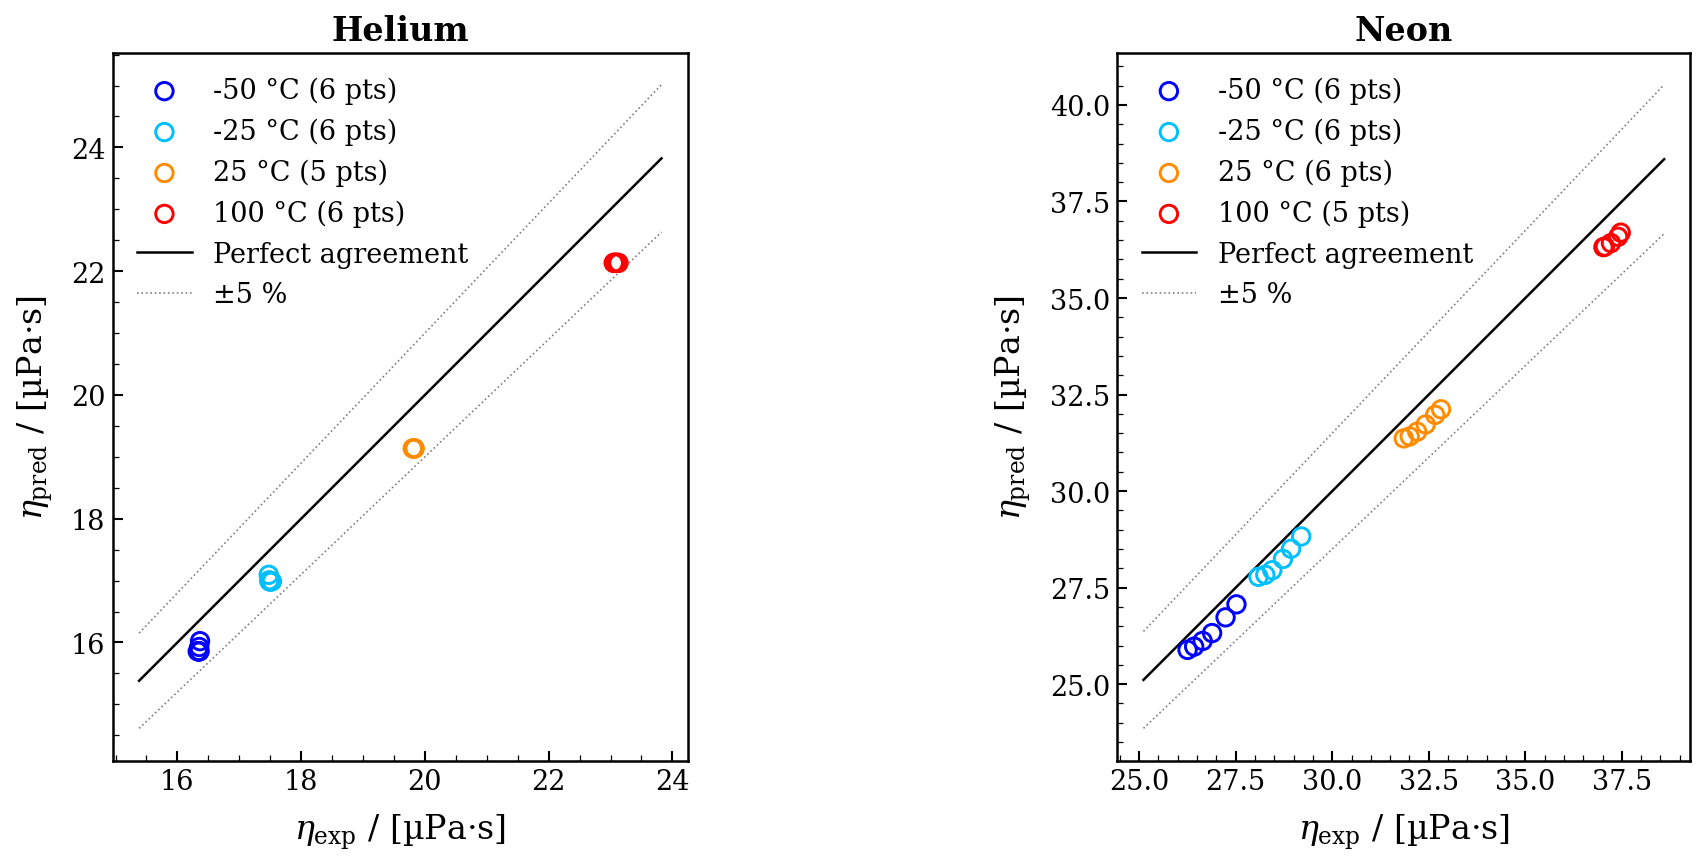


Creating Figure 2: Pure component viscosity vs pressure...
  ✓ Saved: fig2_pure_viscosity_vs_P_neg50C.png


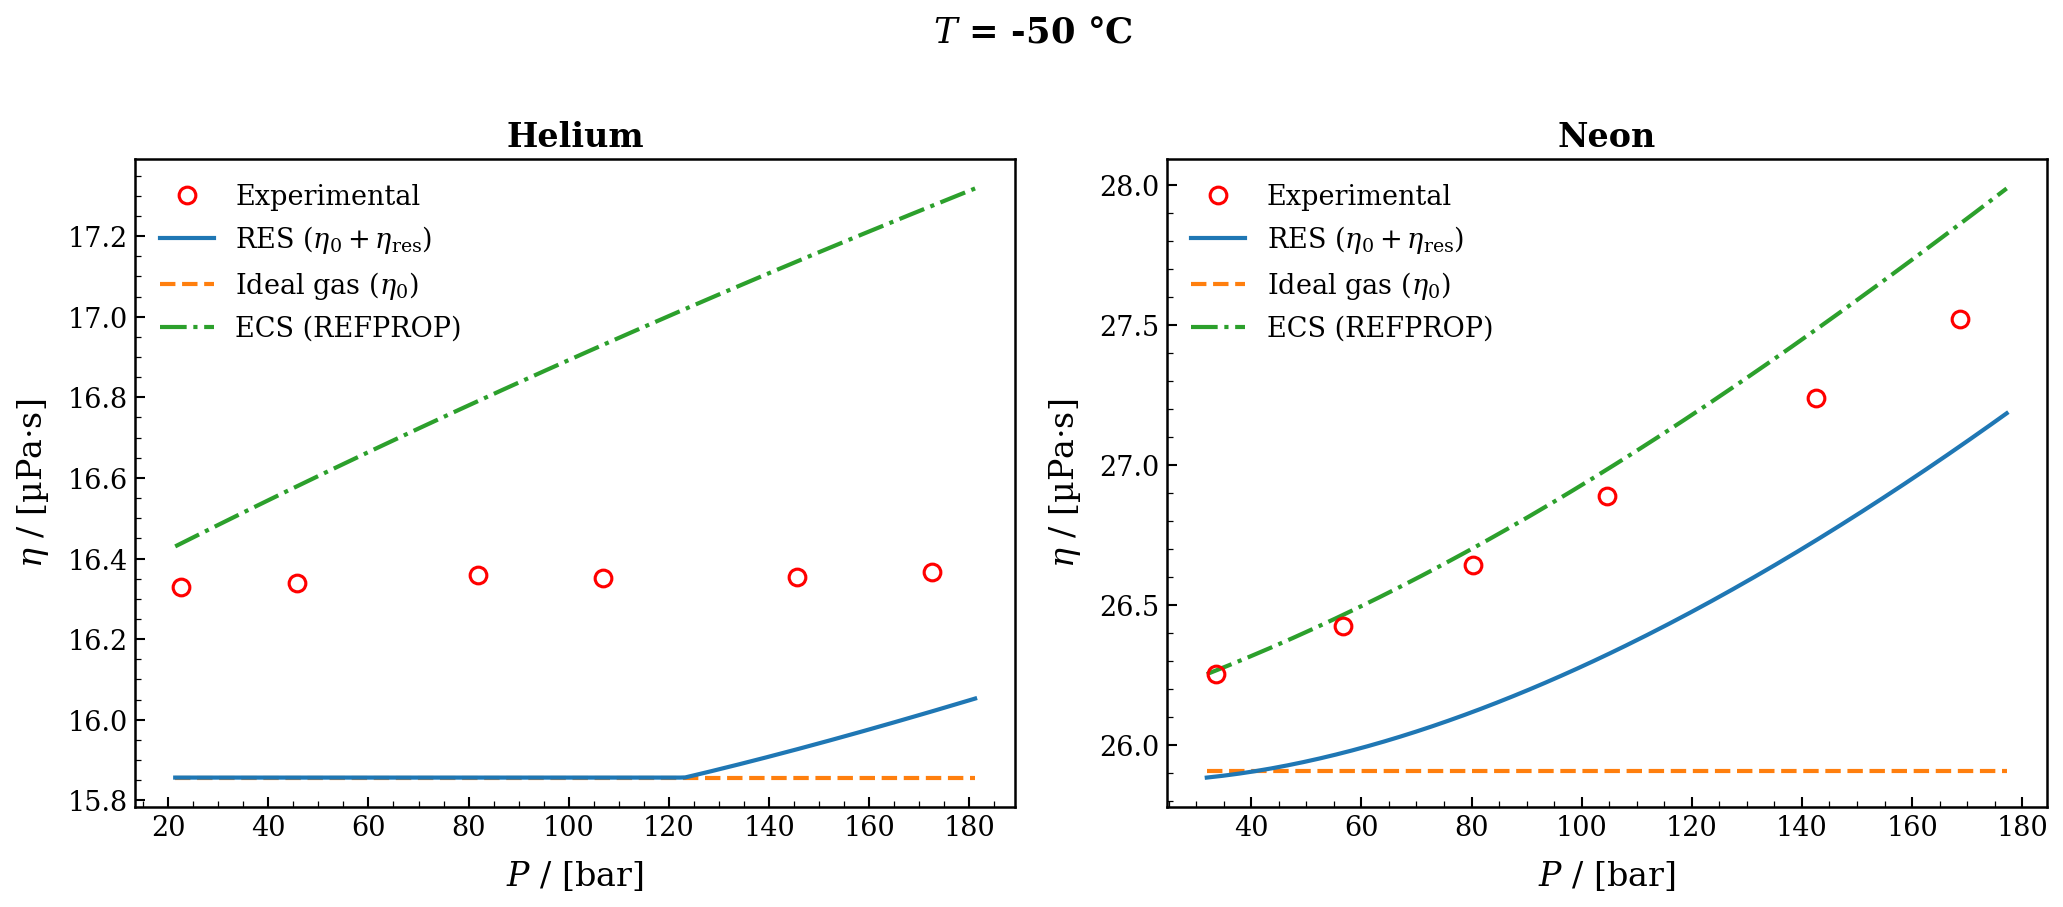

  ✓ Saved: fig2_pure_viscosity_vs_P_neg25C.png


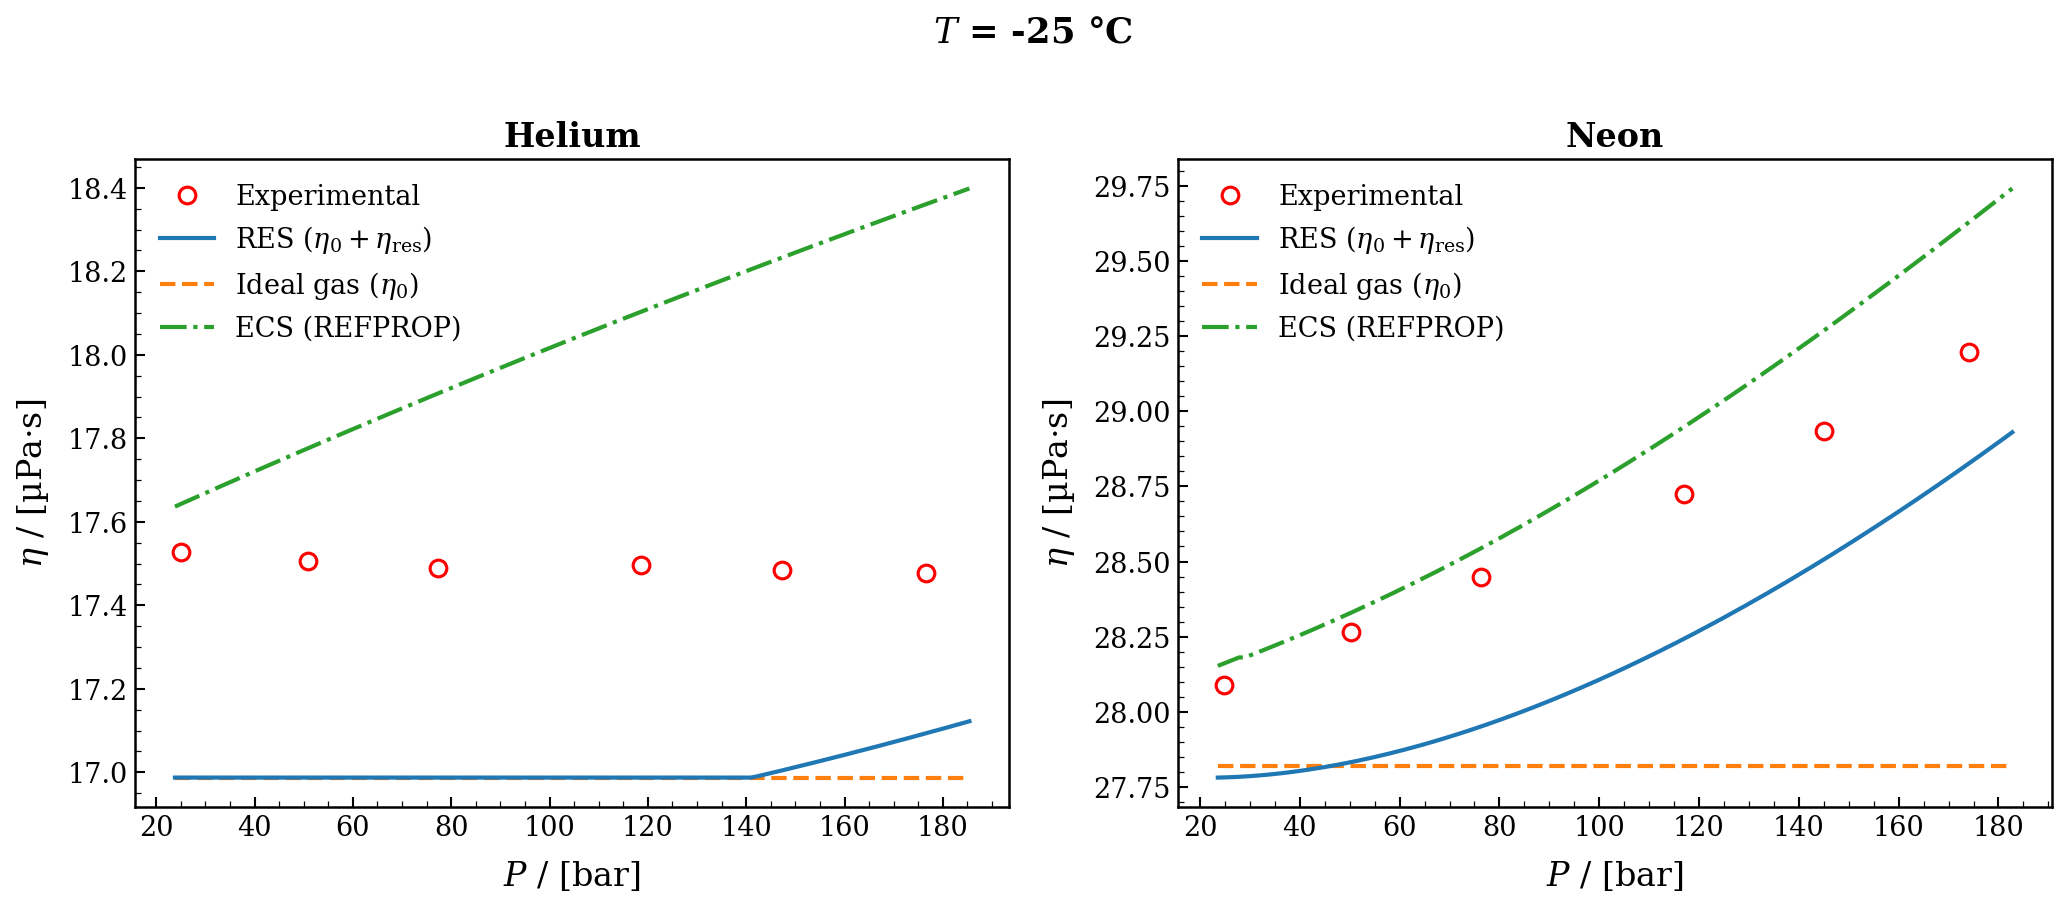

  ✓ Saved: fig2_pure_viscosity_vs_P_25C.png


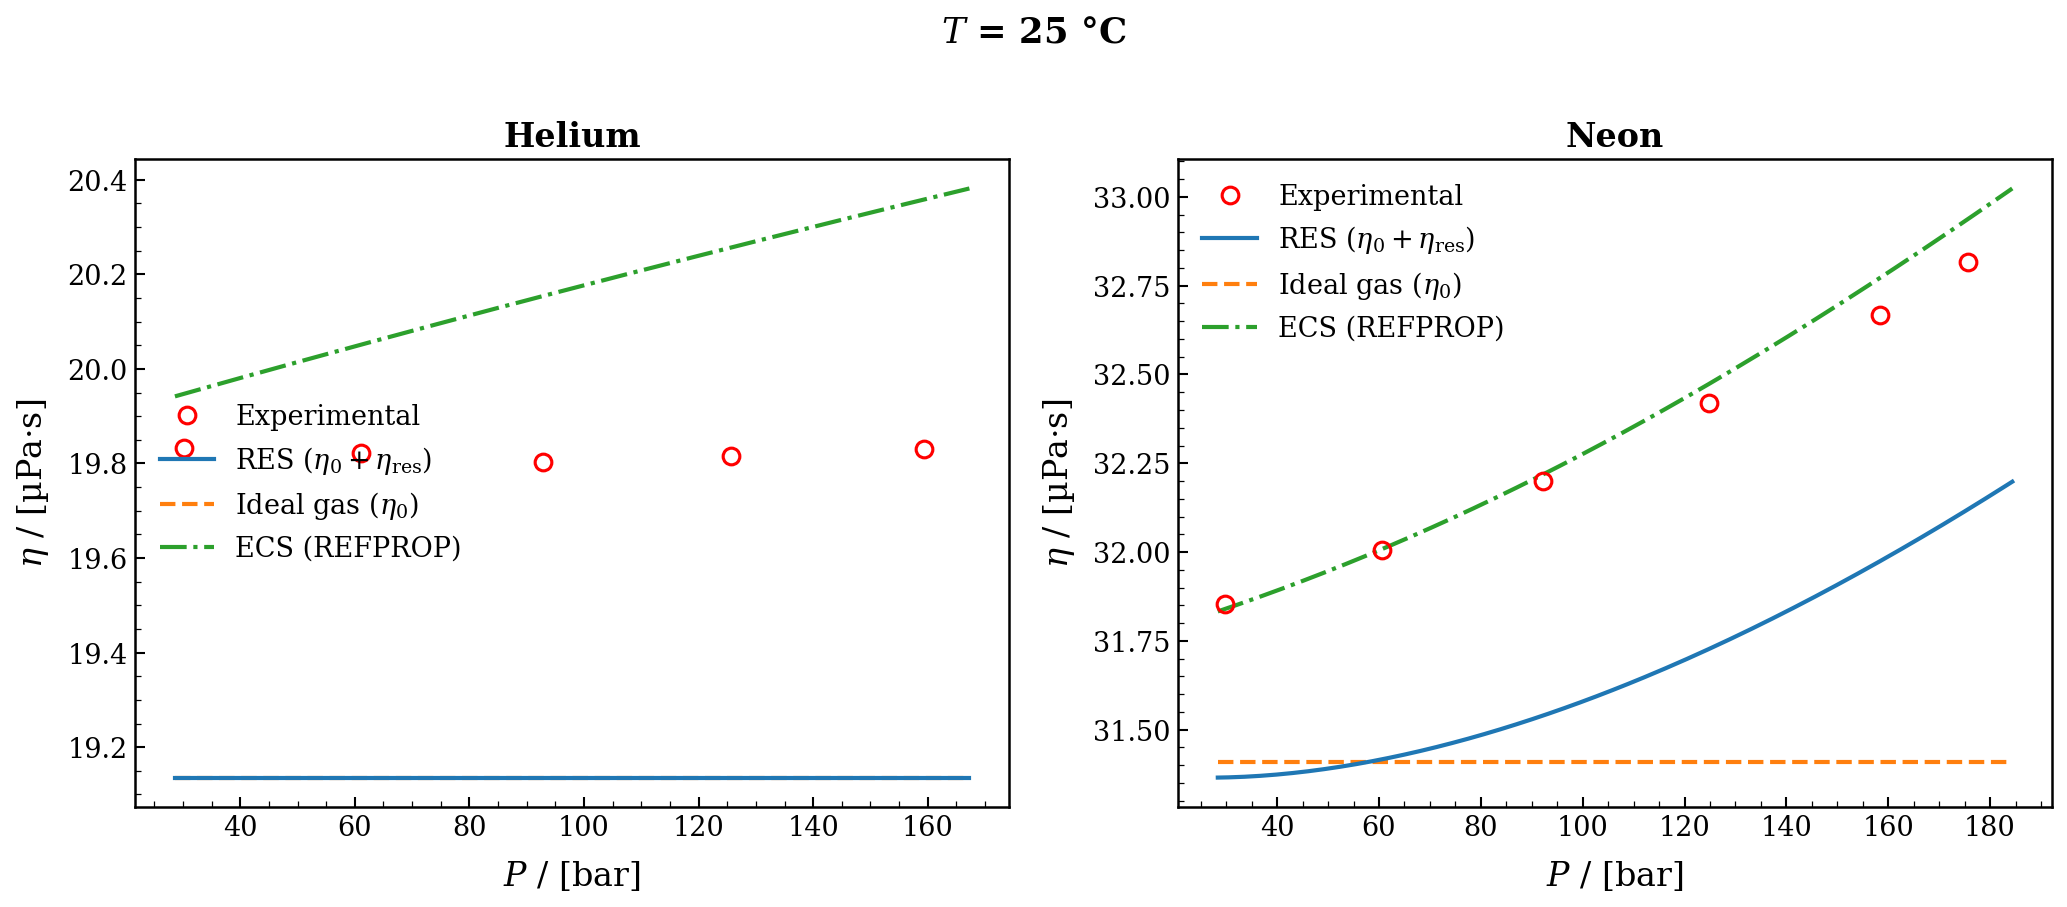

  ✓ Saved: fig2_pure_viscosity_vs_P_100C.png


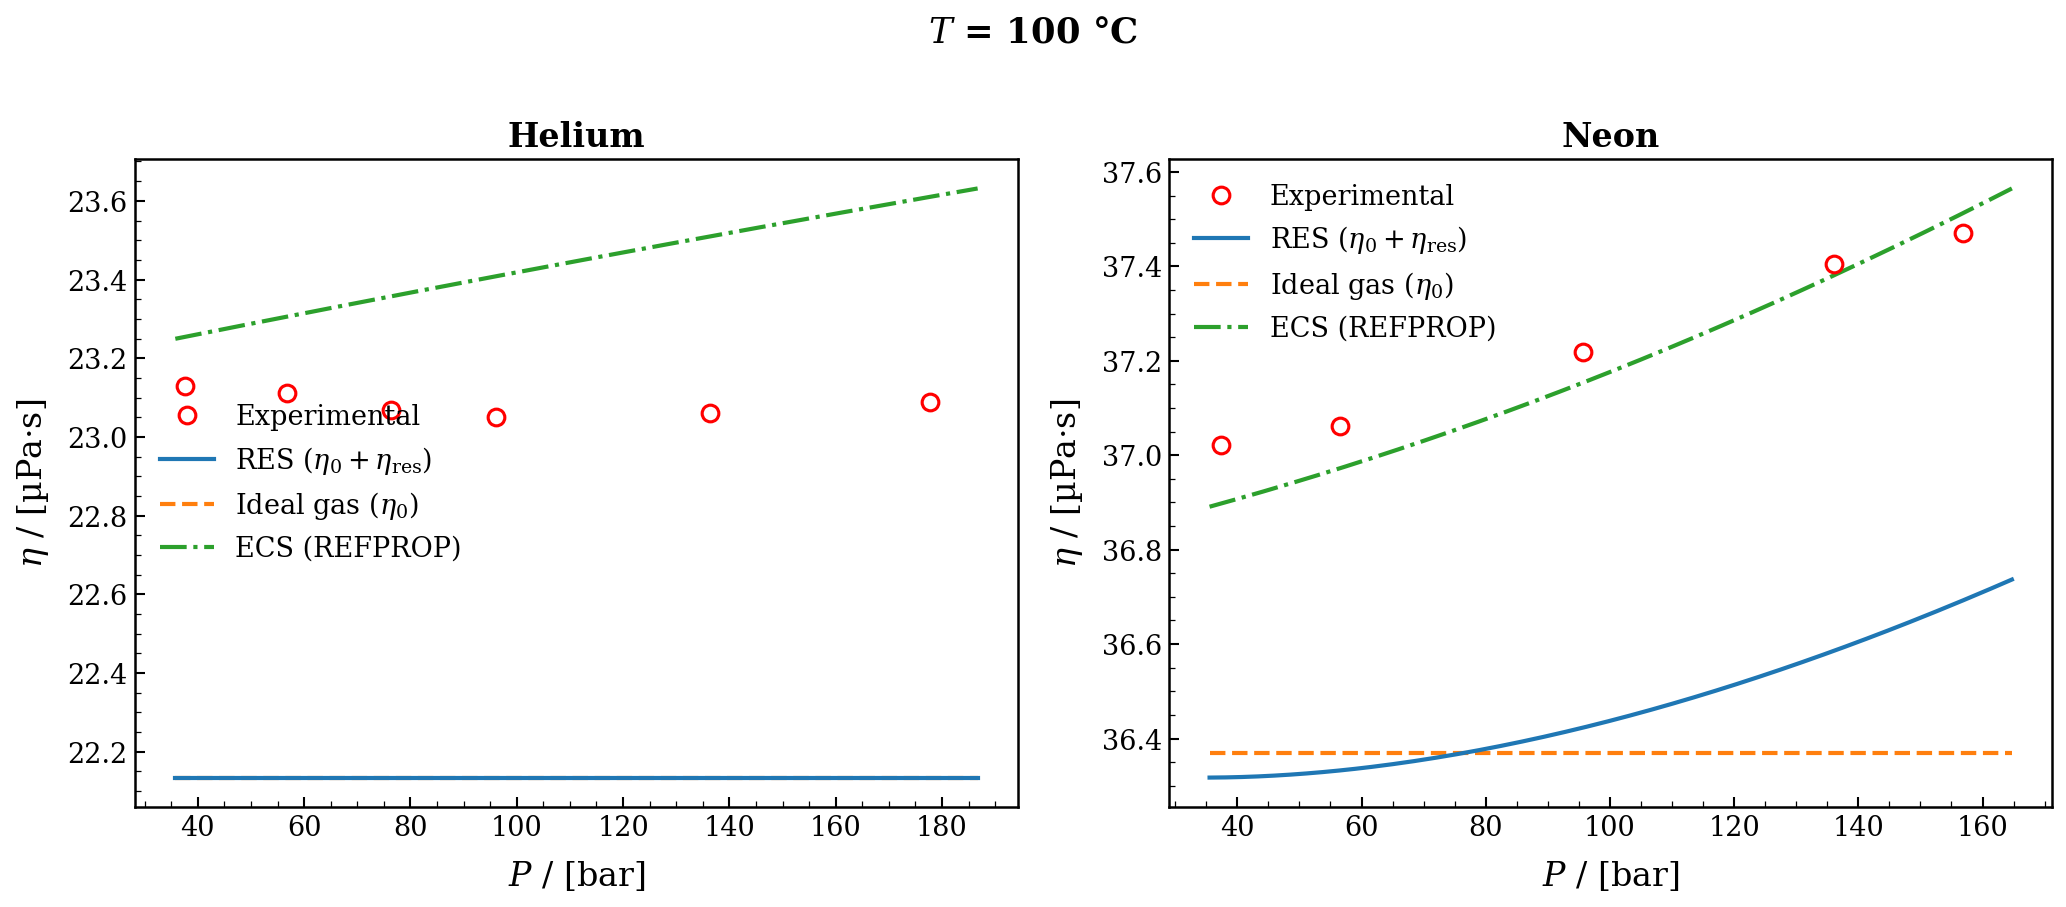


Creating Figure 3: Mixture viscosity vs pressure...
  ✓ Saved: fig3_mixture_viscosity_vs_P_20C.png


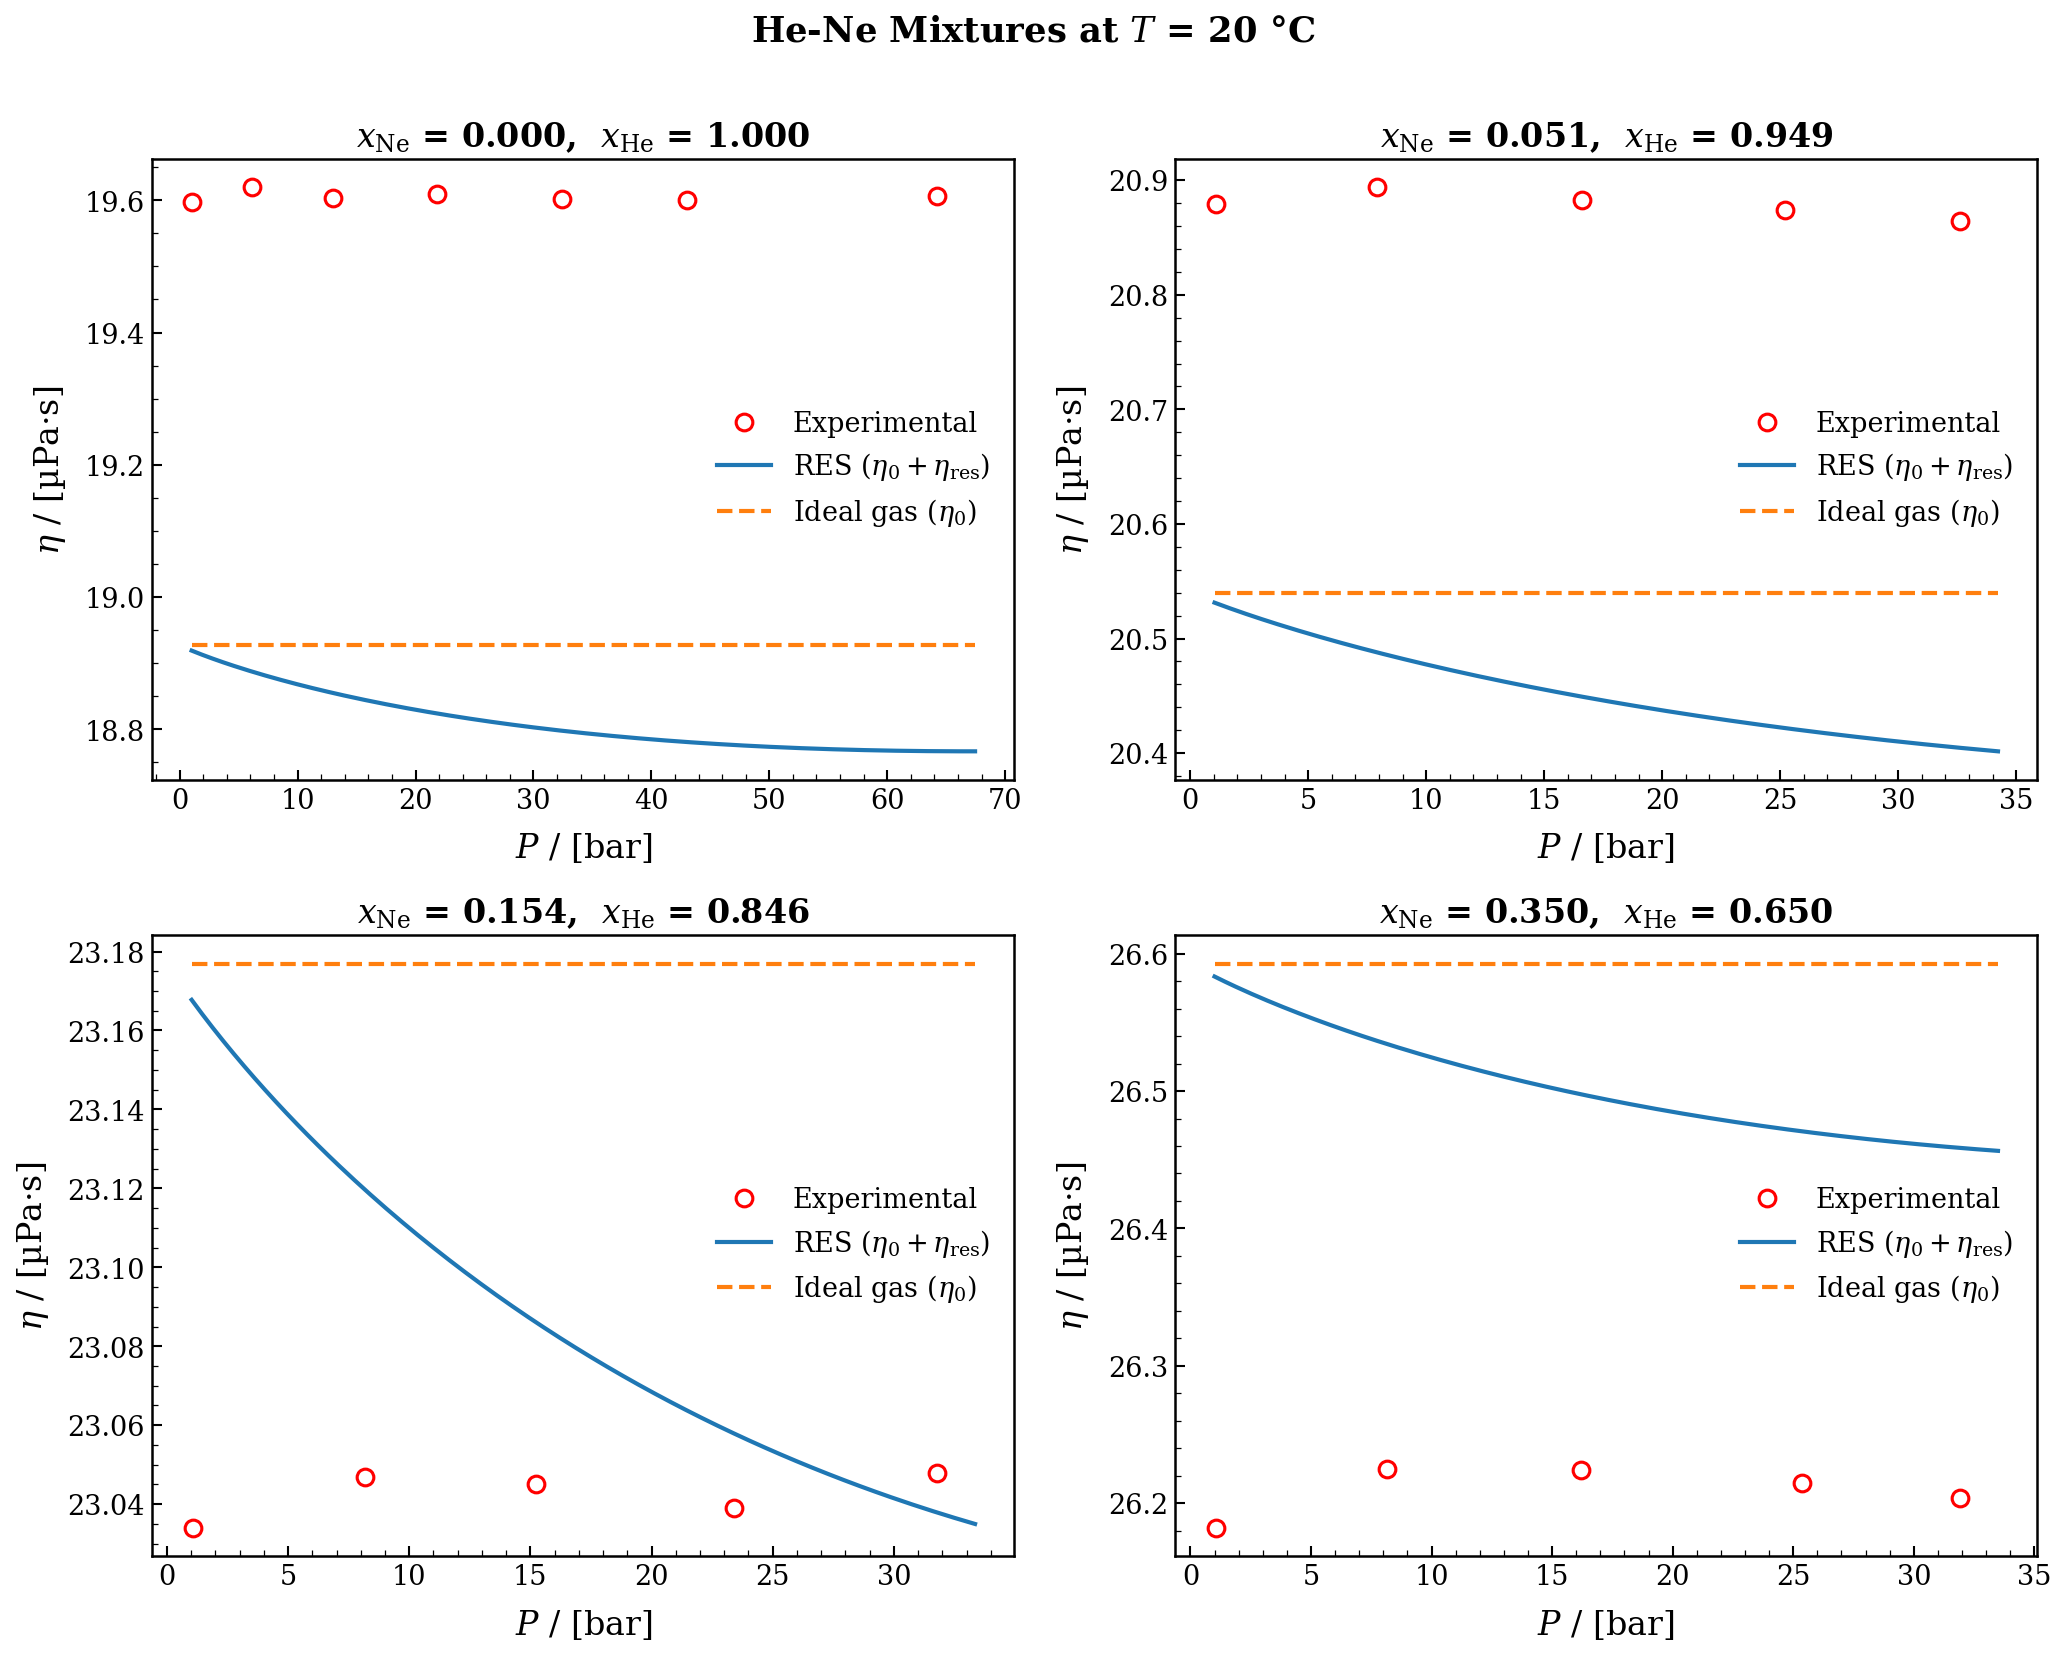

  ✓ Saved: fig3_mixture_viscosity_vs_P_30C.png


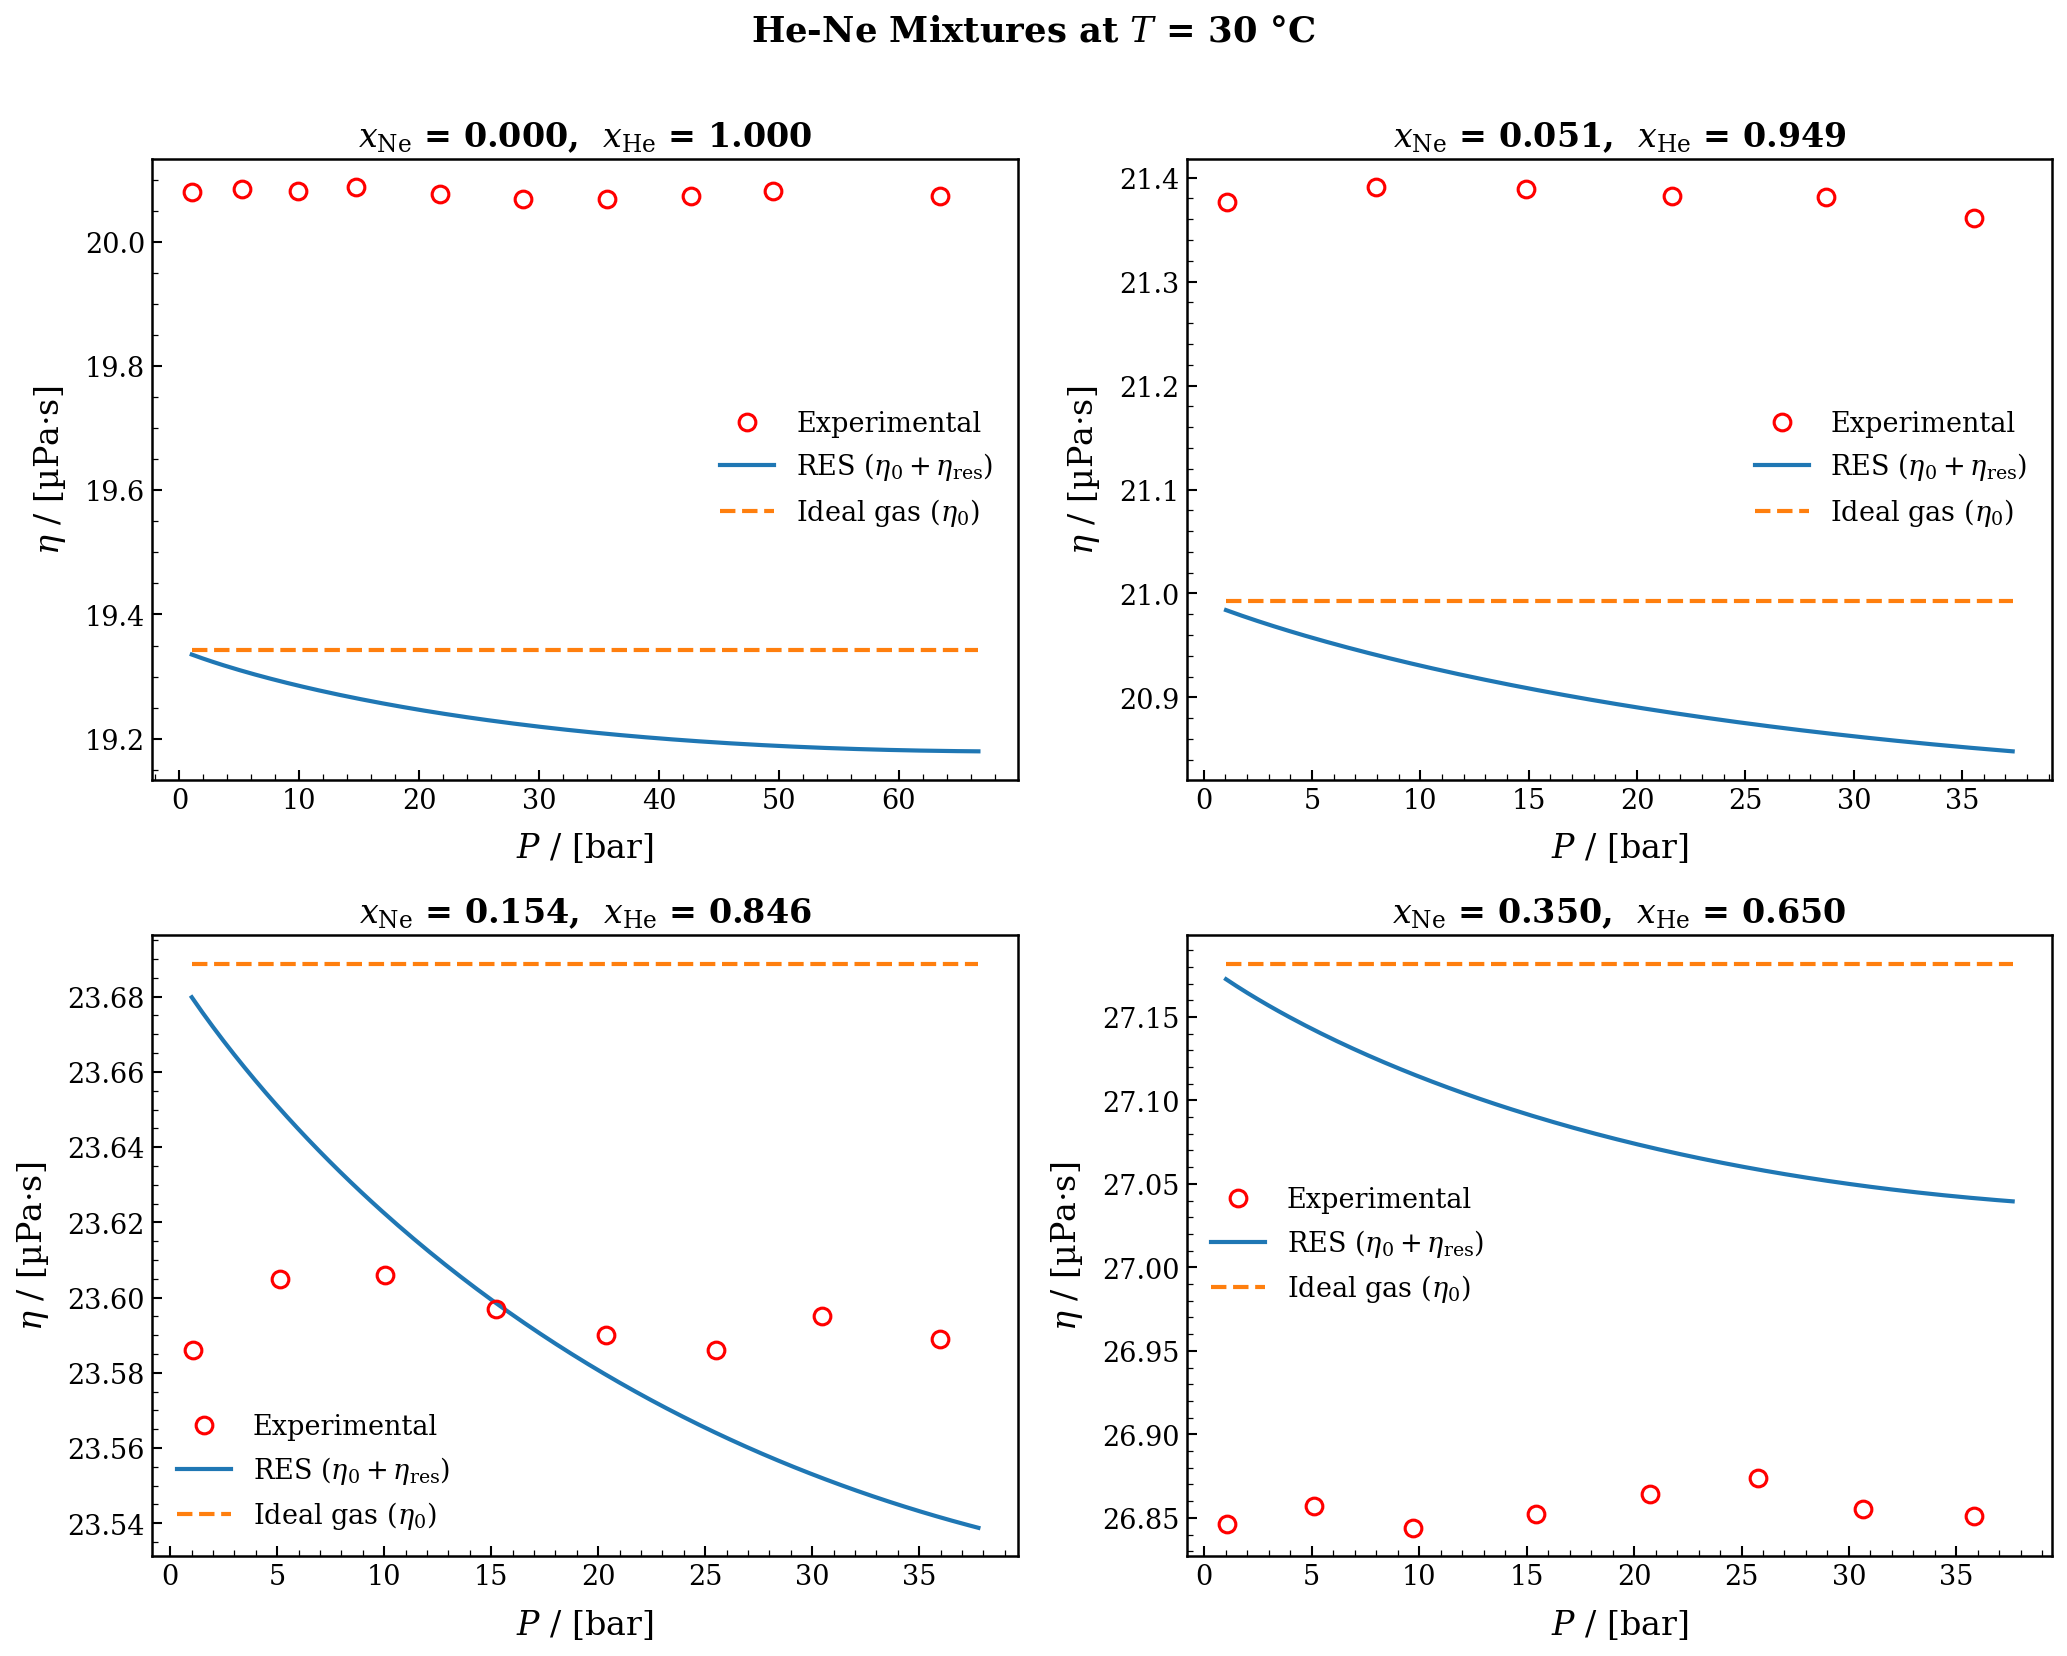


Creating Figure 4: Pure component thermal conductivity...
  ✓ Saved: fig4_pure_thermal_conductivity.png


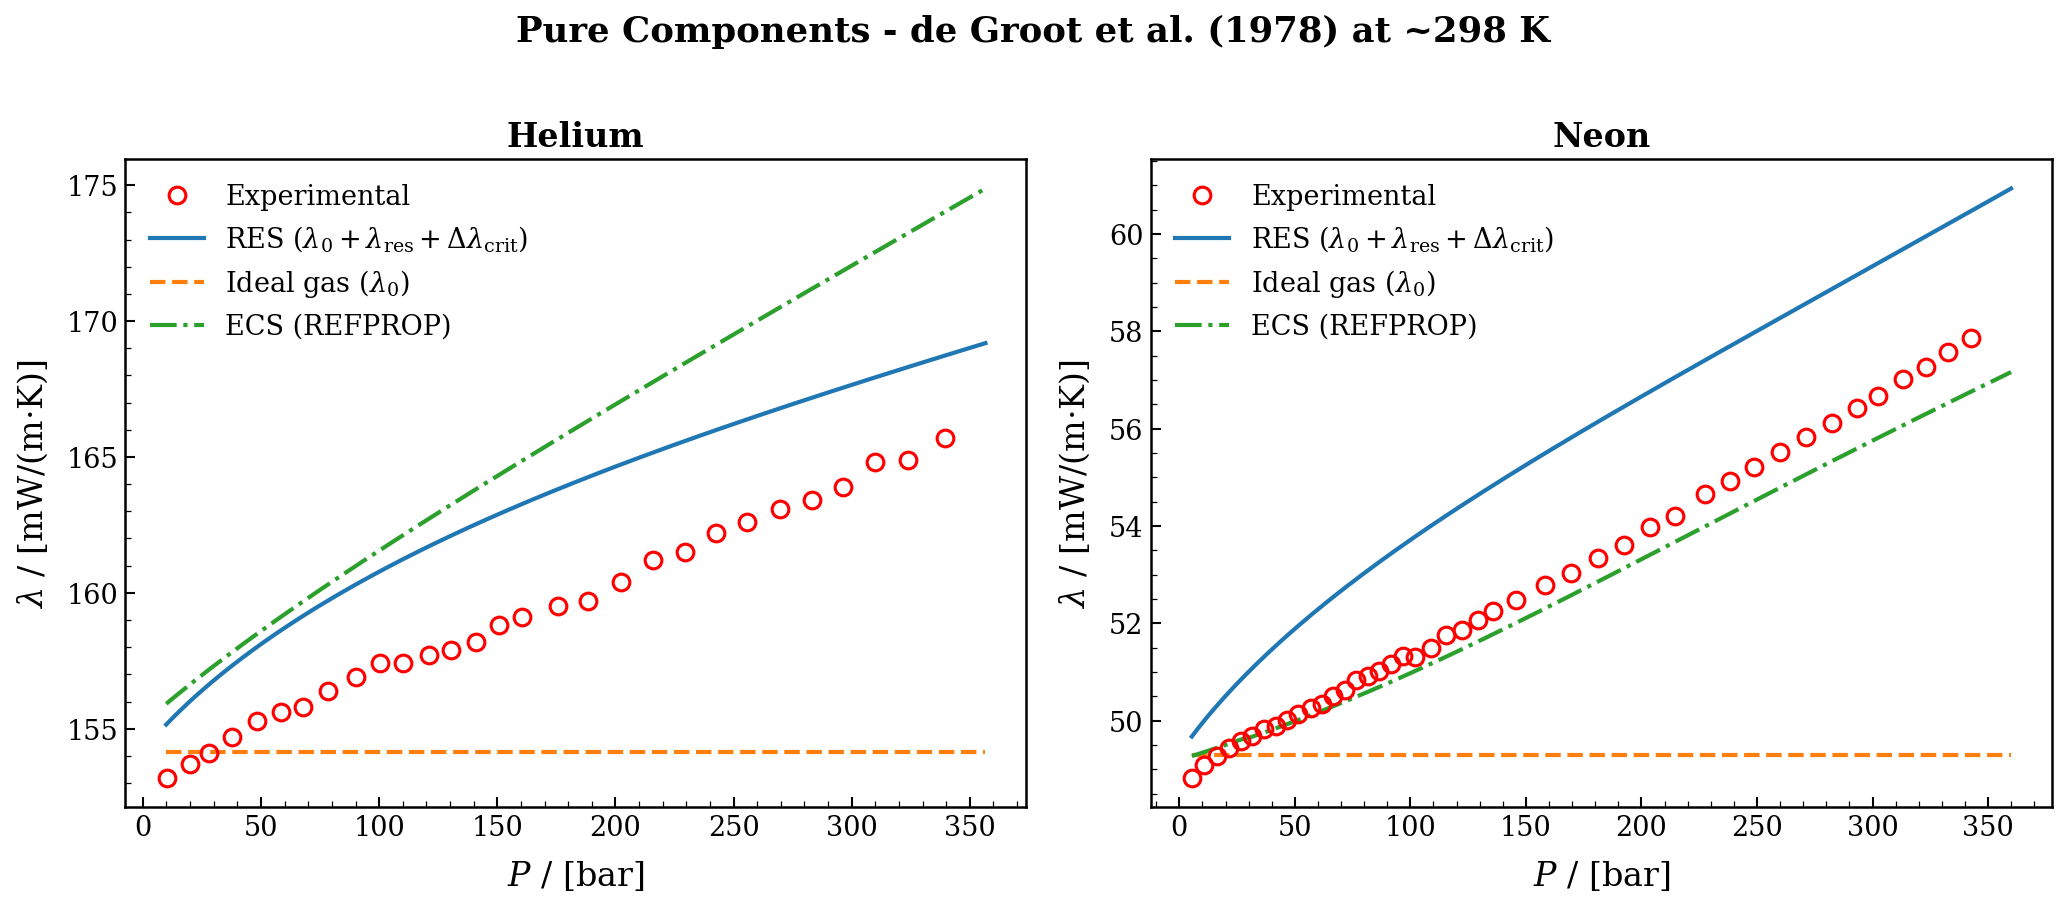


Creating Figure 5: Mixture thermal conductivity...
  ✓ Saved: fig5_mixture_thermal_conductivity.png


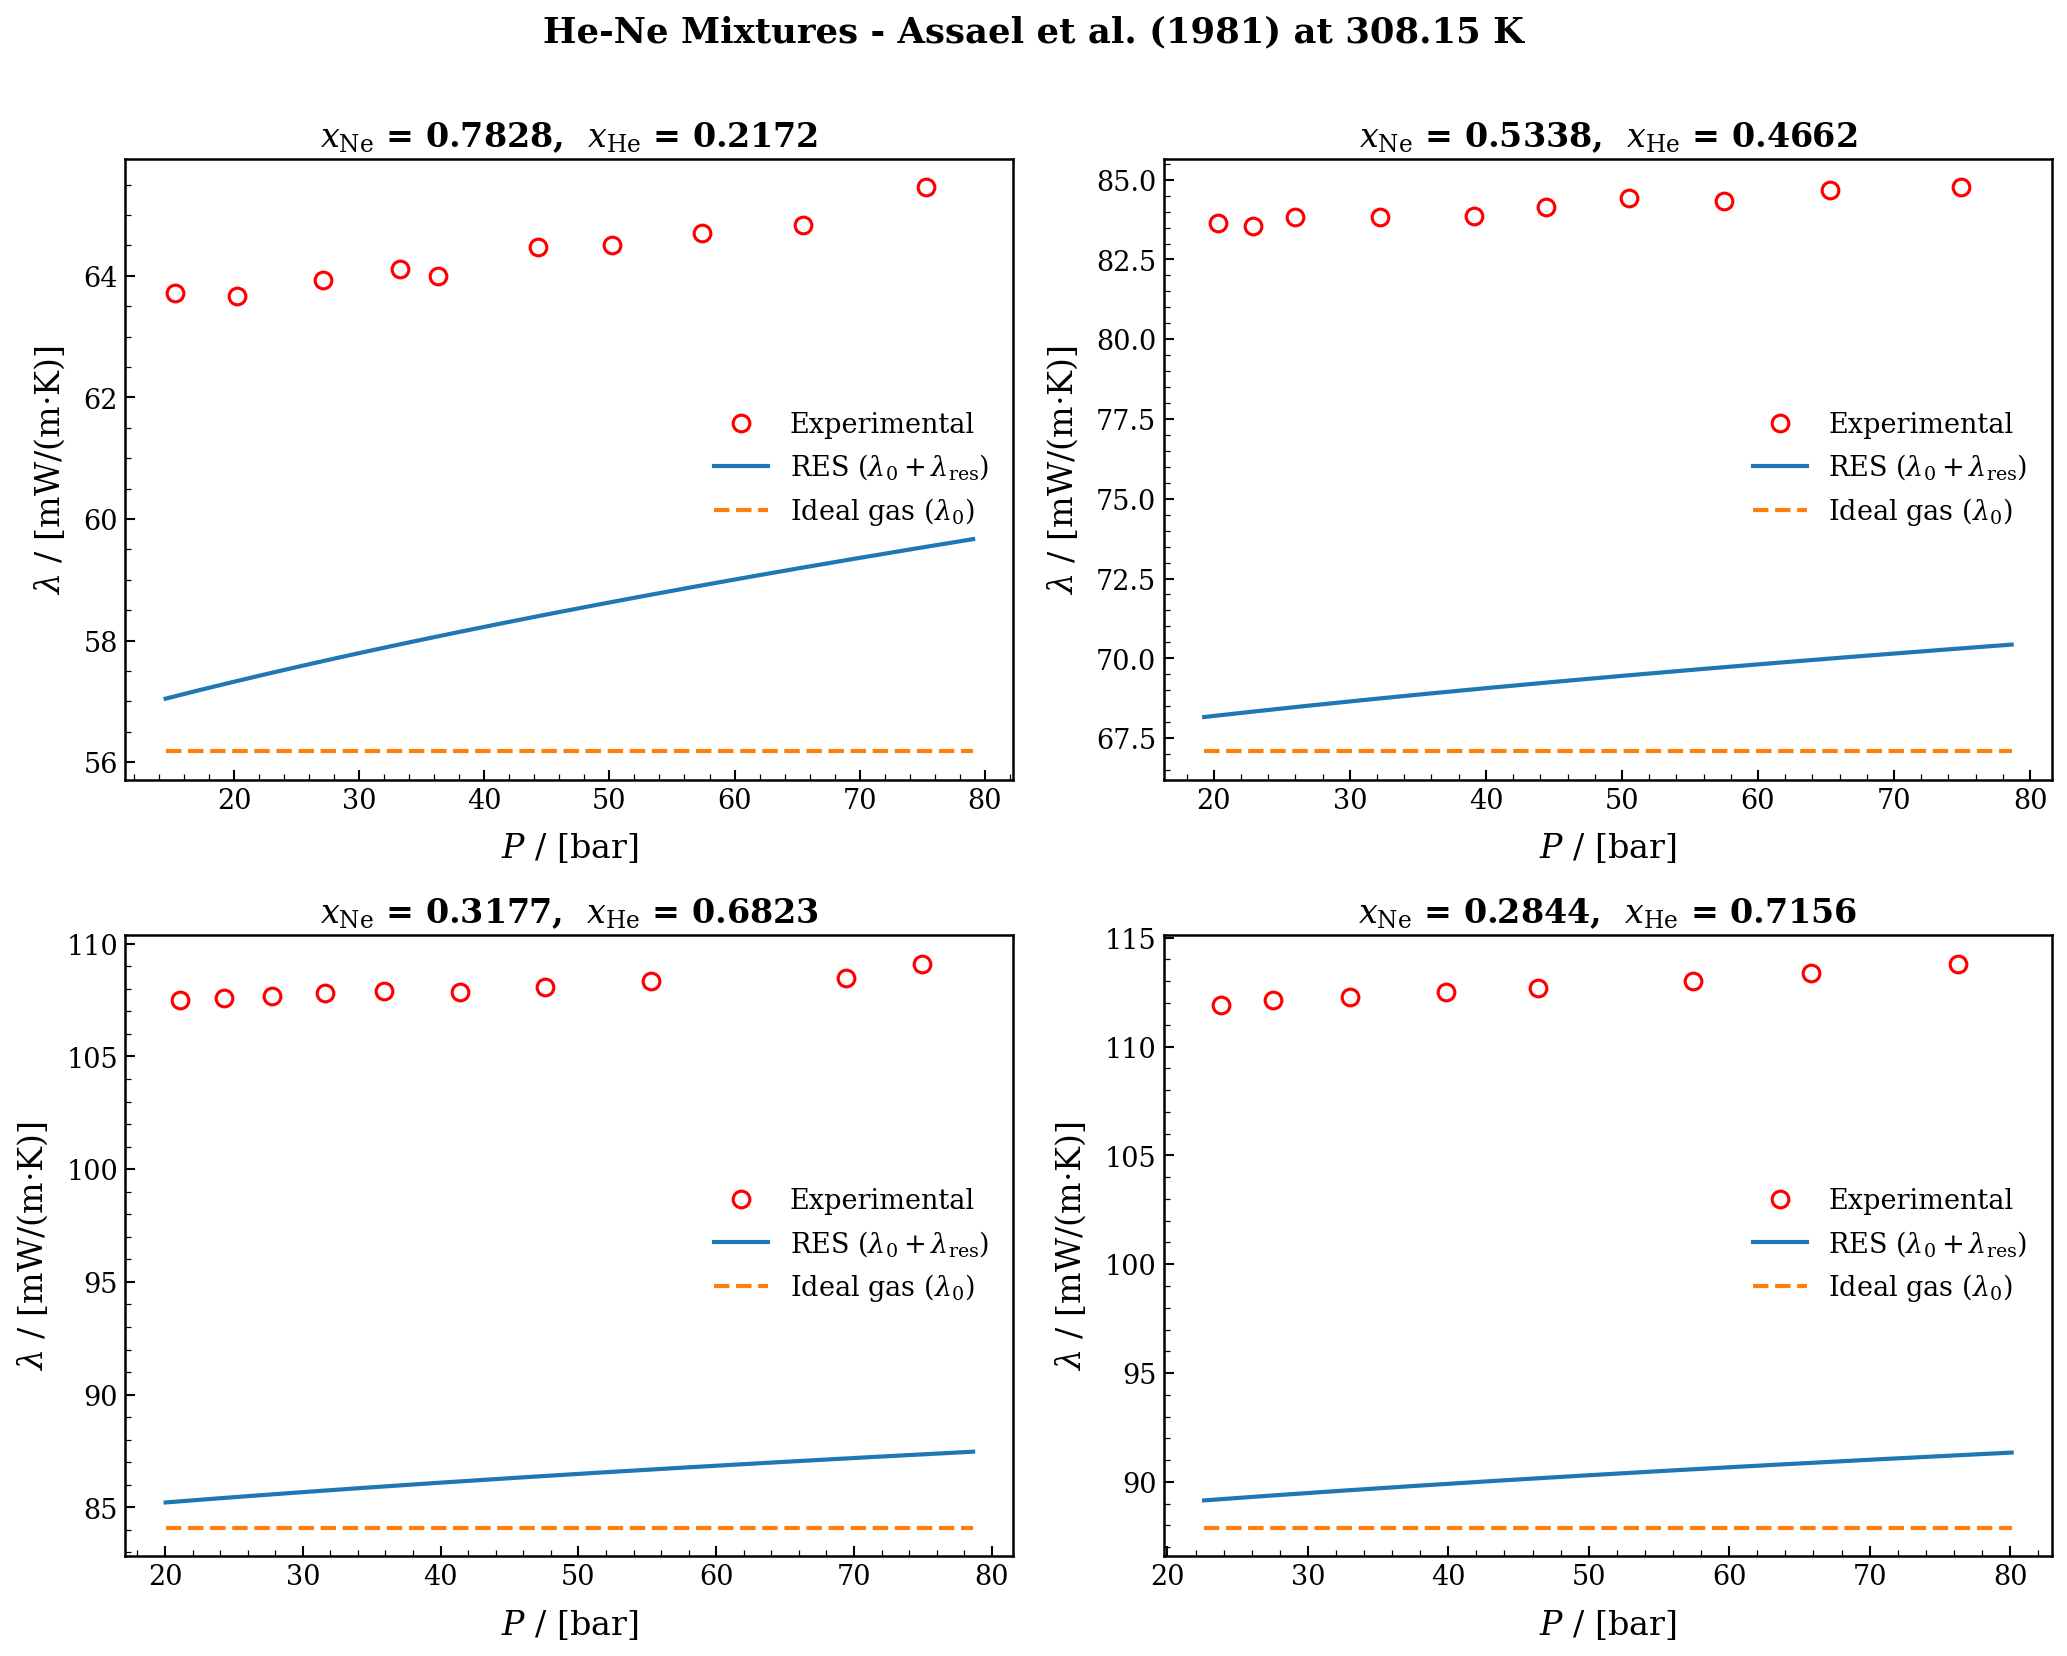


Creating Figure 6: Viscosity entropy scaling master plot (pure)...
  ✓ Saved: fig6_viscosity_entropy_scaling_pure.png


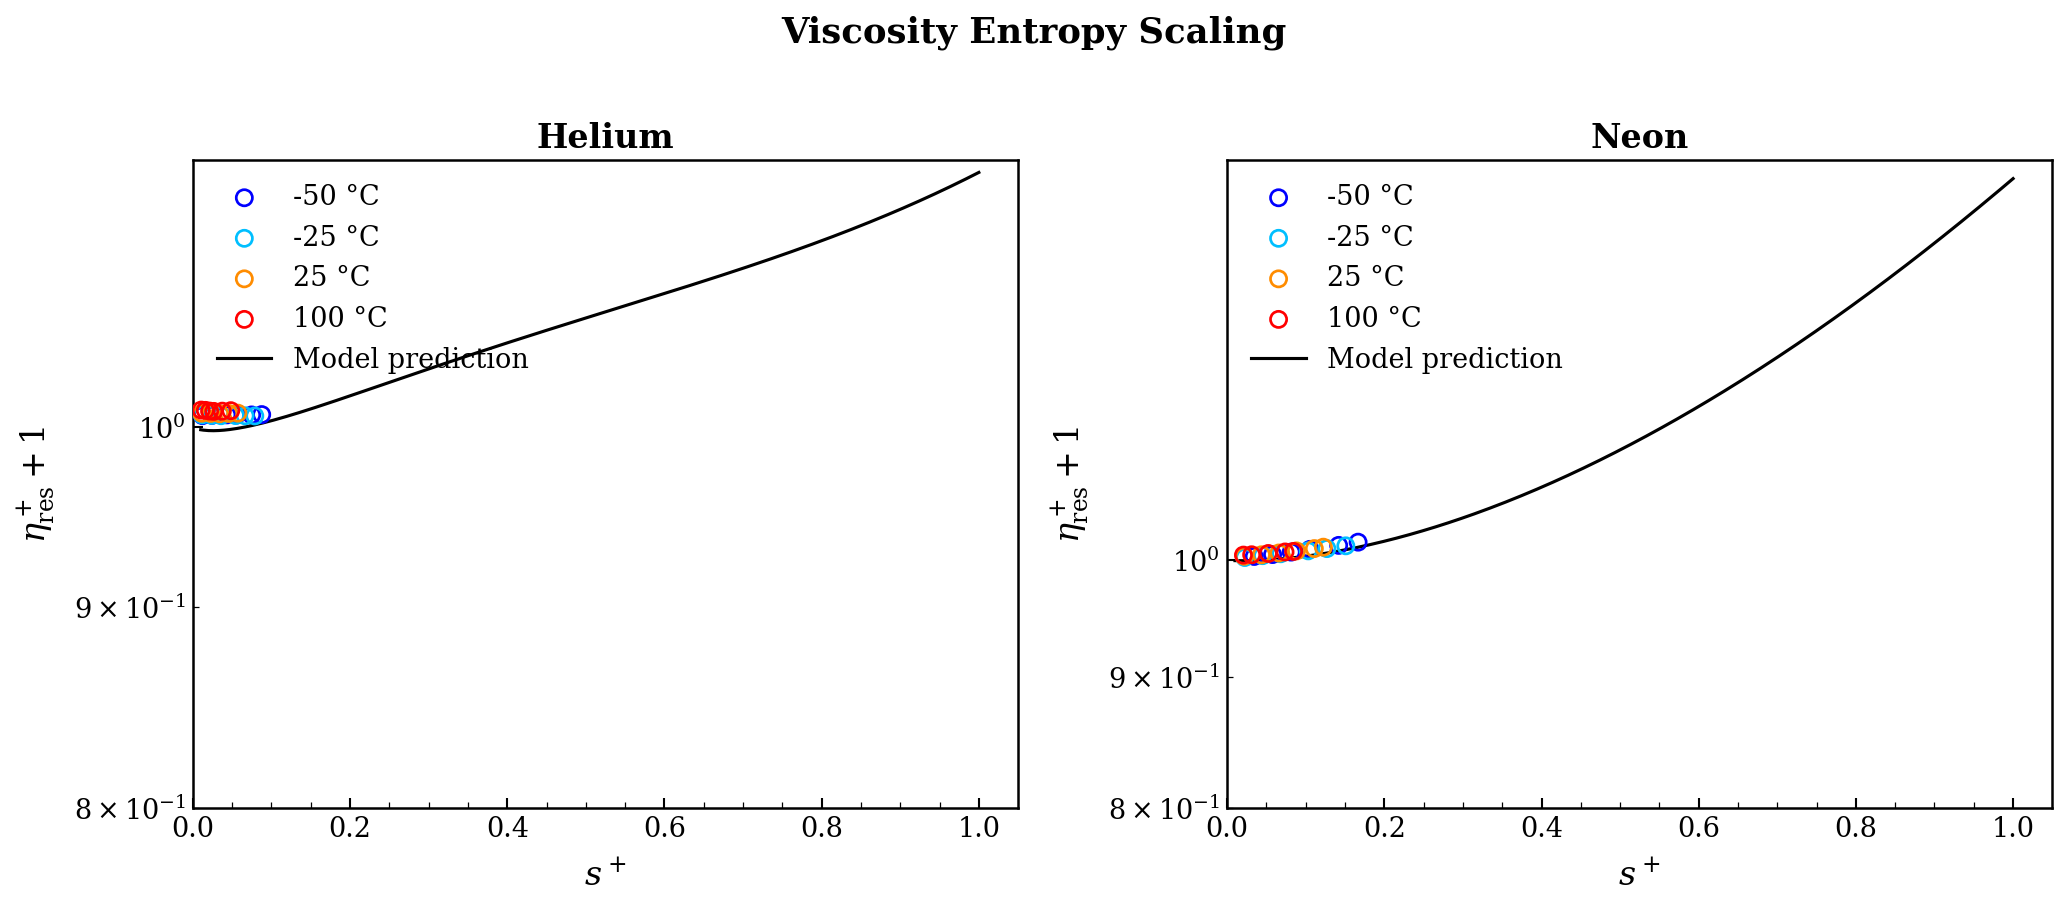


Creating Figure 7: Thermal conductivity entropy scaling master plot (pure)...
  ✓ Saved: fig7_thermal_entropy_scaling_pure.png


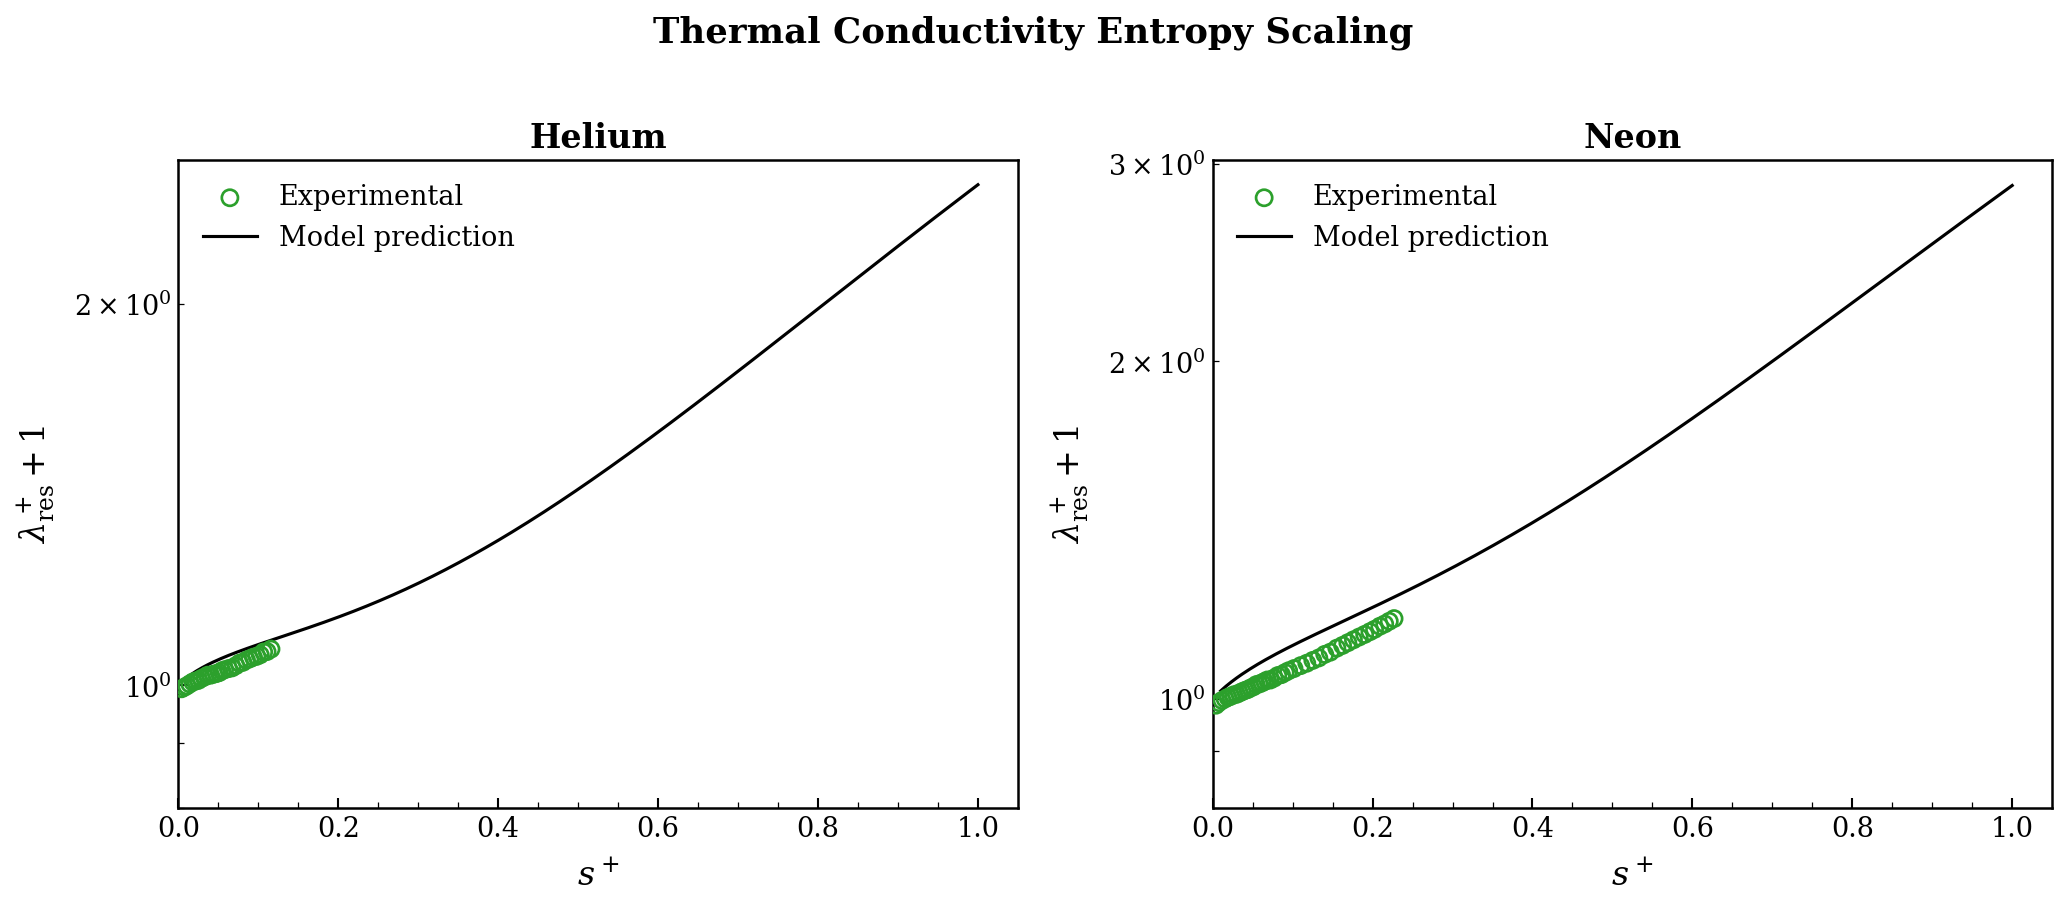


Creating Figure 8: Viscosity entropy scaling master plot (mixtures)...


C:\Users\btraj\AppData\Local\Temp\ipykernel_12804\3564799431.py:918: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(unique_xne))


  ✓ Saved: fig8_viscosity_entropy_scaling_mixture.png


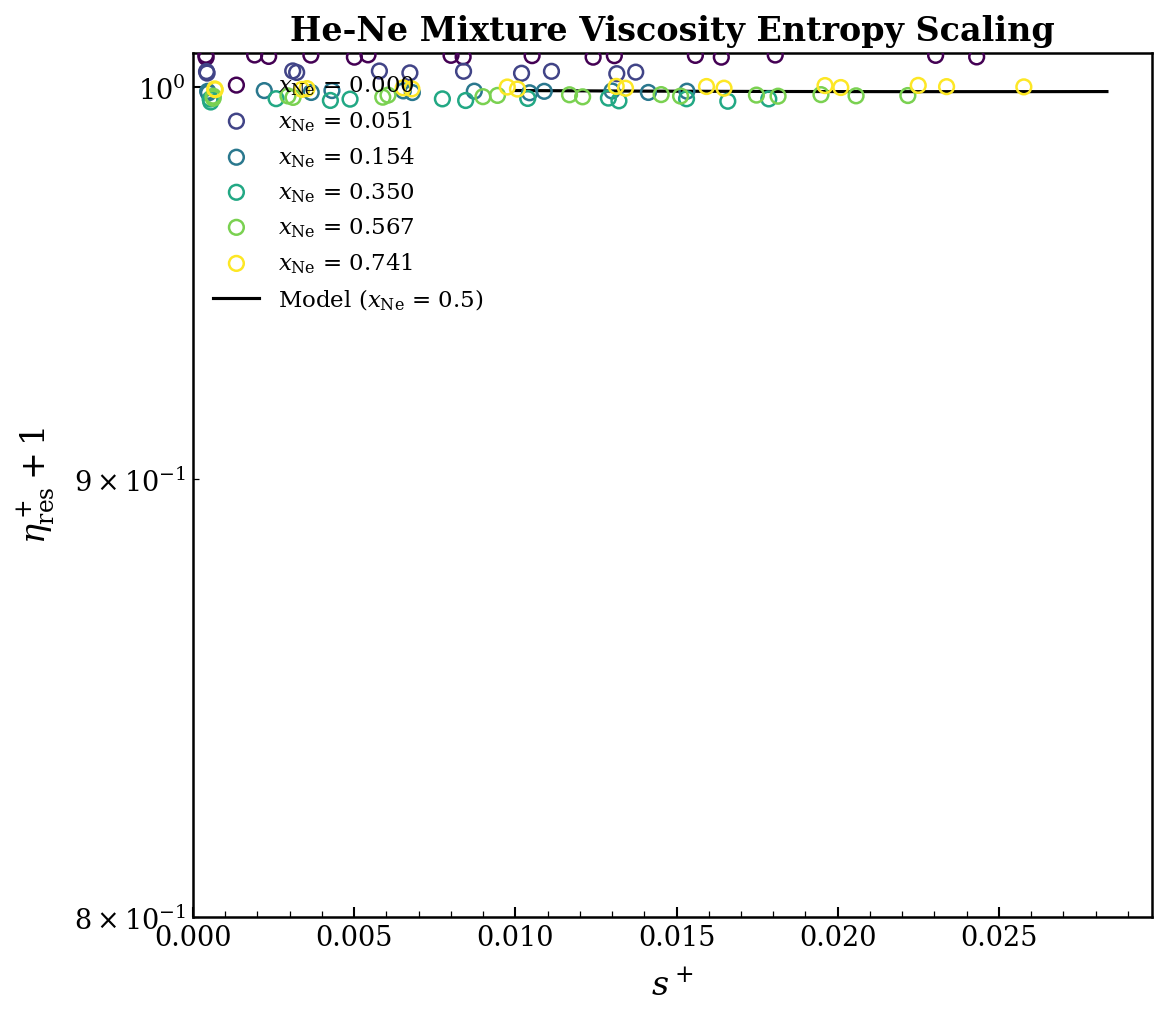


Creating Figure 9: Thermal conductivity entropy scaling master plot (mixtures)...


C:\Users\btraj\AppData\Local\Temp\ipykernel_12804\3564799431.py:1035: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_tc = cm.get_cmap('plasma', len(unique_xhe_tc))


  ✓ Saved: fig9_thermal_entropy_scaling_mixture.png


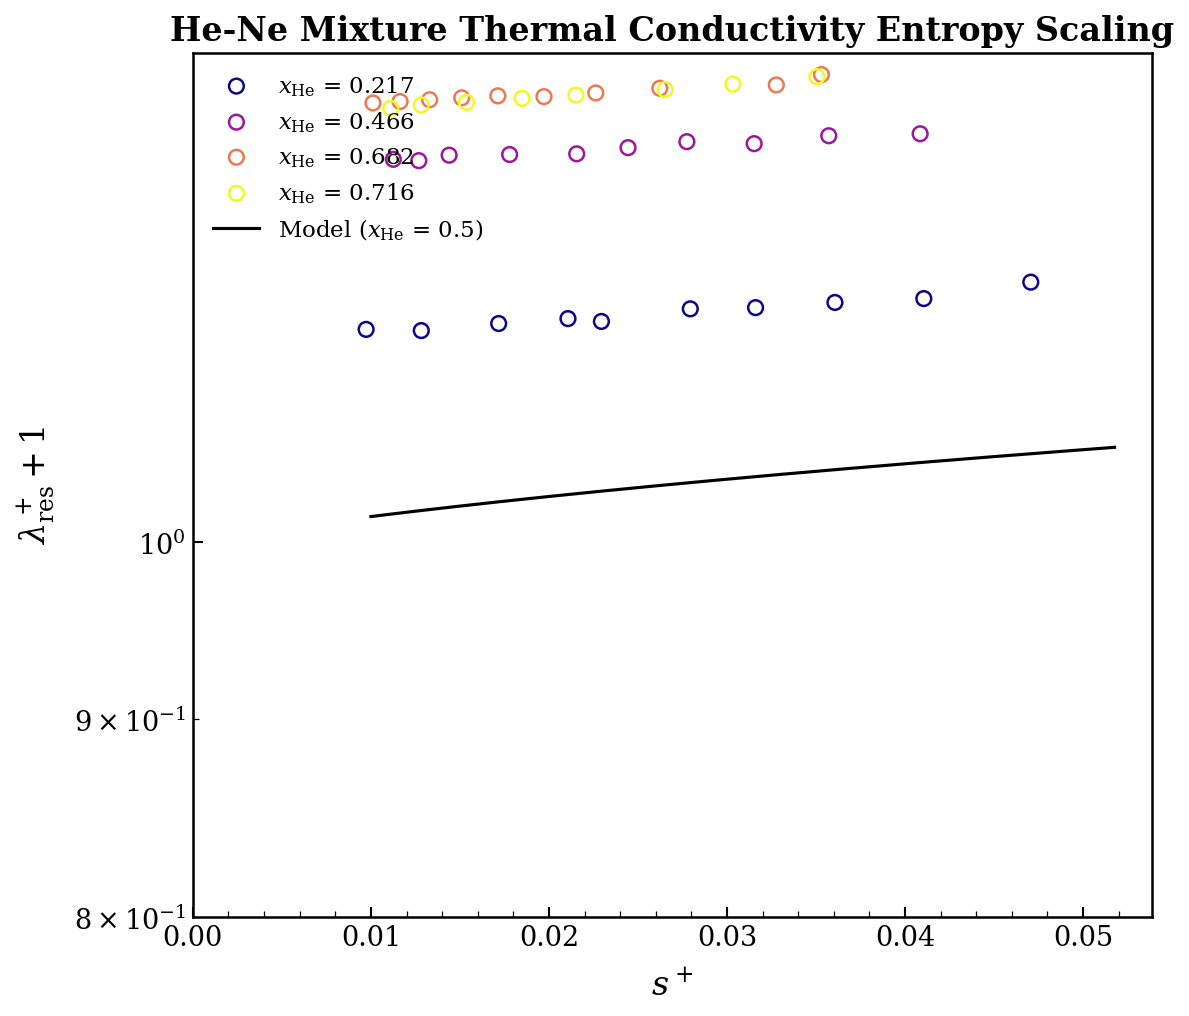


ALL VISUALIZATIONS COMPLETED

Generated files:
  - fig1_pure_viscosity_parity.png
  - fig2_pure_viscosity_vs_P_neg50C.png
  - fig2_pure_viscosity_vs_P_neg25C.png
  - fig2_pure_viscosity_vs_P_25C.png
  - fig2_pure_viscosity_vs_P_100C.png
  - fig3_mixture_viscosity_vs_P_20C.png
  - fig3_mixture_viscosity_vs_P_30C.png
  - fig4_pure_thermal_conductivity.png
  - fig5_mixture_thermal_conductivity.png

✓ Notebook execution complete!


In [17]:
import matplotlib as mpl

# =============================================================================
# JOURNAL-STYLE GLOBAL SETTINGS
# =============================================================================
mpl.rcParams.update({
    # Font settings
    'font.family': 'serif',
    'font.size': 14,
    'mathtext.fontset': 'dejavuserif',

    # Axes
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'axes.linewidth': 1.2,
    'axes.labelpad': 8,

    # Ticks
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',

    # Legend
    'legend.frameon': False,
    'legend.fontsize': 13,
    'legend.handlelength': 2.0,

    # Figure
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# =============================================================================
# STYLE CONSTANTS
# =============================================================================
# Experimental data: red open circles
EXP_STYLE = dict(
    marker='o', linestyle='none', color='red', markersize=8,
    markeredgecolor='red', markerfacecolor='none', markeredgewidth=1.5,
    zorder=5,
)

# RES Model prediction: solid blue line
RES_STYLE = dict(
    linestyle='-', color='#1f77b4', linewidth=2.0, zorder=4,
)

# Ideal Gas: dashed orange line
IDEAL_STYLE = dict(
    linestyle='--', color='#ff7f0e', linewidth=2.0, zorder=3,
)

# ECS (REFPROP): dash-dot green line
ECS_STYLE = dict(
    linestyle='-.', color='#2ca02c', linewidth=2.0, zorder=3.5,
)

# Number of points for smooth model curves
N_SMOOTH = 150


# =============================================================================
# HELPER: Evaluate pure viscosity model on a smooth pressure grid
# =============================================================================
def evaluate_pure_viscosity_smooth(eos, T_K, P_min_Pa, P_max_Pa, M, sigma,
                                   epsilon_k, params, n_points=N_SMOOTH):
    """
    Evaluate RES viscosity model on a smooth pressure grid.

    Returns
    -------
    P_atm : ndarray
        Pressure array [atm]
    eta_total : ndarray
        Total viscosity [microPa*s]
    eta_0 : ndarray
        Dilute gas viscosity [microPa*s]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    eta_total_arr = np.full(n_points, np.nan)
    eta_0_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
            )
            eta_tot, eta_0, _, _ = calculate_viscosity(
                state, M, sigma, epsilon_k, params
            )
            eta_total_arr[i] = eta_tot * 1e6
            eta_0_arr[i] = eta_0 * 1e6
        except Exception:
            continue

    P_atm = P_grid_Pa / 101325.0
    return P_atm, eta_total_arr, eta_0_arr


# =============================================================================
# HELPER: Evaluate pure thermal conductivity model on a smooth pressure grid
# =============================================================================
def evaluate_pure_thermal_smooth(eos, T_K, P_min_Pa, P_max_Pa, M, sigma,
                                 epsilon_k, params, n_points=N_SMOOTH,
                                 RP_inst=None, MOLAR_BASE_SI_val=None,
                                 material=None):
    """
    Evaluate RES thermal conductivity model on a smooth pressure grid.

    Returns
    -------
    P_MPa : ndarray
        Pressure array [MPa]
    lam_total : ndarray
        Total thermal conductivity [mW/(m*K)]
    lam_0 : ndarray
        Dilute gas thermal conductivity [mW/(m*K)]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    lam_total_arr = np.full(n_points, np.nan)
    lam_0_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
            )
            lam_tot, lam_0, _, _ = calculate_thermal_conductivity(
                state, M, sigma, epsilon_k, params,
                RP=RP_inst, MOLAR_BASE_SI=MOLAR_BASE_SI_val,
                material=material,
            )
            lam_total_arr[i] = lam_tot * 1000
            lam_0_arr[i] = lam_0 * 1000
        except Exception:
            continue

    P_MPa = P_grid_Pa / 1e6
    return P_MPa, lam_total_arr, lam_0_arr


# =============================================================================
# HELPER: Evaluate REFPROP ECS on a smooth pressure grid (viscosity)
# =============================================================================
def evaluate_ecs_viscosity_smooth(material, T_K, P_min_Pa, P_max_Pa,
                                  RP_inst, MOLAR_BASE_SI_val,
                                  n_points=N_SMOOTH):
    """
    Returns
    -------
    P_atm : ndarray
    eta_ecs : ndarray  [microPa*s]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    eta_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        val = refprop_viscosity(material, T_K, P_Pa, RP_inst, MOLAR_BASE_SI_val)
        if not np.isnan(val):
            eta_arr[i] = val * 1e6

    P_atm = P_grid_Pa / 101325.0
    return P_atm, eta_arr


# =============================================================================
# HELPER: Evaluate REFPROP ECS on a smooth pressure grid (thermal cond.)
# =============================================================================
def evaluate_ecs_thermal_smooth(material, T_K, P_min_Pa, P_max_Pa,
                                RP_inst, MOLAR_BASE_SI_val,
                                n_points=N_SMOOTH):
    """
    Returns
    -------
    P_MPa : ndarray
    lam_ecs : ndarray  [mW/(m*K)]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    lam_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        val = refprop_thermal_conductivity(material, T_K, P_Pa,
                                           RP_inst, MOLAR_BASE_SI_val)
        if not np.isnan(val):
            lam_arr[i] = val * 1000

    P_MPa = P_grid_Pa / 1e6
    return P_MPa, lam_arr


# =============================================================================
# HELPER: Evaluate mixture viscosity model on a smooth pressure grid
# =============================================================================
def evaluate_mixture_viscosity_smooth(eos, T_K, P_min_Pa, P_max_Pa,
                                      x, components, n_points=N_SMOOTH):
    """
    Returns
    -------
    P_atm : ndarray
    eta_total : ndarray  [microPa*s]
    eta_0 : ndarray      [microPa*s]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    eta_total_arr = np.full(n_points, np.nan)
    eta_0_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
                molefracs=x,
            )
            eta_tot, eta_0, _ = mixture_viscosity_entropy_scaling(
                state, x, components
            )
            eta_total_arr[i] = eta_tot * 1e6
            eta_0_arr[i] = eta_0 * 1e6
        except Exception:
            continue

    P_atm = P_grid_Pa / 101325.0
    return P_atm, eta_total_arr, eta_0_arr


# =============================================================================
# HELPER: Evaluate mixture thermal conductivity model on a smooth grid
# =============================================================================
def evaluate_mixture_thermal_smooth(eos, T_K, P_min_Pa, P_max_Pa,
                                    x, M_arr, sigma_arr, epsilon_k_arr,
                                    params_arr, n_points=N_SMOOTH):
    """
    Returns
    -------
    P_MPa : ndarray
    lam_total : ndarray  [mW/(m*K)]
    lam_0 : ndarray      [mW/(m*K)]
    """
    P_grid_Pa = np.linspace(P_min_Pa, P_max_Pa, n_points)
    lam_total_arr = np.full(n_points, np.nan)
    lam_0_arr = np.full(n_points, np.nan)

    for i, P_Pa in enumerate(P_grid_Pa):
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
                molefracs=x,
            )
            lam_tot, lam_0, _ = mixture_thermal_conductivity(
                state, x, M_arr, sigma_arr, epsilon_k_arr, params_arr
            )
            lam_total_arr[i] = lam_tot * 1000
            lam_0_arr[i] = lam_0 * 1000
        except Exception:
            continue

    P_MPa = P_grid_Pa / 1e6
    return P_MPa, lam_total_arr, lam_0_arr


print("=" * 80)
print("CREATING ALL VISUALIZATIONS  (journal style)")
print("=" * 80)

# =============================================================================
# FIGURE 1: Pure Component Viscosity Parity Plots
# =============================================================================
print("\nCreating Figure 1: Pure component viscosity parity plots...")

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define discrete colors for temperatures
temp_colors = {
    -50.0: '#0000FF',   # Blue
    -25.0: '#00BFFF',   # Deep sky blue
     25.0: '#FF8C00',   # Dark orange
    100.0: '#FF0000',   # Red
}

# ---------- Helium parity plot ----------
ax1.set_title('Helium', fontweight='bold')
for temp in sorted(he_visc_df['Temperature_C'].unique()):
    temp_data = he_visc_df[he_visc_df['Temperature_C'] == temp]
    color = temp_colors.get(temp, '#808080')
    ax1.scatter(
        temp_data['eta_exp_microPas'], temp_data['eta_pred_microPas'],
        facecolors='none', edgecolors=color, s=70, linewidth=1.4,
        label=f'{temp:.0f} °C ({len(temp_data)} pts)', zorder=4,
    )

lim = [
    he_visc_df[['eta_exp_microPas', 'eta_pred_microPas']].min().min() * 0.97,
    he_visc_df[['eta_exp_microPas', 'eta_pred_microPas']].max().max() * 1.03,
]
ax1.plot(lim, lim, 'k-', linewidth=1.2, label='Perfect agreement')
ax1.plot(lim, [l * 1.05 for l in lim], 'k:', linewidth=0.8, alpha=0.5, label='±5 %')
ax1.plot(lim, [l * 0.95 for l in lim], 'k:', linewidth=0.8, alpha=0.5)

ax1.set_xlabel(r'$\eta_{\rm exp}$ / [µPa·s]')
ax1.set_ylabel(r'$\eta_{\rm pred}$ / [µPa·s]')
ax1.legend(loc='upper left')
ax1.set_aspect('equal')

# ---------- Neon parity plot ----------
ax2.set_title('Neon', fontweight='bold')
for temp in sorted(ne_visc_df['Temperature_C'].unique()):
    temp_data = ne_visc_df[ne_visc_df['Temperature_C'] == temp]
    color = temp_colors.get(temp, '#808080')
    ax2.scatter(
        temp_data['eta_exp_microPas'], temp_data['eta_pred_microPas'],
        facecolors='none', edgecolors=color, s=70, linewidth=1.4,
        label=f'{temp:.0f} °C ({len(temp_data)} pts)', zorder=4,
    )

lim = [
    ne_visc_df[['eta_exp_microPas', 'eta_pred_microPas']].min().min() * 0.97,
    ne_visc_df[['eta_exp_microPas', 'eta_pred_microPas']].max().max() * 1.03,
]
ax2.plot(lim, lim, 'k-', linewidth=1.2, label='Perfect agreement')
ax2.plot(lim, [l * 1.05 for l in lim], 'k:', linewidth=0.8, alpha=0.5, label='±5 %')
ax2.plot(lim, [l * 0.95 for l in lim], 'k:', linewidth=0.8, alpha=0.5)

ax2.set_xlabel(r'$\eta_{\rm exp}$ / [µPa·s]')
ax2.set_ylabel(r'$\eta_{\rm pred}$ / [µPa·s]')
ax2.legend(loc='upper left')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig1_pure_viscosity_parity.png')
print("  ✓ Saved: fig1_pure_viscosity_parity.png")
plt.show()

# =============================================================================
# FIGURE 2: Pure Component Viscosity vs Pressure (by temperature)
#            Smooth model curves evaluated on a dense pressure grid
# =============================================================================
print("\nCreating Figure 2: Pure component viscosity vs pressure...")

temps_to_plot = sorted(he_visc_df['Temperature_C'].unique())

for temp_c in temps_to_plot:
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
    fig2.suptitle(f'$T$ = {temp_c:.0f} °C', fontsize=17, fontweight='bold', y=1.01)

    T_K = temp_c + 273.15

    # ---------- Helium ----------
    he_temp = he_visc_df[he_visc_df['Temperature_C'] == temp_c].sort_values('Pressure_atm')
    P_min_he = he_temp['Pressure_Pa'].min() * 0.95
    P_max_he = he_temp['Pressure_Pa'].max() * 1.05

    # Smooth model curves
    P_sm_he, eta_res_sm_he, eta_0_sm_he = evaluate_pure_viscosity_smooth(
        pure_helium_eos, T_K, P_min_he, P_max_he,
        M_he, sigma_he, epsilon_k_he, HELIUM_VISC_PARAMS,
    )

    ax3.plot(he_temp['Pressure_atm'] * 1.01325, he_temp['eta_exp_microPas'],
             **EXP_STYLE, label='Experimental')
    ax3.plot(P_sm_he * 1.01325, eta_res_sm_he,
             **RES_STYLE, label=r'RES ($\eta_0 + \eta_{\rm res}$)')
    ax3.plot(P_sm_he * 1.01325, eta_0_sm_he,
             **IDEAL_STYLE, label=r'Ideal gas ($\eta_0$)')

    # ECS (REFPROP) smooth curve
    if REFPROP_AVAILABLE:
        P_sm_he_ecs, eta_ecs_sm_he = evaluate_ecs_viscosity_smooth(
            "HELIUM", T_K, P_min_he, P_max_he, RP, MOLAR_BASE_SI,
        )
        if np.any(~np.isnan(eta_ecs_sm_he)):
            ax3.plot(P_sm_he_ecs * 1.01325, eta_ecs_sm_he,
                     **ECS_STYLE, label='ECS (REFPROP)')

    ax3.set_xlabel(r'$P$ / [bar]')
    ax3.set_ylabel(r'$\eta$ / [µPa·s]')
    ax3.set_title('Helium', fontweight='bold')
    if temp_c <= -25:
        ax3.legend(loc='upper left')
    else:
        ax3.legend(loc='center left')

    # ---------- Neon ----------
    ne_temp = ne_visc_df[ne_visc_df['Temperature_C'] == temp_c].sort_values('Pressure_atm')
    P_min_ne = ne_temp['Pressure_Pa'].min() * 0.95
    P_max_ne = ne_temp['Pressure_Pa'].max() * 1.05

    # Smooth model curves
    P_sm_ne, eta_res_sm_ne, eta_0_sm_ne = evaluate_pure_viscosity_smooth(
        pure_neon_eos, T_K, P_min_ne, P_max_ne,
        M_ne, sigma_ne, epsilon_k_ne, NEON_VISC_PARAMS,
    )

    ax4.plot(ne_temp['Pressure_atm'] * 1.01325, ne_temp['eta_exp_microPas'],
             **EXP_STYLE, label='Experimental')
    ax4.plot(P_sm_ne * 1.01325, eta_res_sm_ne,
             **RES_STYLE, label=r'RES ($\eta_0 + \eta_{\rm res}$)')
    ax4.plot(P_sm_ne * 1.01325, eta_0_sm_ne,
             **IDEAL_STYLE, label=r'Ideal gas ($\eta_0$)')

    # ECS (REFPROP) smooth curve
    if REFPROP_AVAILABLE:
        P_sm_ne_ecs, eta_ecs_sm_ne = evaluate_ecs_viscosity_smooth(
            "NEON", T_K, P_min_ne, P_max_ne, RP, MOLAR_BASE_SI,
        )
        if np.any(~np.isnan(eta_ecs_sm_ne)):
            ax4.plot(P_sm_ne_ecs * 1.01325, eta_ecs_sm_ne,
                     **ECS_STYLE, label='ECS (REFPROP)')

    ax4.set_xlabel(r'$P$ / [bar]')
    ax4.set_ylabel(r'$\eta$ / [µPa·s]')
    ax4.set_title('Neon', fontweight='bold')
    ax4.legend(loc='best')

    plt.tight_layout()
    temp_str = f'{temp_c:.0f}C'.replace('-', 'neg')
    plt.savefig(f'fig2_pure_viscosity_vs_P_{temp_str}.png')
    print(f"  ✓ Saved: fig2_pure_viscosity_vs_P_{temp_str}.png")
    plt.show()

# =============================================================================
# FIGURE 3: Mixture Viscosity vs Pressure (by temperature)
#            Smooth model curves; no ECS for mixtures
# =============================================================================
if len(mixture_results_df) > 0:
    print("\nCreating Figure 3: Mixture viscosity vs pressure...")

    # Build component dicts expected by mixture_viscosity_entropy_scaling
    helium_component = {
        'M': M_he, 'sigma': sigma_he, 'epsilon_k': epsilon_k_he,
        'params': HELIUM_VISC_PARAMS,
    }
    neon_component = {
        'M': M_ne, 'sigma': sigma_ne, 'epsilon_k': epsilon_k_ne,
        'params': NEON_VISC_PARAMS,
    }
    mix_components = [helium_component, neon_component]

    temps_mix = sorted(mixture_results_df['Temperature_C'].unique())
    compositions_mix = sorted(mixture_results_df['x_Ne'].unique())

    for temp_c in temps_mix:
        fig3, axes_mix = plt.subplots(2, 2, figsize=(14, 11))
        fig3.suptitle(
            f'He-Ne Mixtures at $T$ = {temp_c:.0f} °C',
            fontsize=17, fontweight='bold', y=1.005,
        )

        temp_data = mixture_results_df[
            mixture_results_df['Temperature_C'] == temp_c
        ].copy()

        T_K = temp_c + 273.15

        for idx, (ax, x_ne) in enumerate(zip(axes_mix.flat, compositions_mix[:4])):
            subset = temp_data[temp_data['x_Ne'] == x_ne].copy().sort_values('Pressure_atm')

            if len(subset) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14)
                continue

            x_he = subset['x_He'].iloc[0]
            x_arr = np.array([x_he, x_ne])

            P_min = subset['Pressure_Pa'].min() * 0.95
            P_max = subset['Pressure_Pa'].max() * 1.05

            # Smooth model curves
            P_sm, eta_sm, eta_0_sm = evaluate_mixture_viscosity_smooth(
                build_eos_at_T(T_K), T_K, P_min, P_max, x_arr, mix_components,
            )

            ax.plot(subset['Pressure_atm'] * 1.01325, subset['eta_exp_microPas'],
                    **EXP_STYLE, label='Experimental')
            ax.plot(P_sm * 1.01325, eta_sm,
                    **RES_STYLE, label=r'RES ($\eta_0 + \eta_{\rm res}$)')
            ax.plot(P_sm * 1.01325, eta_0_sm,
                    **IDEAL_STYLE, label=r'Ideal gas ($\eta_0$)')

            ax.set_xlabel(r'$P$ / [bar]')
            ax.set_ylabel(r'$\eta$ / [µPa·s]')
            ax.set_title(
                rf'$x_{{\rm Ne}}$ = {x_ne:.3f},  $x_{{\rm He}}$ = {x_he:.3f}',
                fontweight='bold',
            )
            ax.legend(loc='best')

        plt.tight_layout()
        plt.savefig(f'fig3_mixture_viscosity_vs_P_{temp_c:.0f}C.png')
        print(f"  ✓ Saved: fig3_mixture_viscosity_vs_P_{temp_c:.0f}C.png")
        plt.show()

# =============================================================================
# FIGURE 4: Thermal Conductivity - Pure Components
#            Smooth model curves evaluated on a dense pressure grid
# =============================================================================
if len(he_thermal_df) > 0 and len(ne_thermal_df) > 0:
    print("\nCreating Figure 4: Pure component thermal conductivity...")

    fig4, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))
    fig4.suptitle(
        'Pure Components - de Groot et al. (1978) at ~298 K',
        fontsize=17, fontweight='bold', y=1.01,
    )

    # ---------- Helium ----------
    he_t = he_thermal_df.sort_values('P_MPa')

    # Use mean temperature of data for smooth curve (data is ~isothermal)
    T_K_he_tc = he_t['T_K'].mean()
    P_min_he_tc = he_t['P_MPa'].min() * 1e6 * 0.95
    P_max_he_tc = he_t['P_MPa'].max() * 1e6 * 1.05

    P_sm_he_tc, lam_sm_he, lam_0_sm_he = evaluate_pure_thermal_smooth(
        pure_helium_eos, T_K_he_tc, P_min_he_tc, P_max_he_tc,
        M_he, sigma_he, epsilon_k_he, HELIUM_THERMAL_PARAMS,
        RP_inst=RP if REFPROP_AVAILABLE else None,
        MOLAR_BASE_SI_val=MOLAR_BASE_SI,
        material="HELIUM",
    )

    ax5.plot(he_t['P_MPa'] * 10, he_t['lambda_exp_mW_mK'],
             **EXP_STYLE, label='Experimental')
    ax5.plot(P_sm_he_tc * 10, lam_sm_he,
             **RES_STYLE,
             label=r'RES ($\lambda_0 + \lambda_{\rm res} + \Delta\lambda_{\rm crit}$)')
    ax5.plot(P_sm_he_tc * 10, lam_0_sm_he,
             **IDEAL_STYLE, label=r'Ideal gas ($\lambda_0$)')

    # ECS (REFPROP) smooth curve
    if REFPROP_AVAILABLE:
        P_sm_he_ecs_tc, lam_ecs_sm_he = evaluate_ecs_thermal_smooth(
            "HELIUM", T_K_he_tc, P_min_he_tc, P_max_he_tc, RP, MOLAR_BASE_SI,
        )
        if np.any(~np.isnan(lam_ecs_sm_he)):
            ax5.plot(P_sm_he_ecs_tc * 10, lam_ecs_sm_he,
                     **ECS_STYLE, label='ECS (REFPROP)')

    ax5.set_xlabel(r'$P$ / [bar]')
    ax5.set_ylabel(r'$\lambda$ / [mW/(m·K)]')
    ax5.set_title('Helium', fontweight='bold')
    ax5.legend(loc='best')

    # ---------- Neon ----------
    ne_t = ne_thermal_df.sort_values('P_MPa')

    T_K_ne_tc = ne_t['T_K'].mean()
    P_min_ne_tc = ne_t['P_MPa'].min() * 1e6 * 0.95
    P_max_ne_tc = ne_t['P_MPa'].max() * 1e6 * 1.05

    P_sm_ne_tc, lam_sm_ne, lam_0_sm_ne = evaluate_pure_thermal_smooth(
        pure_neon_eos, T_K_ne_tc, P_min_ne_tc, P_max_ne_tc,
        M_ne, sigma_ne, epsilon_k_ne, NEON_THERMAL_PARAMS,
        RP_inst=RP if REFPROP_AVAILABLE else None,
        MOLAR_BASE_SI_val=MOLAR_BASE_SI,
        material="NEON",
    )

    ax6.plot(ne_t['P_MPa'] * 10, ne_t['lambda_exp_mW_mK'],
             **EXP_STYLE, label='Experimental')
    ax6.plot(P_sm_ne_tc * 10, lam_sm_ne,
             **RES_STYLE,
             label=r'RES ($\lambda_0 + \lambda_{\rm res} + \Delta\lambda_{\rm crit}$)')
    ax6.plot(P_sm_ne_tc * 10, lam_0_sm_ne,
             **IDEAL_STYLE, label=r'Ideal gas ($\lambda_0$)')

    # ECS (REFPROP) smooth curve
    if REFPROP_AVAILABLE:
        P_sm_ne_ecs_tc, lam_ecs_sm_ne = evaluate_ecs_thermal_smooth(
            "NEON", T_K_ne_tc, P_min_ne_tc, P_max_ne_tc, RP, MOLAR_BASE_SI,
        )
        if np.any(~np.isnan(lam_ecs_sm_ne)):
            ax6.plot(P_sm_ne_ecs_tc * 10, lam_ecs_sm_ne,
                     **ECS_STYLE, label='ECS (REFPROP)')

    ax6.set_xlabel(r'$P$ / [bar]')
    ax6.set_ylabel(r'$\lambda$ / [mW/(m·K)]')
    ax6.set_title('Neon', fontweight='bold')
    ax6.legend(loc='best')

    plt.tight_layout()
    plt.savefig('fig4_pure_thermal_conductivity.png')
    print("  ✓ Saved: fig4_pure_thermal_conductivity.png")
    plt.show()

# =============================================================================
# FIGURE 5: Thermal Conductivity - Mixtures
#            Smooth model curves; no ECS for mixtures
# =============================================================================
if len(mixture_thermal_df) > 0:
    print("\nCreating Figure 5: Mixture thermal conductivity...")

    compositions_thermal = sorted(mixture_thermal_df['x_He'].unique())
    n_comps = len(compositions_thermal)
    if n_comps > 4:
        sel = [0, n_comps // 3, 2 * n_comps // 3, n_comps - 1]
        selected_comps = [compositions_thermal[i] for i in sel]
    else:
        selected_comps = compositions_thermal

    fig5, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig5.suptitle(
        'He-Ne Mixtures - Assael et al. (1981) at 308.15 K',
        fontsize=17, fontweight='bold', y=1.005,
    )

    M_arr = np.array([M_he, M_ne])
    sigma_arr_tc = np.array([sigma_he, sigma_ne])
    epsilon_k_arr_tc = np.array([epsilon_k_he, epsilon_k_ne])
    params_arr_tc = [HELIUM_THERMAL_PARAMS, NEON_THERMAL_PARAMS]

    for idx, (ax, x_He) in enumerate(zip(axes.flat, selected_comps)):
        subset = mixture_thermal_df[
            np.abs(mixture_thermal_df['x_He'] - x_He) < 0.001
        ].copy().sort_values('Pressure_MPa')

        if len(subset) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
            continue

        x_Ne = subset['x_Ne'].iloc[0]
        x_arr = np.array([x_He, x_Ne])
        T_K_mix = 308.15

        P_min_mix = subset['Pressure_MPa'].min() * 1e6 * 0.95
        P_max_mix = subset['Pressure_MPa'].max() * 1e6 * 1.05

        P_sm_mix, lam_sm_mix, lam_0_sm_mix = evaluate_mixture_thermal_smooth(
            build_eos_at_T(T_K_mix), T_K_mix, P_min_mix, P_max_mix,
            x_arr, M_arr, sigma_arr_tc, epsilon_k_arr_tc, params_arr_tc,
        )

        ax.plot(subset['Pressure_MPa'] * 10, subset['lambda_exp_mW_mK'],
                **EXP_STYLE, label='Experimental')
        ax.plot(P_sm_mix * 10, lam_sm_mix,
                **RES_STYLE, label=r'RES ($\lambda_0 + \lambda_{\rm res}$)')
        ax.plot(P_sm_mix * 10, lam_0_sm_mix,
                **IDEAL_STYLE, label=r'Ideal gas ($\lambda_0$)')

        ax.set_xlabel(r'$P$ / [bar]')
        ax.set_ylabel(r'$\lambda$ / [mW/(m·K)]')
        ax.set_title(
            rf'$x_{{\rm Ne}}$ = {x_Ne:.4f},  $x_{{\rm He}}$ = {x_He:.4f}',
            fontweight='bold',
        )
        ax.legend(loc='best')

    plt.tight_layout()
    plt.savefig('fig5_mixture_thermal_conductivity.png')
    print("  ✓ Saved: fig5_mixture_thermal_conductivity.png")
    plt.show()


# =============================================================================
# HELPER: Compute experimental eta_res_plus from stored data
# =============================================================================
def compute_experimental_eta_res_plus(eta_exp_Pas, eta_0_Pas, T_K, rho_N, m_kg, s_plus):
    """
    Back-calculate experimental dimensionless residual viscosity.

    eta_res = eta_exp - eta_0
    eta_res = eta_res_plus * rho_N^(2/3) * sqrt(m * kB * T) / s_plus^(2/3)
    => eta_res_plus = eta_res * s_plus^(2/3) / (rho_N^(2/3) * sqrt(m * kB * T))
    """
    eta_res = eta_exp_Pas - eta_0_Pas
    if s_plus <= 0 or rho_N <= 0:
        return np.nan
    dimensional_factor = (rho_N**(2/3)) * np.sqrt(m_kg * k_B * T_K) / (s_plus**(2/3))
    if dimensional_factor == 0:
        return np.nan
    return eta_res / dimensional_factor


def compute_experimental_lambda_res_plus(lambda_exp, lambda_0, T_K, rho_N, m_kg, s_plus):
    """
    Back-calculate experimental dimensionless residual thermal conductivity.

    lambda_res = lambda_exp - lambda_0
    lambda_res = (lambda_res_plus / s_plus^(2/3)) * rho_N^(2/3) * kB * sqrt(kB*T/m)
    => lambda_res_plus = lambda_res * s_plus^(2/3) / (rho_N^(2/3) * kB * sqrt(kB*T/m))
    """
    lambda_res = lambda_exp - lambda_0
    if s_plus <= 0 or rho_N <= 0:
        return np.nan
    dimensional_factor = (rho_N**(2/3)) * k_B * np.sqrt(k_B * T_K / m_kg) / (s_plus**(2/3))
    if dimensional_factor == 0:
        return np.nan
    return lambda_res / dimensional_factor


# =============================================================================
# HELPER: Model prediction line for viscosity
# =============================================================================
def viscosity_model_curve(s_plus_arr, params):
    """Evaluate the entropy scaling polynomial for a range of s+ values."""
    if params['has_specific']:
        n1, n2, n3, n4 = params['n1'], params['n2'], params['n3'], params['n4']
    else:
        xi = params['xi']
        n1 = params['ng1'] / xi
        n2 = params['ng2'] / xi**1.5
        n3 = params['ng3'] / xi**2
        n4 = params['ng4'] / xi**2.5

    ln_val = (n1 * s_plus_arr +
              n2 * s_plus_arr**1.5 +
              n3 * s_plus_arr**2 +
              n4 * s_plus_arr**2.5)
    return np.exp(ln_val)  # This is eta_res_plus + 1


def thermal_model_curve(s_plus_arr, params):
    """Evaluate the entropy scaling polynomial for thermal conductivity."""
    xi = params['xi']
    s_scaled = s_plus_arr / xi
    lambda_res_plus = (params['ng1'] * s_scaled +
                       params['ng2'] * s_scaled**1.5 +
                       params['ng3'] * s_scaled**2 +
                       params['ng4'] * s_scaled**2.5)
    return lambda_res_plus + 1


# =============================================================================
# FIGURE 6: Viscosity Entropy Scaling Master Plot - Pure Components
# =============================================================================
print("\nCreating Figure 6: Viscosity entropy scaling master plot (pure)...")

fig6, (ax_he_es, ax_ne_es) = plt.subplots(1, 2, figsize=(14, 6))
fig6.suptitle('Viscosity Entropy Scaling', fontsize=17, fontweight='bold', y=1.01)

for ax, eos, df, M, sigma, eps_k, params, title, material in [
    (ax_he_es, pure_helium_eos, he_visc_df, M_he, sigma_he, epsilon_k_he,
     HELIUM_VISC_PARAMS, 'Helium', 'He'),
    (ax_ne_es, pure_neon_eos, ne_visc_df, M_ne, sigma_ne, epsilon_k_ne,
     NEON_VISC_PARAMS, 'Neon', 'Ne'),
]:
    m_kg = (M / 1000.0) / N_A  # mass per particle

    s_plus_data = []
    eta_res_plus_1_data = []
    temp_labels = []

    for _, row in df.iterrows():
        T_K = row['Temperature_K']
        P_Pa = row['Pressure_Pa']
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
            )
            s_res = float(state.molar_entropy(feos.Contributions.Residual)
                          / (si.JOULE / si.MOL / si.KELVIN))
            s_p = -s_res / R
            rho_N = float(state.density / (si.MOL / si.METER**3)) * N_A

            eta_exp_Pas = row['eta_exp_microPas'] * 1e-6
            eta_0_Pas = row['eta_0_microPas'] * 1e-6
            erp = compute_experimental_eta_res_plus(
                eta_exp_Pas, eta_0_Pas, T_K, rho_N, m_kg, s_p
            )
            if not np.isnan(erp) and s_p > 0:
                s_plus_data.append(s_p)
                eta_res_plus_1_data.append(erp + 1)
                temp_labels.append(row['Temperature_C'])
        except Exception:
            continue

    s_plus_data = np.array(s_plus_data)
    eta_res_plus_1_data = np.array(eta_res_plus_1_data)
    temp_labels = np.array(temp_labels)

    # Plot data points colored by temperature
    for temp_c in sorted(np.unique(temp_labels)):
        mask = temp_labels == temp_c
        color = temp_colors.get(temp_c, '#808080')
        ax.scatter(
            s_plus_data[mask], eta_res_plus_1_data[mask],
            facecolors='none', edgecolors=color, s=60, linewidth=1.3,
            label=f'{temp_c:.0f} °C', zorder=4,
        )

    # Model prediction line
    s_model = np.linspace(0.01, max(s_plus_data.max() * 1.1, 1.0), 300)
    eta_model = viscosity_model_curve(s_model, params)
    ax.plot(s_model, eta_model, 'k-', linewidth=1.5, label='Model prediction', zorder=3)

    ax.set_yscale('log')
    ax.set_xlabel(r'$s^+$')
    ax.set_ylabel(r'$\eta_{\rm res}^+ + 1$')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0.8)

plt.tight_layout()
plt.savefig('fig6_viscosity_entropy_scaling_pure.png')
print("  ✓ Saved: fig6_viscosity_entropy_scaling_pure.png")
plt.show()

# =============================================================================
# FIGURE 7: Thermal Conductivity Entropy Scaling Master Plot - Pure Components
# =============================================================================
print("\nCreating Figure 7: Thermal conductivity entropy scaling master plot (pure)...")

fig7, (ax_he_tc_es, ax_ne_tc_es) = plt.subplots(1, 2, figsize=(14, 6))
fig7.suptitle('Thermal Conductivity Entropy Scaling',
              fontsize=17, fontweight='bold', y=1.01)

for ax, eos, df, M, sigma, eps_k, params, title, material in [
    (ax_he_tc_es, pure_helium_eos, he_thermal_df, M_he, sigma_he, epsilon_k_he,
     HELIUM_THERMAL_PARAMS, 'Helium', 'HELIUM'),
    (ax_ne_tc_es, pure_neon_eos, ne_thermal_df, M_ne, sigma_ne, epsilon_k_ne,
     NEON_THERMAL_PARAMS, 'Neon', 'NEON'),
]:
    m_kg = (M / 1000.0) / N_A

    s_plus_data = []
    lam_res_plus_1_data = []

    for _, row in df.iterrows():
        T_K = row['T_K']
        P_Pa = row['P_MPa'] * 1e6
        try:
            state = feos.State(
                eos,
                temperature=T_K * si.KELVIN,
                pressure=P_Pa * si.PASCAL,
            )
            s_res = float(state.molar_entropy(feos.Contributions.Residual)
                          / (si.JOULE / si.MOL / si.KELVIN))
            s_p = -s_res / R
            rho_N = float(state.density / (si.MOL / si.METER**3)) * N_A

            lambda_exp = row['lambda_exp_mW_mK'] / 1000.0  # W/(m*K)
            lambda_0 = row['lambda_0_W_mK']
            lrp = compute_experimental_lambda_res_plus(
                lambda_exp, lambda_0, T_K, rho_N, m_kg, s_p
            )
            if not np.isnan(lrp) and s_p > 0:
                s_plus_data.append(s_p)
                lam_res_plus_1_data.append(lrp + 1)
        except Exception:
            continue

    s_plus_data = np.array(s_plus_data)
    lam_res_plus_1_data = np.array(lam_res_plus_1_data)

    # Data points (single temperature for thermal data)
    ax.scatter(
        s_plus_data, lam_res_plus_1_data,
        facecolors='none', edgecolors='#2ca02c', s=60, linewidth=1.3,
        label='Experimental', zorder=4,
    )

    # Model prediction line
    if len(s_plus_data) > 0:
        s_model = np.linspace(0.01, max(s_plus_data.max() * 1.1, 1.0), 300)
    else:
        s_model = np.linspace(0.01, 2.0, 300)
    lam_model = thermal_model_curve(s_model, params)
    ax.plot(s_model, lam_model, 'k-', linewidth=1.5, label='Model prediction', zorder=3)

    ax.set_yscale('log')
    ax.set_xlabel(r'$s^+$')
    ax.set_ylabel(r'$\lambda_{\rm res}^+ + 1$')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0.8)

plt.tight_layout()
plt.savefig('fig7_thermal_entropy_scaling_pure.png')
print("  ✓ Saved: fig7_thermal_entropy_scaling_pure.png")
plt.show()

# =============================================================================
# FIGURE 8: Viscosity Entropy Scaling Master Plot - Mixtures
# =============================================================================
if len(mixture_results_df) > 0:
    print("\nCreating Figure 8: Viscosity entropy scaling master plot (mixtures)...")

    # Build component dicts if not already available
    helium_component_es = {
        'M': M_he, 'sigma': sigma_he, 'epsilon_k': epsilon_k_he,
        'params': HELIUM_VISC_PARAMS,
    }
    neon_component_es = {
        'M': M_ne, 'sigma': sigma_ne, 'epsilon_k': epsilon_k_ne,
        'params': NEON_VISC_PARAMS,
    }
    mix_components_es = [helium_component_es, neon_component_es]

    fig8, ax8 = plt.subplots(figsize=(8, 7))
    ax8.set_title('He-Ne Mixture Viscosity Entropy Scaling',
                  fontweight='bold', fontsize=16)

    # Color by composition
    unique_xne = sorted(mixture_results_df['x_Ne'].unique())
    cmap = cm.get_cmap('viridis', len(unique_xne))

    all_s_plus_mix = []

    for ci, x_ne in enumerate(unique_xne):
        subset = mixture_results_df[mixture_results_df['x_Ne'] == x_ne]
        x_he = 1.0 - x_ne
        x_arr = np.array([x_he, x_ne])

        # Mixture molecular mass
        m_pure = np.array([M_he / 1000.0 / N_A, M_ne / 1000.0 / N_A])
        m_mix = x_he * m_pure[0] + x_ne * m_pure[1]

        # Mixture n_k parameters (linear mixing)
        n_k_mix = np.zeros(4)
        for i, comp in enumerate(mix_components_es):
            cp = comp['params']
            if cp['has_specific']:
                n_k_i = np.array([cp['n1'], cp['n2'], cp['n3'], cp['n4']])
            else:
                xi = cp['xi']
                n_k_i = np.array([
                    cp['ng1'] / xi, cp['ng2'] / xi**1.5,
                    cp['ng3'] / xi**2, cp['ng4'] / xi**2.5,
                ])
            n_k_mix += x_arr[i] * n_k_i

        s_plus_pts = []
        eta_rp1_pts = []

        for _, row in subset.iterrows():
            T_K = row['Temperature_K']
            P_Pa = row['Pressure_Pa']
            try:
                state = feos.State(
                    build_eos_at_T(T_K),
                    temperature=T_K * si.KELVIN,
                    pressure=P_Pa * si.PASCAL,
                    molefracs=x_arr,
                )
                s_res = float(state.molar_entropy(feos.Contributions.Residual)
                              / (si.JOULE / si.MOL / si.KELVIN))
                s_p = -s_res / R
                rho_N = float(state.density / (si.MOL / si.METER**3)) * N_A

                eta_exp = row['eta_exp_microPas'] * 1e-6
                eta_0 = row['eta_0_microPas'] * 1e-6
                erp = compute_experimental_eta_res_plus(
                    eta_exp, eta_0, T_K, rho_N, m_mix, s_p
                )
                if not np.isnan(erp) and s_p > 0:
                    s_plus_pts.append(s_p)
                    eta_rp1_pts.append(erp + 1)
            except Exception:
                continue

        if len(s_plus_pts) > 0:
            ax8.scatter(
                s_plus_pts, eta_rp1_pts,
                facecolors='none', edgecolors=cmap(ci), s=50, linewidth=1.2,
                label=f'$x_{{\\rm Ne}}$ = {x_ne:.3f}', zorder=4,
            )
            all_s_plus_mix.extend(s_plus_pts)

    # Model prediction using average (x_Ne=0.5) mixing for reference line
    # Actually: plot prediction for each composition as a thin line
    if len(all_s_plus_mix) > 0:
        s_max = max(all_s_plus_mix) * 1.1
    else:
        s_max = 2.0
    s_model_mix = np.linspace(0.01, s_max, 300)

    # Plot model for x_Ne = 0.5 as the reference (representative mixture)
    x_ref = np.array([0.5, 0.5])
    n_k_ref = np.zeros(4)
    for i, comp in enumerate(mix_components_es):
        cp = comp['params']
        if cp['has_specific']:
            n_k_i = np.array([cp['n1'], cp['n2'], cp['n3'], cp['n4']])
        else:
            xi = cp['xi']
            n_k_i = np.array([
                cp['ng1'] / xi, cp['ng2'] / xi**1.5,
                cp['ng3'] / xi**2, cp['ng4'] / xi**2.5,
            ])
        n_k_ref += x_ref[i] * n_k_i

    ln_val_ref = (n_k_ref[0] * s_model_mix +
                  n_k_ref[1] * s_model_mix**1.5 +
                  n_k_ref[2] * s_model_mix**2 +
                  n_k_ref[3] * s_model_mix**2.5)
    ax8.plot(s_model_mix, np.exp(ln_val_ref), 'k-', linewidth=1.5,
             label='Model ($x_{\\rm Ne}$ = 0.5)', zorder=3)

    ax8.set_yscale('log')
    ax8.set_xlabel(r'$s^+$')
    ax8.set_ylabel(r'$\eta_{\rm res}^+ + 1$')
    ax8.legend(loc='upper left', fontsize=11)
    ax8.set_xlim(left=0)
    ax8.set_ylim(bottom=0.8)

    plt.tight_layout()
    plt.savefig('fig8_viscosity_entropy_scaling_mixture.png')
    print("  ✓ Saved: fig8_viscosity_entropy_scaling_mixture.png")
    plt.show()

# =============================================================================
# FIGURE 9: Thermal Conductivity Entropy Scaling Master Plot - Mixtures
# =============================================================================
if len(mixture_thermal_df) > 0:
    print("\nCreating Figure 9: Thermal conductivity entropy scaling master plot (mixtures)...")

    fig9, ax9 = plt.subplots(figsize=(8, 7))
    ax9.set_title('He-Ne Mixture Thermal Conductivity Entropy Scaling',
                  fontweight='bold', fontsize=16)

    unique_xhe_tc = sorted(mixture_thermal_df['x_He'].unique())
    cmap_tc = cm.get_cmap('plasma', len(unique_xhe_tc))

    M_arr_tc = np.array([M_he, M_ne])
    sigma_arr_es = np.array([sigma_he, sigma_ne])
    epsilon_k_arr_es = np.array([epsilon_k_he, epsilon_k_ne])
    params_arr_es = [HELIUM_THERMAL_PARAMS, NEON_THERMAL_PARAMS]

    all_s_plus_mix_tc = []

    for ci, x_He in enumerate(unique_xhe_tc):
        subset = mixture_thermal_df[
            np.abs(mixture_thermal_df['x_He'] - x_He) < 0.001
        ]
        x_Ne = 1.0 - x_He
        x_arr = np.array([x_He, x_Ne])

        # Mixture mass (eq 13 from Li et al.)
        m_pure = np.array([M_he / 1000.0 / N_A, M_ne / 1000.0 / N_A])
        # m_mix for thermal: (sum_i y_i * sqrt(m_i))^2 using mass fractions
        w = x_arr * M_arr_tc / np.sum(x_arr * M_arr_tc)
        m_mix_tc = (np.sum(w * np.sqrt(m_pure)))**2

        s_plus_pts = []
        lam_rp1_pts = []

        for _, row in subset.iterrows():
            T_K = row['Temperature_K']
            P_Pa = row['Pressure_Pa']
            try:
                state = feos.State(
                    build_eos_at_T(T_K),
                    temperature=T_K * si.KELVIN,
                    pressure=P_Pa * si.PASCAL,
                    molefracs=x_arr,
                )
                s_res = float(state.molar_entropy(feos.Contributions.Residual)
                              / (si.JOULE / si.MOL / si.KELVIN))
                s_p = -s_res / R
                rho_N = float(state.density / (si.MOL / si.METER**3)) * N_A

                lambda_exp = row['lambda_exp_mW_mK'] / 1000.0
                lambda_0 = row['lambda_0_mW_mK'] / 1000.0
                lrp = compute_experimental_lambda_res_plus(
                    lambda_exp, lambda_0, T_K, rho_N, m_mix_tc, s_p
                )
                if not np.isnan(lrp) and s_p > 0:
                    s_plus_pts.append(s_p)
                    lam_rp1_pts.append(lrp + 1)
            except Exception:
                continue

        if len(s_plus_pts) > 0:
            ax9.scatter(
                s_plus_pts, lam_rp1_pts,
                facecolors='none', edgecolors=cmap_tc(ci), s=50, linewidth=1.2,
                label=f'$x_{{\\rm He}}$ = {x_He:.3f}', zorder=4,
            )
            all_s_plus_mix_tc.extend(s_plus_pts)

    # Model prediction line using x_He = 0.5 mixing
    if len(all_s_plus_mix_tc) > 0:
        s_max_tc = max(all_s_plus_mix_tc) * 1.1
    else:
        s_max_tc = 2.0
    s_model_tc = np.linspace(0.01, s_max_tc, 300)

    # Average xi for mixture reference line
    x_ref_tc = np.array([0.5, 0.5])
    xi_mix = np.sum(x_ref_tc * np.array([HELIUM_THERMAL_PARAMS['xi'],
                                          NEON_THERMAL_PARAMS['xi']]))
    ng_mix = np.zeros(4)
    for i, p in enumerate(params_arr_es):
        ng_mix += x_ref_tc[i] * np.array([p['ng1'], p['ng2'], p['ng3'], p['ng4']])

    s_scaled_model = s_model_tc / xi_mix
    lam_model_ref = (ng_mix[0] * s_scaled_model +
                     ng_mix[1] * s_scaled_model**1.5 +
                     ng_mix[2] * s_scaled_model**2 +
                     ng_mix[3] * s_scaled_model**2.5) + 1
    ax9.plot(s_model_tc, lam_model_ref, 'k-', linewidth=1.5,
             label='Model ($x_{\\rm He}$ = 0.5)', zorder=3)

    ax9.set_yscale('log')
    ax9.set_xlabel(r'$s^+$')
    ax9.set_ylabel(r'$\lambda_{\rm res}^+ + 1$')
    ax9.legend(loc='upper left', fontsize=11)
    ax9.set_xlim(left=0)
    ax9.set_ylim(bottom=0.8)

    plt.tight_layout()
    plt.savefig('fig9_thermal_entropy_scaling_mixture.png')
    print("  ✓ Saved: fig9_thermal_entropy_scaling_mixture.png")
    plt.show()


# =============================================================================
# Summary
# =============================================================================
print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETED")
print("=" * 80)
print("\nGenerated files:")
print("  - fig1_pure_viscosity_parity.png")
for temp in temps_to_plot:
    temp_str = f'{temp:.0f}C'.replace('-', 'neg')
    print(f"  - fig2_pure_viscosity_vs_P_{temp_str}.png")
if len(mixture_results_df) > 0:
    for temp in temps_mix:
        print(f"  - fig3_mixture_viscosity_vs_P_{temp:.0f}C.png")
if len(he_thermal_df) > 0 and len(ne_thermal_df) > 0:
    print("  - fig4_pure_thermal_conductivity.png")
if len(mixture_thermal_df) > 0:
    print("  - fig5_mixture_thermal_conductivity.png")
print("\n✓ Notebook execution complete!")


## 15. Export Predictions for Cross-Model Comparison

Save SAFT-VRQ-Mie + RES predictions so they can be loaded by the PR + RES
notebook for side-by-side comparison.


In [18]:
# =========================================================================
# Export SAFT-VRQ-Mie predictions to CSV
# =========================================================================
EXPORT_DIR = os.path.dirname(os.path.abspath('__file__'))

# --- Pure viscosity ---
he_visc_export = he_visc_df[['Temperature_C', 'Temperature_K', 'Pressure_atm',
    'Pressure_Pa', 'eta_exp_microPas', 'eta_pred_microPas',
    'eta_ecs_microPas', 'eta_0_microPas', 'eta_res_microPas',
    's_plus', 'rel_error_pct']].copy()
he_visc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_he_viscosity.csv'), index=False)

ne_visc_export = ne_visc_df[['Temperature_C', 'Temperature_K', 'Pressure_atm',
    'Pressure_Pa', 'eta_exp_microPas', 'eta_pred_microPas',
    'eta_ecs_microPas', 'eta_0_microPas', 'eta_res_microPas',
    's_plus', 'rel_error_pct']].copy()
ne_visc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_ne_viscosity.csv'), index=False)

# --- Mixture viscosity ---
mix_visc_export = mixture_results_df[['Temperature_C', 'Temperature_K',
    'Pressure_atm', 'Pressure_Pa', 'x_Ne', 'x_He',
    'eta_exp_microPas', 'eta_pred_microPas',
    'eta_0_microPas', 'eta_res_microPas', 'rel_error_pct']].copy()
mix_visc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_mix_viscosity.csv'), index=False)

# --- Pure thermal conductivity ---
he_tc_export = he_thermal_df[['T_K', 'P_MPa', 'lambda_exp_mW_mK',
    'lambda_calc_mW_mK', 'lambda_ecs_mW_mK', 'lambda_0_W_mK',
    'lambda_res_W_mK', 'rel_error_pct']].copy()
he_tc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_he_thermal.csv'), index=False)

ne_tc_export = ne_thermal_df[['T_K', 'P_MPa', 'lambda_exp_mW_mK',
    'lambda_calc_mW_mK', 'lambda_ecs_mW_mK', 'lambda_0_W_mK',
    'lambda_res_W_mK', 'rel_error_pct']].copy()
ne_tc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_ne_thermal.csv'), index=False)

# --- Mixture thermal conductivity ---
mix_tc_export = mixture_thermal_df[['Temperature_K', 'Pressure_Pa',
    'Pressure_MPa', 'x_Ne', 'x_He', 'lambda_exp_mW_mK',
    'lambda_pred_mW_mK', 'lambda_0_mW_mK', 'lambda_res_mW_mK',
    'rel_error_pct']].copy()
mix_tc_export.to_csv(os.path.join(EXPORT_DIR, 'saft_mix_thermal.csv'), index=False)

print('Exported SAFT-VRQ-Mie predictions:')
for name, df in [
    ('saft_he_viscosity.csv',  he_visc_export),
    ('saft_ne_viscosity.csv',  ne_visc_export),
    ('saft_mix_viscosity.csv', mix_visc_export),
    ('saft_he_thermal.csv',    he_tc_export),
    ('saft_ne_thermal.csv',    ne_tc_export),
    ('saft_mix_thermal.csv',   mix_tc_export),
]:
    print(f'  {name:30s}  {len(df)} rows')


Exported SAFT-VRQ-Mie predictions:
  saft_he_viscosity.csv           23 rows
  saft_ne_viscosity.csv           23 rows
  saft_mix_viscosity.csv          88 rows
  saft_he_thermal.csv             29 rows
  saft_ne_thermal.csv             44 rows
  saft_mix_thermal.csv            38 rows
